### Warp tfMRI to MNI

In [ ]:
import os
import subprocess
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

def warp_to_mni(subject_dir, task):
    """
    Warp a subject's functional data for a given task to MNI space using FSL's applywarp.
    Ensures no existing files are overwritten by appending a timestamp if needed.
    """
    bold_dir     = os.path.join(subject_dir, 'BOLD', task, 'preprocessing')
    anat_reg_dir = os.path.join(subject_dir, 'anatomy', 'preprocessing', 'reg2MNI152')
    proc_dir     = os.path.join(bold_dir, f'{task}.ica_aroma', 'nr_wm_csf', 'highpassfilter')

    input_nii   = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp.nii.gz')
    premat      = os.path.join(bold_dir, 'reg', f'{task}_example_func_ns2highres.mat')
    warp_coeff  = os.path.join(anat_reg_dir, 'highres2reference_warp.nii.gz')
    ref         = os.path.join(anat_reg_dir, 'reference_brain.nii.gz')
    output_nii  = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp2MNI152.nii.gz')

    # Check inputs
    for f in (input_nii, premat, warp_coeff, ref):
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing file for {task} in {os.path.basename(subject_dir)}: {f}")

    if os.path.exists(output_nii):
        raise FileExistsError(f"{output_nii} already exists - stopping to avoid overwrite")


    cmd = [
        "applywarp",
        "--ref="+ref,
        "--in=" + input_nii,
        "--warp=" + warp_coeff,
        "--premat="+premat,
        "--out="+output_nii
    ]
    subprocess.run(cmd, check=True)
    return os.path.basename(subject_dir), task, output_nii

root = '/project_cephfs/3022035.06/LEAP_wave1'
tasks = ['REWARD_M', 'REWARD_S']
subs = [d for d in os.listdir(root) if d.isdigit()]

results = {}
with ProcessPoolExecutor(max_workers=20) as executor:
    futures = {
        executor.submit(warp_to_mni, os.path.join(root, sub), task): (sub, task)
        for sub in subs for task in tasks
    }
    for future in as_completed(futures):
        sub, task = futures[future]
        try:
            _, _, out = future.result()
            print(f"[{sub} | {task}] → {out}")
            results[(sub, task)] = out
        except Exception as e:
            print(f"[{sub} | {task}] FAILED: {e}")

print("Warping complete for all tasks:", results)


In [ ]:
import os

root  = '/project_cephfs/3022035.06/LEAP_wave1'
tasks = ['REWARD_M', 'REWARD_S']
subs  = [d for d in os.listdir(root) if d.isdigit()]

for task in tasks:
    print(task)
    total = 0
    exists = 0
    for sub in subs:
        subj_dir = os.path.join(root, sub)
        total += 1
        proc_dir    = os.path.join(subj_dir, 'BOLD', task, 'preprocessing',  f'{task}.ica_aroma', 'nr_wm_csf', 'highpassfilter')
        output_nii  = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp2MNI152.nii.gz')
        if os.path.exists(output_nii):
            exists += 1

    print(f"{exists} out of {total} expected output files exist")

### Mask Analysis

In [ ]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from nilearn import datasets
from nilearn.maskers import NiftiMasker

def visualize_masks_on_random_subjects(asd_df, mask_path, output_dir, n_subjects=3):
    os.makedirs(output_dir, exist_ok=True)

    try:
        # Load the group mask
        mask_img = nib.load(mask_path)
        base_brain_dir = "/project_cephfs/3022035.06/LEAP_wave1"  # change if needed

        # Pick random subjects
        random_subjects = asd_df.sample(n=min(n_subjects, len(asd_df)))

        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['subjects']
            subject_brain_path = os.path.join(base_brain_dir, str(subj_id), "anatomy", "preprocessing", "reg2MNI152", "brain2reference.nii.gz")

            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue

            subj_brain_img = nib.load(subject_brain_path)

            # Plot
            plotting.plot_roi(mask_img, bg_img=subj_brain_img,title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()

            masker = NiftiMasker(mask_img=mask_path, standardize=True, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata()[:,:,:,0],reconstructed_func.affine,reconstructed_func.header)
            plotting.plot_stat_map(one_img,  bg_img=subj_brain_img, threshold=0.0, title=f"First fMRI Volume: Subject {subj_id}",black_bg=False,  dim=0.5)
            plotting.show()


    except Exception as e:
        print(f"Error visualizing mask: {e}")

    print("\nMask visualization complete!")



output_dir   = "/project/3022057.01/LEAP/GroupMasks"      
os.makedirs(output_dir, exist_ok=True)

subjects_csv = "/project/3022057.01/LEAP/final_subjects.csv" 
asd_df = pd.read_csv(subjects_csv)
# Thresh hold for whole brain
threshhold = .95

# Grey matter mask from combining subjects; thresholded at median of avrerage
print("\nBuilding group grey matter mask from subject GM masks...")
all_gm_paths = asd_df['mask_path'].tolist()
sample_img = nib.load(all_gm_paths[0])
gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
gm_mean = np.mean(gm_data, axis=0)
# gm_mask = (gm_mean >= 0.2).astype(np.uint8)
median_val = np.median(gm_mean[gm_mean > 0])
gm_mask = (gm_mean >= median_val).astype(np.uint8)
nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), os.path.join(output_dir, f"group_gm_mask.nii.gz"))
print(f"Saved group GM mask with {int(gm_mask.sum())} voxels.")

# Whole brain MNI mask (combine subject-level full brain masks)
all_wholebrain_paths = asd_df['full_brain_mask'].tolist()
wb_data = np.stack([nib.load(p).get_fdata() for p in all_wholebrain_paths], axis=0)
wb_mean = np.mean(wb_data, axis=0)
wb_mask = (wb_mean >= threshhold).astype(np.uint8)
out_path = os.path.join(output_dir, f"group_wholebrain_mask_{str(threshhold)}percent.nii.gz")
nib.save(nib.Nifti1Image(wb_mask, sample_img.affine, sample_img.header), out_path)
print(f"Saved group whole brain mask with {int(wb_mask.sum())} voxels.")

# #  Nilearn built-in GM and Whole Brain masks Ignored for now since these are the asymmetric masks
# print("\nSaving Nilearn MNI masks...")
# mni152_mask = datasets.load_mni152_brain_mask(resolution=2)
# nib.save(mni152_mask, os.path.join(output_dir, "nilearn_mni152_brain_mask.nii.gz"))
# mni152_gm_mask = datasets.load_mni152_gm_mask(resolution=2)
# nib.save(mni152_gm_mask, os.path.join(output_dir, "nilearn_mni152_gm_mask.nii.gz"))
# print("\nAll masks successfully created and saved!")

import os
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

# -----------------------------
# Load the masks
# -----------------------------
output_dir = "/project/3022057.01/LEAP/GroupMasks"

mask_files = {
    f"Group GM Mask": os.path.join(output_dir, f"group_gm_mask.nii.gz"),
    f"Group Whole Brain Mask ({threshhold}%)": os.path.join(output_dir, f"group_wholebrain_mask_{str(threshhold)}percent.nii.gz"),
    # "Nilearn Whole Brain Mask": os.path.join(output_dir, "nilearn_mni152_brain_mask.nii.gz"),
    # "Nilearn GM Mask": os.path.join(output_dir, "nilearn_mni152_gm_mask.nii.gz"),
}

# -----------------------------
# Analyze and visualize
# -----------------------------
print("\nAnalyzing and visualizing masks...")

voxel_counts = {}

for name, path in mask_files.items():
    img = nib.load(path)
    data = img.get_fdata()
    num_voxels = int((data > 0).sum())
    voxel_counts[name] = num_voxels

    print(f"{name}: {num_voxels} voxels")

    # Plot
    display = plotting.plot_roi(img, title=f"{name}", draw_cross=False)
    display.savefig(os.path.join(output_dir, f"{name.replace(' ', '_').replace('(', '').replace(')', '').replace('%','')}.png"))
    plotting.show()
    
    visualize_masks_on_random_subjects(asd_df, path, output_dir, n_subjects=3)

# -----------------------------
# Plot voxel counts
# -----------------------------
plt.figure(figsize=(10,6))
plt.bar(voxel_counts.keys(), voxel_counts.values(), color='skyblue', edgecolor='black')
plt.title('Number of Voxels per Mask')
plt.ylabel('Voxel Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "voxel_counts_summary.png"))
plt.show()

print("\nAnalysis complete!")

### ASD ADHD vs ASD non ADHD Setup

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
from sklearn.decomposition import PCA
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed


subjects_csv = "/project/3022057.01/LEAP/ASD_ADHD_subjects.csv" 

# 1. ADHD dataset processing
def fix_adhd_scores(row):
    if (row['t1_adhd_inattentiv_parent'] not in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] not in [999, 777]):
        row['t1_adhd_inattentiv'] = row['t1_adhd_inattentiv_parent']
        row['t1_adhd_hyperimpul'] = row['t1_adhd_hyperimpul_parent']
    elif (row['t1_adhd_inattentiv_self'] not in [999, 777]) and (row['t1_adhd_hyperimpul_self'] not in [999, 777]) \
         and (row['t1_adhd_inattentiv_parent'] in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] in [999, 777]):
        row['t1_adhd_inattentiv'] = row['t1_adhd_inattentiv_self']
        row['t1_adhd_hyperimpul'] = row['t1_adhd_hyperimpul_self']
    return row

# Load dataset
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# Filter ASD participants
asd_df = df[df['t1_diagnosis'] == 'ASD'].copy()
asd_df = asd_df[~asd_df['t1_adhd_cat_combined'].isin(['999', '777'])]
asd_df = asd_df[~asd_df['t1_ageyrs'].isin([999, 777])]
asd_df = asd_df[~asd_df['t1_fsiq'].isin([999, 777])]
asd_df = asd_df[~asd_df['t1_sex'].isin(['999', '777'])]
asd_df = asd_df[~asd_df['t1_site'].isin(['999', '777'])]

# Fix ADHD scores
asd_df['t1_adhd_inattentiv'] = pd.NA
asd_df['t1_adhd_hyperimpul'] = pd.NA
asd_df = asd_df.apply(fix_adhd_scores, axis=1)
asd_df = asd_df.dropna(subset=['t1_adhd_inattentiv', 't1_adhd_hyperimpul'])

# 2. Path building
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
asd_df['data'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D.ica_aroma/nr_wm_csf/highpassfilter/denoised_func_data_nonaggr_res_pp2MNI152.nii.gz'
)
asd_df['gm_prob'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
)
asd_df['warp'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
)
asd_df['subj_t1_mni'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
)
asd_df['full_brain_mask'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
)
asd_df['motion_path'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/mc/RS_FMRI_4D_mc_rel_mean.rms'
)

required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path', 'full_brain_mask']

output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        gm_prob = row['gm_prob']
        warp = row['warp']
        ref = row['subj_t1_mni']
        func_file = row['data']

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            print(subj, "saving")
            subprocess.run([
                "applywarp",
                "--in=" + gm_prob,
                "--ref=" + ref,
                "--warp=" + warp,
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            binary_img = nib.Nifti1Image(binary, img.affine, img.header)
            nib.save(binary_img, out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(func_file)
        print(subj, mat.shape)

        return {
            'subject': subj,
            'motion': motion_value,
            'mask_path': out_binary,
            'flattened_shape': mat.shape,
            # 'example_volume': masker.inverse_transform(mat[0:1, :])
        }

    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# 4. Parallel processing
n_jobs = 20
results = Parallel(n_jobs=n_jobs)(delayed(process_subject_row)(row) for idx, row in asd_df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

results_df['subject'] = results_df['subject'].astype(int)
asd_df = asd_df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

motion_cutoff = np.percentile(asd_df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in asd_df['flattened_shape']], 5)

# Plot motion
plt.figure(figsize=(8, 6))
plt.hist(asd_df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# Plot timepoints
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in asd_df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- Drop subjects ---
# New lines after computing cutoffs:
n_timepoints = pd.Series([s[0] for s in asd_df['flattened_shape']], index=asd_df.index)
mask = (asd_df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)
asd_df = asd_df[mask]

print(f"Final usable subjects after filtering: {len(asd_df)}")

# --- Create Labels ---
# Create ADHD status based on t1_adhd_cat_combined
asd_with_adhd = asd_df[asd_df['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD'].shape[0]
asd_without_adhd = asd_df[asd_df['t1_adhd_cat_combined'] == 'Does not meet DSM-5 criteria for ADHD'].shape[0]
asd_df['adhd_status'] = asd_df['t1_adhd_cat_combined'].map({'Does not meet DSM-5 criteria for ADHD': 0,'Meets DSM-5 criteria for ADHD': 1})

# ---Save ---
asd_df.to_csv(subjects_csv, index=False)


# Pie Chart
labels = [f'ASD with ADHD (n={asd_with_adhd})', f'ASD without ADHD (n={asd_without_adhd})']
sizes = [asd_with_adhd, asd_without_adhd]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of ADHD within ASD Participants')
plt.axis('equal')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(asd_df['t1_adhd_inattentiv'] + asd_df['t1_adhd_hyperimpul'], bins=50, edgecolor='black')
plt.title('Histogram of Combined ADHD Symptom Scores in ASD Participants')
plt.xlabel('Combined ADHD Symptom Score (Inattentiveness + Hyperactivity/Impulsivity)')
plt.ylabel('Number of Participants')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))
sns.kdeplot(
    x=asd_df['t1_adhd_inattentiv'],
    y=asd_df['t1_adhd_hyperimpul'],
    fill=True, 
    cmap="Blues", 
    thresh=0.05
)
plt.xlabel('Inattentiveness Score')
plt.ylabel('Hyperactivity/Impulsivity Score')
plt.title('2D Density Plot of ADHD Symptom Dimensions (ASD Participants)')
plt.grid(True)
plt.show()

# Extract scores
x = asd_df['t1_adhd_inattentiv']
y = asd_df['t1_adhd_hyperimpul']

# Define bin edges exactly (integers only)
x_bins = np.arange(x.min(), x.max() + 2)  # +2 ensures last bin edge includes max score
y_bins = np.arange(y.min(), y.max() + 2)

# 2D histogram
heatmap_data, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

# Set vmax to improve color visibility (e.g., 95th percentile or manual cap)
vmax_clip = np.percentile(heatmap_data, 100)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
c = ax.pcolormesh(xedges, yedges, heatmap_data.T, cmap='viridis', edgecolors='black', linewidth=0.5, vmax=vmax_clip)

# Colorbar
plt.colorbar(c, ax=ax, label='Count per Bin')

# Axis labels and title
ax.set_xlabel('Inattentiveness Score')
ax.set_ylabel('Hyperactivity/Impulsivity Score')
ax.set_title('2D Bin Coverage of ADHD Symptom Scores in ASD Participants')

# Set ticks to integers
ax.set_xticks(np.arange(x.min(), x.max() + 1, 1))
ax.set_yticks(np.arange(y.min(), y.max() + 1, 1))
ax.grid(False)

plt.tight_layout()
plt.show()


# Extract ADHD symptom variables
X = asd_df[['t1_adhd_inattentiv', 't1_adhd_hyperimpul']].dropna().values

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


# Histogram of PC1 and PC2 projections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist( X_pca[:, 0], bins=20, edgecolor='black')
axes[0].set_title('Histogram of Projections on PCA Component 1')
axes[0].set_xlabel('PCA1 Score')
axes[0].set_ylabel('Number of Participants')

axes[1].hist( X_pca[:, 1], bins=20, edgecolor='black')
axes[1].set_title('Histogram of Projections on PCA Component 2')
axes[1].set_xlabel('PCA2 Score')
axes[1].set_ylabel('Number of Participants')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
colors = {0: 'blue', 1: 'red'}

for label in [0, 1]:
    idx = asd_df['adhd_status'] == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'ADHD Status {label}', color=colors[label], alpha=0.6, edgecolor='k', s=60)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of ADHD Symptom Dimensions (Colored by ADHD Diagnosis)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### ASD vs ASD ADHD Monetary Reward Task

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
from sklearn.decomposition import PCA
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed


subjects_csv = "/project/3022057.01/LEAP/ASD_ADHD_subjects_Task.csv" 

# 1. ADHD dataset processing
def fix_adhd_scores(row):
    if (row['t1_adhd_inattentiv_parent'] not in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] not in [999, 777]):
        row['t1_adhd_inattentiv'] = row['t1_adhd_inattentiv_parent']
        row['t1_adhd_hyperimpul'] = row['t1_adhd_hyperimpul_parent']
    elif (row['t1_adhd_inattentiv_self'] not in [999, 777]) and (row['t1_adhd_hyperimpul_self'] not in [999, 777]) \
         and (row['t1_adhd_inattentiv_parent'] in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] in [999, 777]):
        row['t1_adhd_inattentiv'] = row['t1_adhd_inattentiv_self']
        row['t1_adhd_hyperimpul'] = row['t1_adhd_hyperimpul_self']
    return row

# Load dataset
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# Filter ASD participants
asd_df = df[df['t1_diagnosis'] == 'ASD'].copy()
asd_df = asd_df[~asd_df['t1_adhd_cat_combined'].isin(['999', '777'])]
asd_df = asd_df[~asd_df['t1_ageyrs'].isin([999, 777])]
asd_df = asd_df[~asd_df['t1_fsiq'].isin([999, 777])]
asd_df = asd_df[~asd_df['t1_sex'].isin(['999', '777'])]
asd_df = asd_df[~asd_df['t1_site'].isin(['999', '777'])]

# Fix ADHD scores
asd_df['t1_adhd_inattentiv'] = pd.NA
asd_df['t1_adhd_hyperimpul'] = pd.NA
asd_df = asd_df.apply(fix_adhd_scores, axis=1)
asd_df = asd_df.dropna(subset=['t1_adhd_inattentiv', 't1_adhd_hyperimpul'])

# 2. Path building 
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
task     = 'REWARD_M'

# data path
asd_df['data'] = (
    base_dir + '/' 
    + asd_df['subjects'].astype(str)
    + f"/BOLD/{task}/preprocessing/{task}.ica_aroma/"
    + "nr_wm_csf/highpassfilter/"
    + "denoised_func_data_nonaggr_res_pp2MNI152.nii.gz"
)

# motion path (corrected name)
asd_df['motion_path'] = (
    base_dir + '/'
    + asd_df['subjects'].astype(str)
    + f"/BOLD/{task}/preprocessing/mc/{task}_mc_rel_mean.rms"
)

asd_df['gm_prob'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
)
asd_df['warp'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
)
asd_df['subj_t1_mni'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
)
# For Task Data Whole Brain Mask Still in Native Space Take the One from Resting State
asd_df['full_brain_mask'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
)

required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path', 'full_brain_mask']

output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

def process_subject_row(row, threshold=0.5):
    try:
        for col in required_cols:
            print(col)
            print(os.path.exists(row[col]) )
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        gm_prob = row['gm_prob']
        warp = row['warp']
        ref = row['subj_t1_mni']
        func_file = row['data']

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            print(subj, "saving")
            subprocess.run([
                "applywarp",
                "--in=" + gm_prob,
                "--ref=" + ref,
                "--warp=" + warp,
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            binary_img = nib.Nifti1Image(binary, img.affine, img.header)
            nib.save(binary_img, out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(func_file)
        print(subj, mat.shape)

        return {
            'subject': subj,
            'motion': motion_value,
            'mask_path': out_binary,
            'flattened_shape': mat.shape,
            # 'example_volume': masker.inverse_transform(mat[0:1, :])
        }

    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# 4. Parallel processing
n_jobs = 20
results = Parallel(n_jobs=n_jobs)(delayed(process_subject_row)(row) for idx, row in asd_df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

results_df['subject'] = results_df['subject'].astype(int)
asd_df = asd_df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

motion_cutoff = np.percentile(asd_df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in asd_df['flattened_shape']], 5)

# Plot motion
plt.figure(figsize=(8, 6))
plt.hist(asd_df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# Plot timepoints
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in asd_df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- Drop subjects ---
# New lines after computing cutoffs:
n_timepoints = pd.Series([s[0] for s in asd_df['flattened_shape']], index=asd_df.index)
mask = (asd_df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)
asd_df = asd_df[mask]

print(f"Final usable subjects after filtering: {len(asd_df)}")

# --- Create Labels ---
# Create ADHD status based on t1_adhd_cat_combined
asd_with_adhd = asd_df[asd_df['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD'].shape[0]
asd_without_adhd = asd_df[asd_df['t1_adhd_cat_combined'] == 'Does not meet DSM-5 criteria for ADHD'].shape[0]
asd_df['adhd_status'] = asd_df['t1_adhd_cat_combined'].map({'Does not meet DSM-5 criteria for ADHD': 0,'Meets DSM-5 criteria for ADHD': 1})

# ---Save ---
asd_df.to_csv(subjects_csv, index=False)


# Pie Chart
labels = [f'ASD with ADHD (n={asd_with_adhd})', f'ASD without ADHD (n={asd_without_adhd})']
sizes = [asd_with_adhd, asd_without_adhd]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of ADHD within ASD Participants')
plt.axis('equal')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(asd_df['t1_adhd_inattentiv'] + asd_df['t1_adhd_hyperimpul'], bins=50, edgecolor='black')
plt.title('Histogram of Combined ADHD Symptom Scores in ASD Participants')
plt.xlabel('Combined ADHD Symptom Score (Inattentiveness + Hyperactivity/Impulsivity)')
plt.ylabel('Number of Participants')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))
sns.kdeplot(
    x=asd_df['t1_adhd_inattentiv'],
    y=asd_df['t1_adhd_hyperimpul'],
    fill=True, 
    cmap="Blues", 
    thresh=0.05
)
plt.xlabel('Inattentiveness Score')
plt.ylabel('Hyperactivity/Impulsivity Score')
plt.title('2D Density Plot of ADHD Symptom Dimensions (ASD Participants)')
plt.grid(True)
plt.show()

# Extract scores
x = asd_df['t1_adhd_inattentiv']
y = asd_df['t1_adhd_hyperimpul']

# Define bin edges exactly (integers only)
x_bins = np.arange(x.min(), x.max() + 2)  # +2 ensures last bin edge includes max score
y_bins = np.arange(y.min(), y.max() + 2)

# 2D histogram
heatmap_data, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

# Set vmax to improve color visibility (e.g., 95th percentile or manual cap)
vmax_clip = np.percentile(heatmap_data, 100)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
c = ax.pcolormesh(xedges, yedges, heatmap_data.T, cmap='viridis', edgecolors='black', linewidth=0.5, vmax=vmax_clip)

# Colorbar
plt.colorbar(c, ax=ax, label='Count per Bin')

# Axis labels and title
ax.set_xlabel('Inattentiveness Score')
ax.set_ylabel('Hyperactivity/Impulsivity Score')
ax.set_title('2D Bin Coverage of ADHD Symptom Scores in ASD Participants')

# Set ticks to integers
ax.set_xticks(np.arange(x.min(), x.max() + 1, 1))
ax.set_yticks(np.arange(y.min(), y.max() + 1, 1))
ax.grid(False)

plt.tight_layout()
plt.show()


# Extract ADHD symptom variables
X = asd_df[['t1_adhd_inattentiv', 't1_adhd_hyperimpul']].dropna().values

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


# Histogram of PC1 and PC2 projections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist( X_pca[:, 0], bins=20, edgecolor='black')
axes[0].set_title('Histogram of Projections on PCA Component 1')
axes[0].set_xlabel('PCA1 Score')
axes[0].set_ylabel('Number of Participants')

axes[1].hist( X_pca[:, 1], bins=20, edgecolor='black')
axes[1].set_title('Histogram of Projections on PCA Component 2')
axes[1].set_xlabel('PCA2 Score')
axes[1].set_ylabel('Number of Participants')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
colors = {0: 'blue', 1: 'red'}

for label in [0, 1]:
    idx = asd_df['adhd_status'] == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'ADHD Status {label}', color=colors[label], alpha=0.6, edgecolor='k', s=60)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of ADHD Symptom Dimensions (Colored by ADHD Diagnosis)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### ASD vs TD Setup

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from nilearn.maskers import NiftiMasker

# Load dataset
td_asd_subjects_csv = "/project/3022057.01/LEAP/final_td_asd_df.csv" 
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# Filter ASD participants
td_asd_df = df.copy()
td_asd_df = td_asd_df[~td_asd_df['t1_ageyrs'].isin([999, 777])]
td_asd_df = td_asd_df[~td_asd_df['t1_fsiq'].isin([999, 777])]
td_asd_df = td_asd_df[~td_asd_df['t1_sex'].isin(['999', '777'])]
td_asd_df = td_asd_df[~td_asd_df['t1_site'].isin(['999', '777'])]


# 2. Path building
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
td_asd_df['data'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D.ica_aroma/nr_wm_csf/highpassfilter/denoised_func_data_nonaggr_res_pp2MNI152.nii.gz'
)
td_asd_df['gm_prob'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
)
td_asd_df['warp'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
)
td_asd_df['subj_t1_mni'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
)
td_asd_df['full_brain_mask'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
)
td_asd_df['motion_path'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/mc/RS_FMRI_4D_mc_rel_mean.rms'
)

required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path', 'full_brain_mask']

output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        gm_prob = row['gm_prob']
        warp = row['warp']
        ref = row['subj_t1_mni']
        func_file = row['data']

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            print(subj, "saving")
            subprocess.run([
                "applywarp",
                "--in=" + gm_prob,
                "--ref=" + ref,
                "--warp=" + warp,
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            binary_img = nib.Nifti1Image(binary, img.affine, img.header)
            nib.save(binary_img, out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(func_file)
        print(subj, mat.shape)

        return {
            'subject': subj,
            'motion': motion_value,
            'mask_path': out_binary,
            'flattened_shape': mat.shape,
            # 'example_volume': masker.inverse_transform(mat[0:1, :])
        }

    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# 4. Parallel processing
n_jobs = 20
results = Parallel(n_jobs=n_jobs)(delayed(process_subject_row)(row) for idx, row in td_asd_df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

results_df['subject'] = results_df['subject'].astype(int)
td_asd_df = td_asd_df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

motion_cutoff = np.percentile(td_asd_df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in td_asd_df['flattened_shape']], 5)

# Plot motion
plt.figure(figsize=(8, 6))
plt.hist(td_asd_df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# Plot timepoints
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in td_asd_df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Drop subjects ---
n_timepoints = pd.Series(
    [s[0] for s in td_asd_df['flattened_shape']],
    index=td_asd_df.index
)
mask = (td_asd_df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)
td_asd_df = td_asd_df[mask]

print(f"Final usable subjects after filtering: {len(td_asd_df)}")

# map diagnosis → binary
td_asd_df['ASD_status'] = td_asd_df['t1_diagnosis'].map({
    'Control': 0,
    'ASD':     1
})

# after filtering:
n_td  = (td_asd_df['ASD_status']==0).sum()
n_asd = (td_asd_df['ASD_status']==1).sum()

td_asd_df.to_csv(td_asd_subjects_csv, index=False)

# Pie Chart
print(f"TD subjects: {n_td}, ASD subjects: {n_asd}")
labels = [f'TD (n={n_td})', f'ASD (n={n_asd})']
sizes = [n_td, n_asd]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of TD vs. ASD Participants')
plt.axis('equal')
plt.show()

### ASD vs TD Task Setup

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from nilearn.maskers import NiftiMasker

# Load dataset
td_asd_subjects_csv = "/project/3022057.01/LEAP/final_td_asd_df_task.csv"
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# Filter ASD participants
td_asd_df = df.copy()
td_asd_df = td_asd_df[~td_asd_df['t1_ageyrs'].isin([999, 777])]
td_asd_df = td_asd_df[~td_asd_df['t1_fsiq'].isin([999, 777])]
td_asd_df = td_asd_df[~td_asd_df['t1_sex'].isin(['999', '777'])]
td_asd_df = td_asd_df[~td_asd_df['t1_site'].isin(['999', '777'])]


# 2. Path building 
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
task     = 'REWARD_M'

# data path
td_asd_df['data'] = (
    base_dir + '/' 
    + td_asd_df['subjects'].astype(str)
    + f"/BOLD/{task}/preprocessing/{task}.ica_aroma/"
    + "nr_wm_csf/highpassfilter/"
    + "denoised_func_data_nonaggr_res_pp2MNI152.nii.gz"
)

# motion path (corrected name)
td_asd_df['motion_path'] = (
    base_dir + '/'
    + td_asd_df['subjects'].astype(str)
    + f"/BOLD/{task}/preprocessing/mc/{task}_mc_rel_mean.rms"
)

td_asd_df['gm_prob'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
)
td_asd_df['warp'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
)
td_asd_df['subj_t1_mni'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
)
# For Task Data Whole Brain Mask Still in Native Space
# asd_df['full_brain_mask'] = None


required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path']

output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        gm_prob = row['gm_prob']
        warp = row['warp']
        ref = row['subj_t1_mni']
        func_file = row['data']

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            print(subj, "saving")
            subprocess.run([
                "applywarp",
                "--in=" + gm_prob,
                "--ref=" + ref,
                "--warp=" + warp,
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            binary_img = nib.Nifti1Image(binary, img.affine, img.header)
            nib.save(binary_img, out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(func_file)
        print(subj, mat.shape)

        return {
            'subject': subj,
            'motion': motion_value,
            'mask_path': out_binary,
            'flattened_shape': mat.shape,
            # 'example_volume': masker.inverse_transform(mat[0:1, :])
        }

    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# 4. Parallel processing
n_jobs = 20
results = Parallel(n_jobs=n_jobs)(delayed(process_subject_row)(row) for idx, row in td_asd_df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

results_df['subject'] = results_df['subject'].astype(int)
td_asd_df = td_asd_df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

motion_cutoff = np.percentile(td_asd_df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in td_asd_df['flattened_shape']], 5)

# Plot motion
plt.figure(figsize=(8, 6))
plt.hist(td_asd_df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# Plot timepoints
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in td_asd_df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Drop subjects ---
n_timepoints = pd.Series(
    [s[0] for s in td_asd_df['flattened_shape']],
    index=td_asd_df.index
)
mask = (td_asd_df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)
td_asd_df = td_asd_df[mask]

print(f"Final usable subjects after filtering: {len(td_asd_df)}")

# map diagnosis → binary
td_asd_df['ASD_status'] = td_asd_df['t1_diagnosis'].map({
    'Control': 0,
    'ASD':     1
})

# after filtering:
n_td  = (td_asd_df['ASD_status']==0).sum()
n_asd = (td_asd_df['ASD_status']==1).sum()

td_asd_df.to_csv(td_asd_subjects_csv, index=False)

# Pie Chart
print(f"TD subjects: {n_td}, ASD subjects: {n_asd}")
labels = [f'TD (n={n_td})', f'ASD (n={n_asd})']
sizes = [n_td, n_asd]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of TD vs. ASD Participants')
plt.axis('equal')
plt.show()

### ADHD

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed
from sklearn.decomposition import PCA

# --- Settings ---
subjects_csv = "/project/3022057.01/LEAP/final_ADHD_df.csv"
output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

# --- Load dataset ---
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# --- Clean participants ---
df = df[~df['t1_ageyrs'].isin([999, 777])]
df = df[~df['t1_fsiq'].isin([999, 777])]
df = df[~df['t1_sex'].isin(['999', '777'])]
df = df[~df['t1_site'].isin(['999', '777'])]

# --- Create ADHD scores and 4-class labels together and add as new columns ---
def compute_labels(row):
    # Fix ADHD scores
    if (row['t1_adhd_inattentiv_parent'] not in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] not in [999, 777]):
        inattentiv = row['t1_adhd_inattentiv_parent']
        hyperimpul = row['t1_adhd_hyperimpul_parent']
    elif (row['t1_adhd_inattentiv_self'] not in [999, 777]) and (row['t1_adhd_hyperimpul_self'] not in [999, 777]):
        inattentiv = row['t1_adhd_inattentiv_self']
        hyperimpul = row['t1_adhd_hyperimpul_self']
    else:
        inattentiv = np.nan
        hyperimpul = np.nan

    # Create 4-class label
    if row['t1_diagnosis'] == 'ASD':
        if row['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD':
            group_label = 'ASD_ADHD'
        else:
            group_label = 'ASD_noADHD'
    elif row['t1_diagnosis'] == 'Control':
        if row['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD':
            group_label = 'TD_ADHD'
        else:
            group_label = 'TD'
    else:
        group_label = np.nan

    return pd.Series({
        't1_adhd_inattentiv': inattentiv,
        't1_adhd_hyperimpul': hyperimpul,
        'group_label': group_label
    })

new_cols = df.apply(compute_labels, axis=1)
df = pd.concat([df, new_cols], axis=1)

# Remove NaN group_label participants
df = df[~df['group_label'].isna()]

# Add numeric label mapping
label_mapping = {'ASD_noADHD': 0, 'ASD_ADHD': 1, 'TD_ADHD': 2, 'TD': 3}
df['group_numeric_label'] = df['group_label'].map(label_mapping)


label_mapping = {'ASD_noADHD': 0, 'ASD_ADHD': 1, 'TD_ADHD': 2, 'TD': 3}
df['group_numeric_label'] = df['group_label'].map(label_mapping)

# --- Path building ---
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
df['data'] = base_dir + '/' + df['subjects'].astype(str) + '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D.ica_aroma/nr_wm_csf/highpassfilter/denoised_func_data_nonaggr_res_pp2MNI152.nii.gz'
df['gm_prob'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
df['warp'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
df['subj_t1_mni'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
df['full_brain_mask'] = base_dir + '/' + df['subjects'].astype(str) + '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
df['motion_path'] = base_dir + '/' + df['subjects'].astype(str) + '/BOLD/task006/echocombined/preprocessing/mc/RS_FMRI_4D_mc_rel_mean.rms'

required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path', 'full_brain_mask']

# --- Subject processing ---
def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            subprocess.run([
                "applywarp",
                "--in=" + row['gm_prob'],
                "--ref=" + row['subj_t1_mni'],
                "--warp=" + row['warp'],
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            nib.save(nib.Nifti1Image(binary, img.affine, img.header), out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(row['data'])

        return {'subject': subj, 'motion': motion_value, 'mask_path': out_binary, 'flattened_shape': mat.shape}
    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# --- Run processing ---
results = Parallel(n_jobs=20)(delayed(process_subject_row)(row) for idx, row in df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

# --- Merge back ---
results_df['subject'] = results_df['subject'].astype(int)
df = df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

# --- Filtering ---
motion_cutoff = np.percentile(df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in df['flattened_shape']], 5)
# Plot motion
# --- Plot motion (after merge) ---
plt.figure(figsize=(8, 6))
plt.hist(df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot timepoints ---
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()


n_timepoints = pd.Series([s[0] for s in df['flattened_shape']], index=df.index)
df = df[(df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)]

# --- Save final ---
df.to_csv(subjects_csv, index=False)
print(f"Saved final dataframe with {len(df)} subjects.")

# --- Optional: Summary ---
print(df['group_label'].value_counts())
print(df['group_numeric_label'].value_counts())

# --- Final Pie Chart of 4-class distribution ---
group_counts = df['group_label'].value_counts()

labels = [f'{label} (n={count})' for label, count in group_counts.items()]
sizes = group_counts.values

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Final Distribution of ASD/TD and ADHD Groups')
plt.axis('equal')
plt.show()

In [ ]:
# --- Filter to only KCL site participants ---
kcl_df = df[df['t1_site'] == 'KCL'].copy()

# --- Save ---
kcl_csv = "/project/3022057.01/LEAP/final_ADHD_df_KCL_only.csv"
kcl_df.to_csv(kcl_csv, index=False)

print(f"Saved KCL-only dataframe with {len(kcl_df)} subjects to {kcl_csv}")
print(kcl_df['group_label'].value_counts())

group_counts_kcl = kcl_df['group_label'].value_counts()

labels_kcl = [f'{label} (n={count})' for label, count in group_counts_kcl.items()]
sizes_kcl = group_counts_kcl.values

plt.figure(figsize=(8, 6))
plt.pie(sizes_kcl, labels=labels_kcl, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Final Distribution of ASD/TD and ADHD Groups')
plt.axis('equal')
plt.show()

### ADHD Task

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed
from sklearn.decomposition import PCA

# --- Settings ---
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
task     = 'REWARD_M'
subjects_csv = f"/project/3022057.01/LEAP/final_ADHD_{task}_df.csv"
output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

# --- Load dataset ---
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)
df0 = df.copy()

# --- Clean participants ---
df = df[~df['t1_ageyrs'].isin([999, 777])]
df = df[~df['t1_fsiq'].isin([999, 777])]
df = df[~df['t1_sex'].isin(['999', '777'])]
df = df[~df['t1_site'].isin(['999', '777'])]

# --- Create ADHD scores and 4-class labels together and add as new columns ---
def compute_labels(row):
    # Fix ADHD scores
    if (row['t1_adhd_inattentiv_parent'] not in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] not in [999, 777]):
        inattentiv = row['t1_adhd_inattentiv_parent']
        hyperimpul = row['t1_adhd_hyperimpul_parent']
    elif (row['t1_adhd_inattentiv_self'] not in [999, 777]) and (row['t1_adhd_hyperimpul_self'] not in [999, 777]):
        inattentiv = row['t1_adhd_inattentiv_self']
        hyperimpul = row['t1_adhd_hyperimpul_self']
    else:
        inattentiv = np.nan
        hyperimpul = np.nan

    # Create 4-class label
    if row['t1_diagnosis'] == 'ASD':
        if row['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD':
            group_label = 'ASD_ADHD'
        else:
            group_label = 'ASD_noADHD'
    elif row['t1_diagnosis'] == 'Control':
        if row['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD':
            group_label = 'TD_ADHD'
        else:
            group_label = 'TD'
    else:
        group_label = np.nan

    return pd.Series({
        't1_adhd_inattentiv': inattentiv,
        't1_adhd_hyperimpul': hyperimpul,
        'group_label': group_label
    })

new_cols = df.apply(compute_labels, axis=1)
df = pd.concat([df, new_cols], axis=1)

# Remove NaN group_label participants
df = df[~df['group_label'].isna()]
df1 = df.copy()

# Add numeric label mapping
label_mapping = {'ASD_noADHD': 0, 'ASD_ADHD': 1, 'TD_ADHD': 2, 'TD': 3}
df['group_numeric_label'] = df['group_label'].map(label_mapping)

# --- Path building ---
# 2. Path building 
# data path
df['data'] = (
    base_dir + '/' 
    + df['subjects'].astype(str)
    + f"/BOLD/{task}/preprocessing/{task}.ica_aroma/"
    + "nr_wm_csf/highpassfilter/"
    + "denoised_func_data_nonaggr_res_pp2MNI152.nii.gz"
)
df['gm_prob'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
df['warp'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
df['subj_t1_mni'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
df['motion_path'] = (
    base_dir + '/'
    + df['subjects'].astype(str)
    + f"/BOLD/{task}/preprocessing/mc/{task}_mc_rel_mean.rms"
)
required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path']

# --- Subject processing ---
def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            subprocess.run([
                "applywarp",
                "--in=" + row['gm_prob'],
                "--ref=" + row['subj_t1_mni'],
                "--warp=" + row['warp'],
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            nib.save(nib.Nifti1Image(binary, img.affine, img.header), out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(row['data'])

        return {'subject': subj, 'motion': motion_value, 'mask_path': out_binary, 'flattened_shape': mat.shape}
    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# --- Run processing ---
results = Parallel(n_jobs=20)(delayed(process_subject_row)(row) for idx, row in df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

# --- Merge back ---
results_df['subject'] = results_df['subject'].astype(int)
df = df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

# --- Filtering ---
motion_cutoff = np.percentile(df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in df['flattened_shape']], 5)
# Plot motion
# --- Plot motion (after merge) ---
plt.figure(figsize=(8, 6))
plt.hist(df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot timepoints ---
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()


n_timepoints = pd.Series([s[0] for s in df['flattened_shape']], index=df.index)
df = df[(df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)]

# --- Save final ---
df.to_csv(subjects_csv, index=False)
print(f"Saved final dataframe with {len(df)} subjects.")

# --- Optional: Summary ---
print(df['group_label'].value_counts())
print(df['group_numeric_label'].value_counts())

# --- Final Pie Chart of 4-class distribution ---
group_counts = df['group_label'].value_counts()

labels = [f'{label} (n={count})' for label, count in group_counts.items()]
sizes = group_counts.values

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Final Distribution of ASD/TD and ADHD Groups')
plt.axis('equal')
plt.show()

# —— Stacked‐bar: df0 (raw) vs df (post‐QC) by Diagnosis ——  
before_diag = df0['t1_diagnosis'].value_counts()
after_diag  = df['t1_diagnosis'].value_counts()
dropped_diag = before_diag - after_diag

counts_diag = pd.DataFrame({
    'retained': after_diag,
    'dropped' : dropped_diag
}).reindex(['ASD','Control'])

ax = counts_diag.plot(kind='bar', stacked=True, figsize=(5,4))
ax.set_ylabel('Number of subjects')
ax.set_title('Raw → Post-QC: Retained vs Dropped by Diagnosis')
ax.set_xticklabels(counts_diag.index, rotation=0)
plt.tight_layout()
plt.show()


# —— Stacked‐bar: df1 (post-label) vs df (post-QC) by 4-class Group ——  
before_cls = df1['group_label'].value_counts()
after_cls  = df['group_label'].value_counts()
dropped_cls = before_cls - after_cls

counts_cls = pd.DataFrame({
    'retained': after_cls,
    'dropped' : dropped_cls
}).reindex(['ASD_noADHD','ASD_ADHD','TD_ADHD','TD'])

bx = counts_cls.plot(kind='bar', stacked=True, figsize=(6,4))
bx.set_ylabel('Number of subjects')
bx.set_title('Post-label → Post-QC: Retained vs Dropped by 4-Class Group')
bx.set_xticklabels(counts_cls.index, rotation=0)
plt.tight_layout()
plt.show()

### Set Up and Run Folds

In [ ]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.maskers import NiftiMasker
import pandas as pd
import matplotlib.pyplot as plt

def visual_mask(subs ,mask_path, n_qc_subjects):
        # Visualize QC on Random Subjects
        print("\nVisualizing QC on random subjects...")

        mask_img = nib.load(mask_path)
        mask_affine, mask_shape = mask_img.affine, mask_img.shape

        base_brain_dir = "/project_cephfs/3022035.06/LEAP_wave1"
        random_subjects = subs.sample(n=min(n_qc_subjects, len(subs)))
        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['subjects']
            subject_brain_path = os.path.join(base_brain_dir, str(subj_id), "anatomy", "preprocessing", "reg2MNI152", "brain2reference.nii.gz")
            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue

            anat = nib.load(subject_brain_path)
            func = nib.load(subj_row['data'])
            for name, img in (("anat", anat), ("func", func)):
                if img.ndim == 3:
                    if img.shape != mask_shape:
                        print(f"{subj_id} {name} shape {img.shape} ≠ mask {mask_shape}")
                elif img.ndim == 4:
                    if img.shape[:3] != mask_shape:
                        print(f"{subj_id} {name} spatial shape {img.shape[:3]} ≠ mask {mask_shape}")
                if not np.allclose(img.affine, mask_affine, atol=1e-5):
                    print(f"{subj_id} {name} affine ≠ mask affine")


            subj_brain_img = nib.load(subject_brain_path)

            # Plot the mask over structural
            plotting.plot_roi(mask_img, bg_img=subj_brain_img, title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()

            # Plot first fMRI volume masked
            masker = NiftiMasker(mask_img=mask_path, standardize=True, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata()[:, :, :, 0], reconstructed_func.affine, reconstructed_func.header)
            plotting.plot_stat_map(one_img, bg_img=subj_brain_img, threshold=0.0, title=f"First fMRI Volume: Subject {subj_id}", black_bg=False, dim=0.5)
            plotting.show()

def fold_gm_mask(dataframe, train_idx, test_idx, output_dir, mask_name='group_gm_mask.nii.gz', n_qc_subjects=3,gm=True,threshold=0.9):
    os.makedirs(output_dir, exist_ok=True)
    try:
        # Build Group GM Mask
        print("\nBuilding group GM mask from training subjects for fold...")
        
        train_subs = dataframe.iloc[train_idx].reset_index(drop=True)
        test_subs  = dataframe.iloc[test_idx].reset_index(drop=True)

        if gm:
            all_gm_paths = train_subs['mask_path'].tolist()
            sample_img = nib.load(all_gm_paths[0])
            gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
            gm_mean = np.mean(gm_data, axis=0)
            # Threshold at median of nonzero values
            median_val = np.median(gm_mean[gm_mean > 0])
            gm_mask = (gm_mean >= median_val).astype(np.uint8)
        else:
            all_wholebrain_paths = train_subs['full_brain_mask'].tolist()
            sample_img = nib.load(all_wholebrain_paths[0])
            wb_data = np.stack([nib.load(p).get_fdata() for p in all_wholebrain_paths], axis=0)
            wb_mean = np.mean(wb_data, axis=0)
            gm_mask = (wb_mean >= threshold).astype(np.uint8)

        # Save the group GM mask
        mask_path = os.path.join(output_dir, mask_name)
        nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), mask_path)
        print(f"Saved group GM mask with {int(gm_mask.sum())} voxels at: {mask_path}")
        
        print("Check on Train Subjects")
        visual_mask(train_subs ,mask_path, n_qc_subjects)

        print("Check on Test Subjects")
        visual_mask(test_subs ,mask_path, n_qc_subjects)

    except Exception as e:
        print(f"Error during GM mask building or visualization: {e}")

    print("\nGM Mask creation and QC visualization complete!")
    return mask_path


In [1]:
import sys
sys.path.append('/project/3022057.01/IFA/utils')

import os
import json
import numpy as np
import pickle
import pandas as pd
import hcp_utils as hcp
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from sklearn.model_selection import StratifiedKFold


settings = {
    "phenotype": [
        "ASDADHD",
        "nonADHD"
    ],
    "percentile": 0.15,
    "outputfolder": "/project/3022057.01/ADHD_Rest",
    "n_folds": 4,
    "random_state": 42,
    "n_filters_per_group": 1,
    "nPCA_levels": [
        8
    ],
    "tangent_class": True,
    "tan_class_model": "SVM (C=0.1)",
    "metric": "logeuclid",
    "label": "group_numeric_label",
    "a_label": 1,
    "b_label": 0,
    "deconfound": True,
    "paired": False,
    "cov_log": False,
    "shrinkage": 0.05,
    "age_conf": "t1_ageyrs",
    "sex_conf": "t1_sex",
    "csv": "/project/3022057.01/LEAP/final_ADHD_df.csv"
}


# Ensure the output folder exists
outputfolder = settings["outputfolder"]
if not os.path.exists(outputfolder):
    os.makedirs(outputfolder)

settings_filepath = os.path.join(outputfolder, 'settings.json')
with open(settings_filepath, 'w') as f:
    json.dump(settings, f, indent=4)

subjects_csv =   settings["csv"]
sub_df = pd.read_csv(subjects_csv)

confounders =  ["age", "sex", "t1_fsiq", "t1_site", "motion"]
continuous_confounders = ["age", "t1_fsiq", "motion"]
categorical_confounders = ["sex","t1_site"]

if settings["deconfound"]:
    age_conf = settings["age_conf"]
    sex_conf = settings["sex_conf"]

    # rename those two columns to generic names
    sub_df = sub_df.rename(columns={age_conf: "age", sex_conf: "sex"})

    con_confounders = sub_df[continuous_confounders]
    cat_confounders = sub_df[categorical_confounders]
    # change variable name here 
    con_confounders.to_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confounders.to_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [ ]:
import ast
import pickle

n_folds = settings["n_folds"]
random_state = settings["random_state"]

label = settings["label"]
labels = sub_df[label].to_numpy()
np.save(os.path.join(outputfolder,"labels.npy"),labels)

sub_ID = sub_df["subjects"].to_numpy()
np.save(os.path.join(outputfolder,"Sub_ID.npy"),sub_ID)

sub_df['n_timepoints'] = sub_df['flattened_shape'].apply(lambda s: ast.literal_eval(s)[0])
time_points = sub_df["n_timepoints"].to_numpy()
np.save(os.path.join(outputfolder,"time_points.npy"),time_points)

func_paths = sub_df["data"].to_numpy()


sites  = sub_df["t1_site"].astype(str).to_numpy()
strat_key = np.array([f"{s}_{l}" for s, l in zip(sites, sub_df[label]    .astype(str).to_numpy())])

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
for fold, (train_idx, test_idx) in enumerate(skf.split(sub_ID, strat_key)):
    print(f"\nFold {fold+1}")

    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")
    if not os.path.exists(fold_output_dir):
        os.makedirs(fold_output_dir)
    indices_dir = os.path.join(fold_output_dir, "Indices")
    if not os.path.exists(indices_dir):
        os.makedirs(indices_dir)
    np.save(os.path.join(indices_dir, "train_idx.npy"), train_idx)
    np.save(os.path.join(indices_dir, "test_idx.npy"), test_idx)
   
    # Build mask and save into fold folder
    mask_path = fold_gm_mask(dataframe=sub_df, train_idx=train_idx, test_idx=test_idx, output_dir=fold_output_dir, mask_name="group_gm_mask_fold.nii.gz",n_qc_subjects=1,gm=False,threshold=0.9)
    
    paths = [(func_path, mask_path) for func_path in func_paths]
    paths = np.array(paths, dtype=object)


    with open(os.path.join(fold_output_dir, "paths.pkl"), "wb") as f:
        pickle.dump(paths, f)


In [ ]:
import os, numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- paths -----------------------------------------------------------
fold0_dir   = os.path.join(settings["outputfolder"], "fold_0")
idx_dir     = os.path.join(fold0_dir, "Indices")

train_idx   = np.load(os.path.join(idx_dir, "train_idx.npy"))
test_idx    = np.load(os.path.join(idx_dir, "test_idx.npy"))

# --- rebuild data frames ---------------------------------------------
df_train = sub_df.iloc[train_idx]
df_test  = sub_df.iloc[test_idx]

site_col   = "t1_site"          # your site column
label_col  = settings["label"]  # e.g. 'group_numeric_label'

# ----- 1. raw counts --------------------------------------------------
print("Raw counts (site × label)")
print("\nTRAIN")
print(pd.crosstab(df_train[site_col], df_train[label_col]))
print("\nTEST")
print(pd.crosstab(df_test [site_col], df_test [label_col]))

# ----- 2. row-wise proportions ---------------------------------------
print("\nProportions within each site")
print("\nTRAIN")
print(pd.crosstab(df_train[site_col], df_train[label_col], normalize="index").round(2))
print("\nTEST")
print(pd.crosstab(df_test [site_col], df_test [label_col], normalize="index").round(2))

# ----- 3. quick stacked-bar plot (optional) ---------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# raw counts
pd.crosstab(df_train[site_col], df_train[label_col])\
  .plot(kind="bar", stacked=True, ax=ax[0], title="Fold 0 – Train")

pd.crosstab(df_test[site_col], df_test[label_col])\
  .plot(kind="bar", stacked=True, ax=ax[1], title="Fold 0 – Test")

ax[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_basc_multiscale_2015
import nibabel as nib
import numpy as np
from nilearn.image import resample_to_img
from nilearn import plotting

basc = fetch_atlas_basc_multiscale_2015(resolution=122, version='sym')
basc_labels = basc.maps

# Load your functional image and mask
func_img = nib.load(paths[0][0])
mask_img = nib.load(paths[0][1])
atlas_img = nib.load(basc_labels)

# Resample BASC atlas to match the functional image space (2mm MNI)
resampled_atlas = resample_to_img(atlas_img, func_img, interpolation='nearest')

# Check affine matrices
print("Functional image affine:\n", func_img.affine)
print("Mask image affine:\n", mask_img.affine)
print("Atlas image affine:\n", atlas_img.affine)
print("Resampled Atlas affine:\n", resampled_atlas.affine)
print("Resampled Atlas shape:", resampled_atlas.shape)

# Check shapes
print("Functional image shape:", func_img.shape)
print("Mask image shape:", mask_img.shape)
print("Atlas image shape:", atlas_img.shape)

# Check voxel sizes
print("Functional voxel size:", np.abs(func_img.header.get_zooms()))
print("Mask voxel size:", np.abs(mask_img.header.get_zooms()))
print("Atlas voxel size:", np.abs(atlas_img.header.get_zooms()))

masker = NiftiLabelsMasker(labels_img=basc_labels, mask_img=mask_img, standardize='zscore_sample', dtype=np.float32,resampling_target='data')
masker.fit(func_img)

# Check the internal resampled atlas (after masker fit)
print("Masker's region_atlas_ affine:\n", masker.labels_img_.affine)
print("Masker's region_atlas_ shape:", masker.labels_img_.shape)

# Should now match func_img (2mm MNI space)
print("Functional image affine:\n", func_img.affine)
print("Functional image shape:", func_img.shape)

# Show the resampled atlas over the functional image
print("\nVisualizing resampled atlas over functional image...")
plotting.plot_roi(resampled_atlas, bg_img=func_img.slicer[:,:,:,0], title="Resampled BASC Atlas on Functional", draw_cross=False)

# Show the GM mask over the functional image
print("\nVisualizing GM mask over functional image...")
plotting.plot_roi(mask_img, bg_img=func_img.slicer[:,:,:,0], title="GM Mask on Functional", draw_cross=False)

# Show both mask and atlas separately to double-check overlays
print("\nVisualizing resampled atlas only...")
plotting.plot_img(resampled_atlas, title="Resampled BASC Atlas Alone", draw_cross=False)

print("\nVisualizing functional image alone (reference)...")
plotting.plot_img(func_img.slicer[:, :, :, 0], title="First Volume of Functional Image", draw_cross=False)

plotting.show()

# Extract time series per parcel
parcel_timeseries = masker.transform(func_img)  # shape: (n_timepoints, n_parcels)

print(f"Extracted parcel-wise time series shape: {parcel_timeseries.shape}")
# Reconstruct the voxel-wise data from the parcel time series
reconstructed_voxel_data = masker.inverse_transform(parcel_timeseries)  # Nifti1Image, 4D (X, Y, Z, T)

print(f"Reconstructed voxel-wise data shape: {reconstructed_voxel_data.shape}")
# Plot first volume of reconstructed data
plotting.plot_stat_map(reconstructed_voxel_data.slicer[:, :, :, 0], bg_img=func_img.slicer[:,:,:,0], title="Reconstructed Parcel Map at Timepoint 0 (Inverse Transform)", threshold=0.0, black_bg=False)
plotting.show()


In [ ]:
import os
import subprocess

run_fold_script = "/project/3022057.01/IFA/run_IFA/Partial/run_fold_leap.sh"

# New job per fold
for fold in range(5):
    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

    command = [
        "sbatch",
        "--job-name", f"fold_{fold}",
        "--output", os.path.join(fold_output_dir, "slurm-%j.out"),
        "--error", os.path.join(fold_output_dir, "slurm-%j.err"),
        run_fold_script,  # Path to `run_fold.sh`
        outputfolder,     # Pass outputfolder as first argument
        str(fold),         # Pass fold as second argument
    ]
    
    # Submit the job
    subprocess.run(command)

In [2]:
import sys
import os
import json
import numpy as np
import argparse
import pickle
from pyriemann.estimation import Covariances
import traceback
from concurrent.futures import ProcessPoolExecutor
import functools
import gc
import pandas as pd
import psutil
import resource
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from nilearn.input_data import NiftiMapsMasker
from nilearn.datasets import fetch_atlas_basc_multiscale_2015, fetch_atlas_smith_2009
basc = fetch_atlas_basc_multiscale_2015(resolution=122, version='sym')
basc_labels = basc.maps
# smith = fetch_atlas_smith_2009(dimension=70, resting=True)
# basc_labels = smith["maps"]

# Add the path to custom modules
sys.path.append('/project/3022057.01/IFA/utils')

# Import necessary modules
from analysis import evaluate, compare
from PCA import PPCA, migp
from filters import orthonormalize_filters, save_brain
from ICA import ICA
from DualRegression import DualRegress
from filters import TSSF, FKT, evaluate_filters
from tangent import tangent_classification
from haufe import partial_filter_dual_regression
from preprocessing import load_subject


# End of save block
from filters import voxelwise_FKT

def save_text_results(text, filepath):
    """Save text results to a file."""
    with open(filepath, "a") as f:  # Using 'a' to append results to the file
        f.write(text + "\n")
        
def partiallate_subject(sub, vt):
    try:
        # Load subject data using our load_subject function.
        partialled_subject = load_subject(sub)
        # Remove the projection onto vt.
        # partialled_subject = data - (data @ np.linalg.pinv(vt)) @ vt
        # del data  # free memory


        _, gm_mask_file = sub
        masker = NiftiMasker(mask_img=gm_mask_file, dtype=np.float32)
        masker.fit()

        partial_full = masker.inverse_transform(partialled_subject)
        del partialled_subject
        
        # labels_masker = NiftiMapsMasker(
        #     maps_img=basc_labels,      # your 70 ICA components
        #     standardize='zscore_sample',  # z-score each timeseries
        #     smoothing_fwhm=None,        # ← turn off any extra smoothing
        #     memory=None,                # ← disable on-disk caching
        #     verbose=0
        # )
        labels_masker = NiftiLabelsMasker(labels_img=basc_labels, mask_img=gm_mask_file, standardize='zscore_sample',  dtype=np.float32,resampling_target='data')
        Xp = labels_masker.fit_transform(partial_full)
        del partial_full

        return Xp
    
    except Exception as e:
        print(f"Error processing subject {sub}: {e}")
        traceback.print_exc()
        raise

def partiallate_subjects(paths, vt, output_dir, n_workers=20):
    try:
        # Create a function that always uses the same vt.
        func = functools.partial(partiallate_subject, vt=vt)
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            # Map over the list of subject paths. Results will be in the same order.
            partiallated_data_list = list(executor.map(func, paths))
        
        # Convert the list to a NumPy array.
        data_save_path = os.path.join(output_dir, "partiallated_data.pkl")
        with open(data_save_path, "wb") as f:
            pickle.dump(partiallated_data_list, f)
        print(f"Partiallated data saved to {data_save_path}")
        
        # Compute covariances one subject at a time
        cov_est = Covariances(estimator='oas')
        partial_covs = []
        for subject_data in partiallated_data_list:
            # subject_data shape: (T, Parcels)
            cov = cov_est.transform(subject_data.T[np.newaxis, :, :])  # (1, Parcels, Parcels)
            partial_covs.append(cov[0])  # cov_est.transform returns a batch (n_matrices, n_channels, n_channels)
        
        partial_covs = np.array(partial_covs)
        covs_save_path = os.path.join(output_dir, "partiallated_covs.npy")
        np.save(covs_save_path, partial_covs)
        print(f"Covariances saved to {covs_save_path}")
        
        return partiallated_data_list, partial_covs
    except Exception as e:
        print(f"Error in parcellation process: {e}")
        traceback.print_exc()
        raise  # Re-raise the error so the process crashes.

def major_recon_discrim(discrim_basis, major_space,output_folder):
    try:
        # Compute reconstruction
        reconstructed = discrim_basis.T @ np.linalg.pinv(major_space) @ major_space
        numerator = np.linalg.norm(discrim_basis.T - reconstructed, 'fro') ** 2
        denominator = np.linalg.norm(discrim_basis.T, 'fro') ** 2
        reconstruction_percentage = (1 - numerator / denominator)
        print("Reconstruction Percentage:", reconstruction_percentage)
        
        # Save the reconstruction percentage
        recon_file = os.path.join(output_folder, "discriminant_reconstruction_percentage_vt.txt")
        with open(recon_file, "w") as f:
            f.write(str(reconstruction_percentage) + "\n")
    except Exception as e:
        print("Failed to compute reconstruction percentage:", e)
        reconstruction_percentage = None

def PPCA_ICA(reducedsubs,basis=None, n_components=None, IFA=True,random_state=42, output_folder=None):
    if not IFA:
        _, basis = PPCA(reducedsubs.copy(), threshold=0.0, niters=1, n=n_components)

    spatial_maps = ICA(basis, output_dir=output_folder,random_state=random_state)
    spatial_maps = spatial_maps.T
    for i in range(spatial_maps.shape[1]):
        save_brain(spatial_maps[:,i], f"s_map_{i}", output_folder)

    np.save(os.path.join(output_folder, "basis.npy"), basis)
    np.save(os.path.join(output_folder, "spatial_maps.npy"), spatial_maps)

    return spatial_maps

def run_comparisons(results_list, base_output_folder, pairs, alpha=0.05):
    """
    Run pairwise comparisons for a list of evaluation results.
    
    Parameters:
    - results_list: list of evaluation results (e.g., normalized or unnormalized).
    - base_output_folder: base directory where comparison subfolders will be created.
    - pairs: list of tuples (i, j, label_one, label_two) indicating the indices in results_list and their labels.
    """
    if not os.path.exists(base_output_folder):
        os.makedirs(base_output_folder)
        
    for i, j, label_one, label_two in pairs:
        pair_dir = os.path.join(base_output_folder, f"{label_one}_vs_{label_two}")
        if not os.path.exists(pair_dir):
            os.makedirs(pair_dir)
        compare(
            results_list[i], results_list[j],
            label_one=label_one, label_two=label_two,
             alpha=alpha, output_dir=pair_dir
        )

def cpu_mem():
    # Get the soft and hard limits of virtual memory (address space)
    soft, hard = resource.getrlimit(resource.RLIMIT_AS)
    print(f"Soft limit: {soft / (1024 ** 3):.2f} GB")
    print(f"Hard limit: {hard / (1024 ** 3):.2f} GB")

    # Get the soft and hard limits of the data segment (physical memory usage)
    soft, hard = resource.getrlimit(resource.RLIMIT_DATA)
    print(f"Soft limit: {soft / (1024 ** 3):.2f} GB")
    print(f"Hard limit: {hard / (1024 ** 3):.2f} GB")
   # Display memory information
    print(f"Total Memory: { psutil.virtual_memory().total / (1024**3):.2f} GB")
    print(f"Available Memory: { psutil.virtual_memory().available / (1024**3):.2f} GB")
    print(f"Used Memory: { psutil.virtual_memory().used / (1024**3):.2f} GB")
    print(f"Memory Usage: { psutil.virtual_memory().percent}%")
    

fold = 0

with open(os.path.join(outputfolder, "settings.json"), "r") as f:
    settings = json.load(f)

random_state           = settings["random_state"]
n_filters_per_group    = settings["n_filters_per_group"]
nPCA_levels            = settings["nPCA_levels"]
tangent_class          = settings["tangent_class"]
tan_class_model        = settings["tan_class_model"]
metric                 = settings["metric"]
a_label                = settings["a_label"]
b_label                = settings["b_label"]
deconfound             = settings["deconfound"]
paired                 = settings["paired"]

# Load numpy files
sub_ID = np.load(os.path.join(outputfolder, "Sub_ID.npy"))
labels = np.load(os.path.join(outputfolder, "labels.npy"))
time_points = np.load(os.path.join(outputfolder, "time_points.npy"))

# Load Fold Specific Vairables
fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

with open(os.path.join(fold_output_dir, "paths.pkl"), "rb") as f:
    paths = pickle.load(f)

summary_file_path = os.path.join(fold_output_dir, "output_summary.txt")
indices_dir = os.path.join(fold_output_dir, "Indices")
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx = np.load(os.path.join(indices_dir, "test_idx.npy"))
fold_results = os.path.join(fold_output_dir, "Results")
if not os.path.exists(fold_results):
    os.makedirs(fold_results)

# Prepare data for train and test sets
train_labels = labels[train_idx]
train_paths = paths[train_idx]
test_labels = labels[test_idx]

if deconfound:
    con_confs = pd.read_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confs = pd.read_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))
    
    train_con_confounders = con_confs.iloc[train_idx]
    test_con_confounders = con_confs.iloc[test_idx]
    train_cat_confounders = cat_confs.iloc[train_idx]
    test_cat_confounders = cat_confs.iloc[test_idx]
else:
    train_con_confounders = None
    test_con_confounders = None
    train_cat_confounders = None
    test_cat_confounders = None

# Save summary of data split
save_text_results(f"Fold {fold + 1}:", summary_file_path)
save_text_results(f"  Train size: {len(train_idx)}", summary_file_path)
save_text_results(f"  Test size: {len(test_idx)}", summary_file_path)
save_text_results(f"  Train labels distribution: {np.bincount(labels[train_idx].astype(int))}", summary_file_path)
save_text_results(f"  Test labels distribution: {np.bincount(labels[test_idx].astype(int))}", summary_file_path)
if paired:
    paired_train = np.array_equal(
        sub_ID[train_idx][train_labels == a_label],
        sub_ID[train_idx][train_labels == b_label]
    )
    paired_test = np.array_equal(
        sub_ID[test_idx][test_labels == a_label],
        sub_ID[test_idx][test_labels == b_label]
    )
    save_text_results(f"  Paired Across Train: {paired_train}", summary_file_path)
    save_text_results(f"  Paired Across Test: {paired_test}", summary_file_path)
    
# Run MIGP
migp_dir = os.path.join(fold_output_dir, "MIGP")
if not os.path.exists(migp_dir):
    os.makedirs(migp_dir)

# reduced_subs_path = os.path.join(migp_dir, "reducedsubs.npy")
# mA = 2 * time_points[train_idx][train_labels == a_label].max()
# mB = 2 * time_points[train_idx][train_labels == b_label].max()
# if os.path.exists(reduced_subs_path):
#     print(f"Loading existing reducedsubs from {reduced_subs_path}")
#     reducedsubs = np.load(reduced_subs_path)
# else:
#     print("Reducedsubs not found — running MIGP")
#     reducedsubsA = migp(train_paths[train_labels == a_label], m=mA, n_jobs=15,batch_size=1)
#     np.save(os.path.join(migp_dir, "reducedsubsA.npy"), reducedsubsA)

#     reducedsubsB = migp(train_paths[train_labels == b_label], m=mB, n_jobs=15,batch_size=1)
#     np.save(os.path.join(migp_dir, "reducedsubsB.npy"), reducedsubsB)

#     reducedsubs = np.concatenate((reducedsubsA, reducedsubsB), axis=0)
#     np.save(reduced_subs_path, reducedsubs)
#     del reducedsubsA, reducedsubsB
#     gc.collect()

reduced_subs_path = os.path.join(migp_dir, "reducedsubs.npy")
m = 2 * time_points[train_idx].max()

# if os.path.exists(reduced_subs_path):
#     print(f"Loading existing reducedsubs from {reduced_subs_path}")
#     reducedsubs = np.load(reduced_subs_path)
# else:
#     print("Reducedsubs not found — running MIGP on all training subjects")
#     reducedsubs = migp(train_paths, m=m, n_jobs=20, batch_size=1)
#     np.save(reduced_subs_path, reducedsubs)
#     gc.collect()


nPCA = nPCA_levels[0]
# Directory for resulst for basis spanned by nPCA components + fixed number of filters
nPCA_dir = os.path.join(fold_output_dir, f"nPCA_{nPCA}")
if not os.path.exists(nPCA_dir):
    os.makedirs(nPCA_dir)

# Get Parcellated Filters
filters_dir = os.path.join(nPCA_dir, "Filters")
if not os.path.exists(filters_dir):
    os.makedirs(filters_dir)

# vt_path = os.path.join(filters_dir, "vt.npy")
# if os.path.exists(vt_path):
#     print("Loading existing vt.npy...")
#     vt = np.load(vt_path).astype(np.float32)
# else:
#     print("vt.npy not found, running PPCA...")
#     _, vt = PPCA(reducedsubs.copy(), threshold=0.0, niters=1, n=nPCA)
#     np.save(vt_path, vt)

# Run the PCA job, now just to get the voxel level filters using GPU
voxel_filters_dir = os.path.join(filters_dir, "Voxel")
if not os.path.exists(voxel_filters_dir):
    os.makedirs(voxel_filters_dir)
        

In [3]:
def memory_profile():
    """Prints current RAM usage, peak RAM usage, and SLURM-allocated memory."""
    # Read /proc/self/status
    # https://hpcf.umbc.edu/general-productivity/checking-memory-usage/
    status = {}
    with open("/proc/self/status", "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) == 2:
                key, value = parts
                status[key] = value.strip()

    # Memory usage
    ram_current_gb = int(status.get("VmRSS", "0").split()[0]) / 1e6
    ram_peak_gb = int(status.get("VmPeak", "0").split()[0]) / 1e6

    # SLURM allocation
    slurm_mem_gb = None
    if "SLURM_MEM_PER_NODE" in os.environ:
        slurm_mem_gb = int(os.environ["SLURM_MEM_PER_NODE"]) / 1024
    elif "SLURM_MEM_PER_CPU" in os.environ:
        ncpus = int(os.environ.get("SLURM_CPUS_ON_NODE", 1))
        slurm_mem_gb = (int(os.environ["SLURM_MEM_PER_CPU"]) * ncpus) / 1024

    # Print results
    print("[Memory Profile]")
    print(f"  Current RAM used (VmRSS): {ram_current_gb:.2f} GB")
    print(f"  Peak RAM used   (VmPeak): {ram_peak_gb:.2f} GB")
    if slurm_mem_gb is not None:
        print(f"  SLURM Allocated Memory:   {slurm_mem_gb:.2f} GB")
    else:
        print("  SLURM Allocated Memory:   Unknown (not running under SLURM)")

import threading
import time
import os

def read_memory_status():
    """Return current RAM, peak RAM from /proc/self/status."""
    status = {}
    with open("/proc/self/status", "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) == 2:
                key, value = parts
                status[key] = value.strip()

    ram_current_gb = int(status.get("VmRSS", "0").split()[0]) / 1e6
    ram_peak_gb = int(status.get("VmPeak", "0").split()[0]) / 1e6
    return ram_current_gb, ram_peak_gb

def get_slurm_memory_allocated():
    """Return memory allocated by SLURM."""
    slurm_mem_gb = None
    if "SLURM_MEM_PER_NODE" in os.environ:
        slurm_mem_gb = int(os.environ["SLURM_MEM_PER_NODE"]) / 1024
    elif "SLURM_MEM_PER_CPU" in os.environ:
        ncpus = int(os.environ.get("SLURM_CPUS_ON_NODE", 1))
        slurm_mem_gb = (int(os.environ["SLURM_MEM_PER_CPU"]) * ncpus) / 1024
    return slurm_mem_gb

def monitor_memory(interval=60, output_file="memory_log.csv", stop_event=None):
    """Monitor memory usage every `interval` seconds, save to CSV."""
    if not os.path.exists(output_file):
        with open(output_file, "w") as f:
            f.write("timestamp,current_ram_gb,peak_ram_gb,slurm_allocated_gb\n")

    slurm_alloc = get_slurm_memory_allocated()

    while not (stop_event and stop_event.is_set()):
        now = time.strftime("%Y-%m-%d %H:%M:%S")
        ram_current, ram_peak = read_memory_status()

        slurm_alloc_value = slurm_alloc if slurm_alloc else 0.0

        with open(output_file, "a") as f:
            f.write(f"{now},{ram_current:.2f},{ram_peak:.2f},{slurm_alloc_value:.2f}\n")
            f.flush()

        print(f"[{now}] Current RAM: {ram_current:.2f} GB | Peak RAM: {ram_peak:.2f} GB")
        time.sleep(interval)



def run_pca(outputfolder, voxel_filters_dir, train_paths, train_labels, a_label, b_label, mA, mB, batch_size=5):
    try:
        with open(os.path.join(outputfolder, "settings.json"), "r") as f:
            settings = json.load(f)
        

        n_filters_per_group = settings["n_filters_per_group"]
        cov_log = settings["cov_log"]
        shrink = settings["shrinkage"]
        filters_dir = os.path.dirname(voxel_filters_dir)
        vt = np.load(os.path.join(filters_dir, "vt.npy"))
        
        A_path = os.path.join(voxel_filters_dir, "A_partial.npy")
        if os.path.exists(A_path):
            A_partial = np.load(A_path).astype(np.float32) 
            print(f"Loaded existing A_partial from {A_path}")
        else:
            A_partial = migp(train_paths[train_labels == a_label], m=mA, n_jobs=15,batch_size=batch_size,vt=vt)
            A_partial = A_partial.astype(np.float32) 
            np.save(A_path, A_partial)

        B_path = os.path.join(voxel_filters_dir, "B_partial.npy")
        if os.path.exists(B_path):
            B_partial = np.load(B_path).astype(np.float32) 
            print(f"Loaded existing B_partial from {B_path}")
        else:
            B_partial = migp(train_paths[train_labels == b_label], m=mB, n_jobs=15,batch_size=batch_size,vt=vt)
            B_partial = B_partial.astype(np.float32)
            np.save(B_path, B_partial)

        voxelwise_FKT(groupA=A_partial, groupB=B_partial, 
                        n_filters_per_group=n_filters_per_group, 
                        groupA_paths=None, groupB_paths=None, 
                        paths=False,log=cov_log,shrinkage=shrink,
                        cov_method='svd',outputfolder=voxel_filters_dir, save=False, save_img=False)

    except Exception as e:
        print(f"Error in run_pca: {e}", flush=True)
        import traceback
        traceback.print_exc()
        # Exit with non-zero code so SLURM knows the job failed
        sys.exit(1)


# stop_event = threading.Event()
# monitor_thread = threading.Thread(target=monitor_memory, kwargs={"interval": 30, "stop_event": stop_event})
# monitor_thread.start()
# try:
#     # ======= Your real script code below here =======
#     print("Running heavy computation...")

#     run_pca(outputfolder, voxel_filters_dir, train_paths, train_labels, a_label, b_label, mA, mB, batch_size=1)

# finally:
#     # Signal the memory monitor to stop
#     stop_event.set()
#     monitor_thread.join()
#     print("Memory monitoring stopped.")

# memory_profile()
        

# Paths where we'll cache the results
data_save_path = os.path.join(filters_dir, "partiallated_data.pkl")
covs_save_path = os.path.join(filters_dir, "partiallated_covs.npy")

# Try to load cached results, otherwise compute and save
if os.path.exists(data_save_path) and os.path.exists(covs_save_path):
    # Load previously saved data
    with open(data_save_path, "rb") as f:
        partial_data = pickle.load(f)
    partial_covs = np.load(covs_save_path)
    print(f"Loaded partiallated data from {data_save_path}")
    print(f"Loaded covariances from {covs_save_path}")
else:
    vt = None
    partial_data, partial_covs = partiallate_subjects(paths, vt, output_dir=filters_dir, n_workers=20)

# Then split into train and test using your indices:
partial_train_data = [partial_data[i] for i in train_idx]
partial_test_data  = [partial_data[i] for i in test_idx]

partial_train_covs = partial_covs[train_idx]
partial_test_covs  = partial_covs[test_idx]


Loaded partiallated data from /project/3022057.01/ADHD_Rest/fold_0/nPCA_8/Filters/partiallated_data.pkl
Loaded covariances from /project/3022057.01/ADHD_Rest/fold_0/nPCA_8/Filters/partiallated_covs.npy


In [2]:
# Then split into train and test using your indices:

def save_text_results(text, filepath):
    """Save text results to a file."""
    with open(filepath, "a") as f:  # Using 'a' to append results to the file
        f.write(text + "\n")
        

fold = 1

with open(os.path.join(outputfolder, "settings.json"), "r") as f:
    settings = json.load(f)

random_state           = settings["random_state"]
n_filters_per_group    = settings["n_filters_per_group"]
nPCA_levels            = settings["nPCA_levels"]
tangent_class          = settings["tangent_class"]
tan_class_model        = settings["tan_class_model"]
metric                 = settings["metric"]
a_label                = settings["a_label"]
b_label                = settings["b_label"]
deconfound             = settings["deconfound"]
paired                 = settings["paired"]

# Load numpy files
sub_ID = np.load(os.path.join(outputfolder, "Sub_ID.npy"),
                 allow_pickle=True)
labels = np.load(os.path.join(outputfolder, "labels.npy"))
time_points = np.load(os.path.join(outputfolder, "time_points.npy"))

# Load Fold Specific Vairables
fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

with open(os.path.join(fold_output_dir, "paths.pkl"), "rb") as f:
    paths = pickle.load(f)

summary_file_path = os.path.join(fold_output_dir, "output_summary.txt")
indices_dir = os.path.join(fold_output_dir, "Indices")
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx = np.load(os.path.join(indices_dir, "test_idx.npy"))
fold_results = os.path.join(fold_output_dir, "Results")
if not os.path.exists(fold_results):
    os.makedirs(fold_results)

# Prepare data for train and test sets
train_labels = labels[train_idx]
train_paths = paths[train_idx]
test_labels = labels[test_idx]

if deconfound:
    con_confs = pd.read_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confs = pd.read_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))
    
    train_con_confounders = con_confs.iloc[train_idx]
    test_con_confounders = con_confs.iloc[test_idx]
    train_cat_confounders = cat_confs.iloc[train_idx]
    test_cat_confounders = cat_confs.iloc[test_idx]
else:
    train_con_confounders = None
    test_con_confounders = None
    train_cat_confounders = None
    test_cat_confounders = None

# Save summary of data split
save_text_results(f"Fold {fold + 1}:", summary_file_path)
save_text_results(f"  Train size: {len(train_idx)}", summary_file_path)
save_text_results(f"  Test size: {len(test_idx)}", summary_file_path)
save_text_results(f"  Train labels distribution: {np.bincount(labels[train_idx].astype(int))}", summary_file_path)
save_text_results(f"  Test labels distribution: {np.bincount(labels[test_idx].astype(int))}", summary_file_path)
common = np.intersect1d(sub_ID[train_idx], sub_ID[test_idx])
if len(common) > 0:
    raise RuntimeError(
        f"Found {len(common)} subject(s) in both train and test: {common.tolist()}"
    )


nPCA = nPCA_levels[0]
# Directory for resulst for basis spanned by nPCA components + fixed number of filters
nPCA_dir = os.path.join(fold_output_dir, f"nPCA_{nPCA}")
if not os.path.exists(nPCA_dir):
    os.makedirs(nPCA_dir)

# Get Parcellated Filters
filters_dir = os.path.join(nPCA_dir, "Filters")
if not os.path.exists(filters_dir):
    os.makedirs(filters_dir)


# Paths where we'll cache the results
data_save_path = os.path.join("/project/3022057.01/ADHD_Rest/fold_0/nPCA_8/Filters/partiallated_data.pkl")
covs_save_path = os.path.join("/project/3022057.01/ADHD_Rest/fold_0/nPCA_8/Filters/partiallated_covs.npy")

# Try to load cached results, otherwise compute and save
if os.path.exists(data_save_path) and os.path.exists(covs_save_path):
    # Load previously saved data
    with open(data_save_path, "rb") as f:
        partial_data = pickle.load(f)
    partial_covs = np.load(covs_save_path)
    print(f"Loaded partiallated data from {data_save_path}")
    print(f"Loaded covariances from {covs_save_path}")
    

partial_train_data = [partial_data[i] for i in train_idx]
partial_test_data  = [partial_data[i] for i in test_idx]

partial_train_covs = partial_covs[train_idx]
partial_test_covs  = partial_covs[test_idx]

Loaded partiallated data from /project/3022057.01/ADHD_Rest/fold_0/nPCA_8/Filters/partiallated_data.pkl
Loaded covariances from /project/3022057.01/ADHD_Rest/fold_0/nPCA_8/Filters/partiallated_covs.npy


None None None [0, 1]
Using 10-fold StratifiedKFold

--- Tuning LinearSVC ---
→ Best LinearSVC params: {'C': 1e-07}

LinearSVC classification report:
              precision    recall  f1-score   support

           0      0.513     0.408     0.455        49
           1      0.326     0.424     0.368        33

    accuracy                          0.415        82
   macro avg      0.419     0.416     0.411        82
weighted avg      0.437     0.415     0.420        82



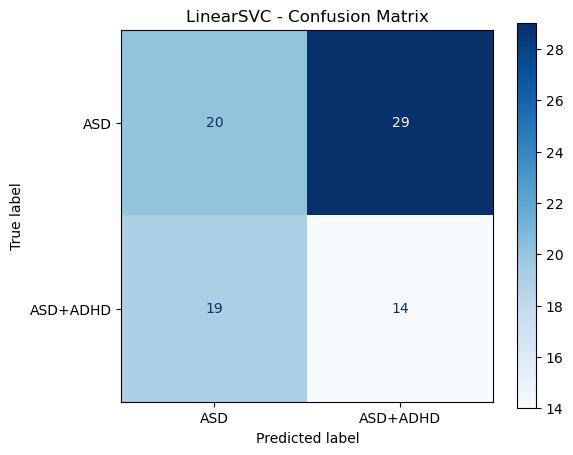

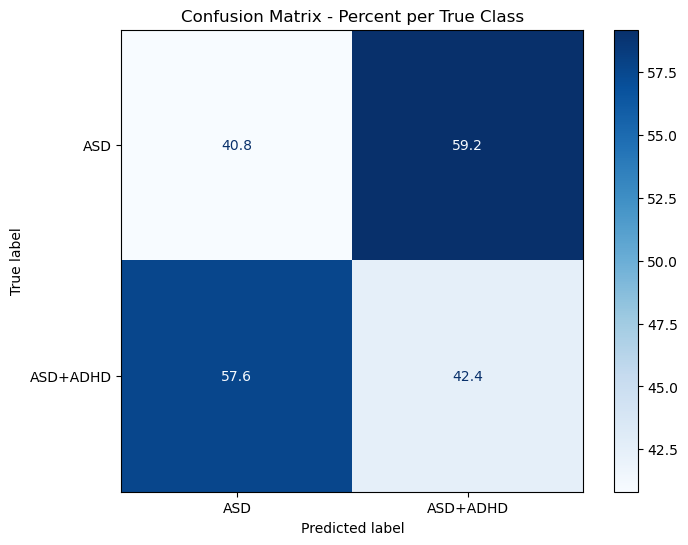


--- Tuning LogisticL1 ---
→ Best LogisticL1 params: {'C': 12.065251350821422}

LogisticL1 classification report:
              precision    recall  f1-score   support

           0      0.630     0.694     0.660        49
           1      0.464     0.394     0.426        33

    accuracy                          0.573        82
   macro avg      0.547     0.544     0.543        82
weighted avg      0.563     0.573     0.566        82



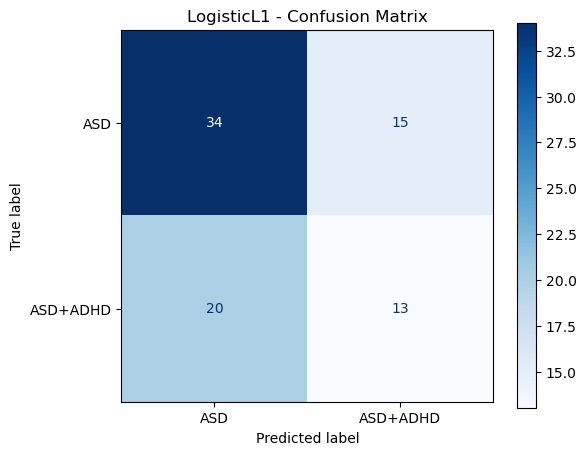

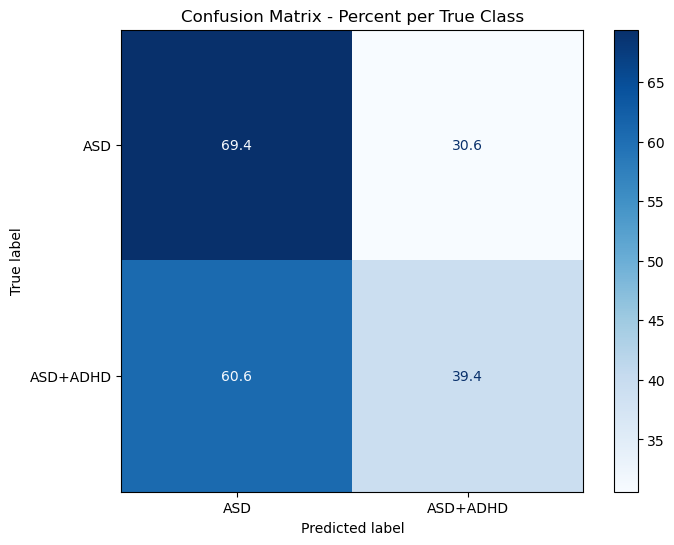


--- Tuning LogisticL2 ---


/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1e-07] before, using random point [0.003741071154932153]
  warnings.warn(


→ Best LogisticL2 params: {'C': 2.0701963028936633e-07}

LogisticL2 classification report:
              precision    recall  f1-score   support

           0      0.513     0.408     0.455        49
           1      0.326     0.424     0.368        33

    accuracy                          0.415        82
   macro avg      0.419     0.416     0.411        82
weighted avg      0.437     0.415     0.420        82



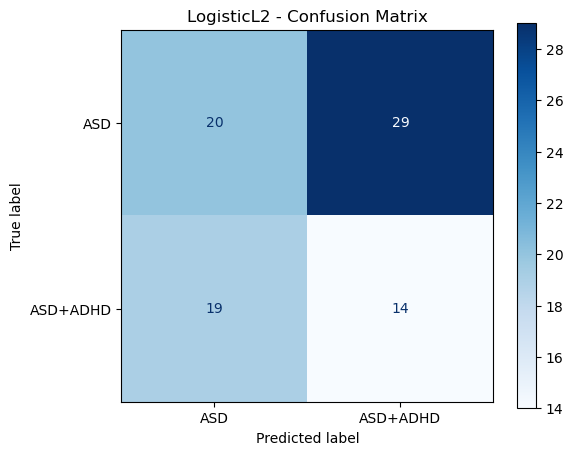

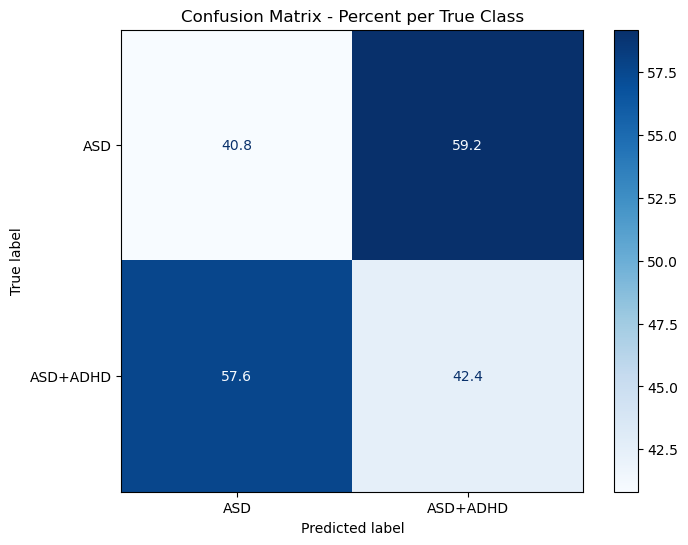

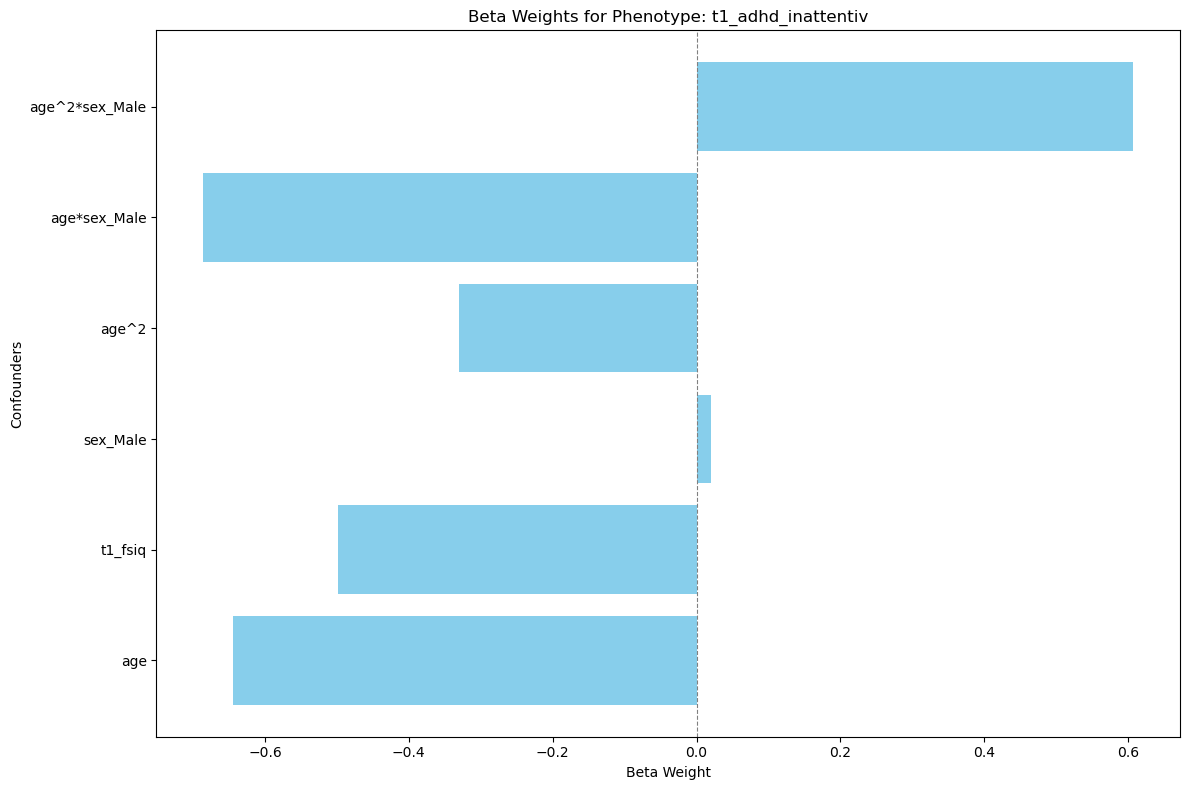

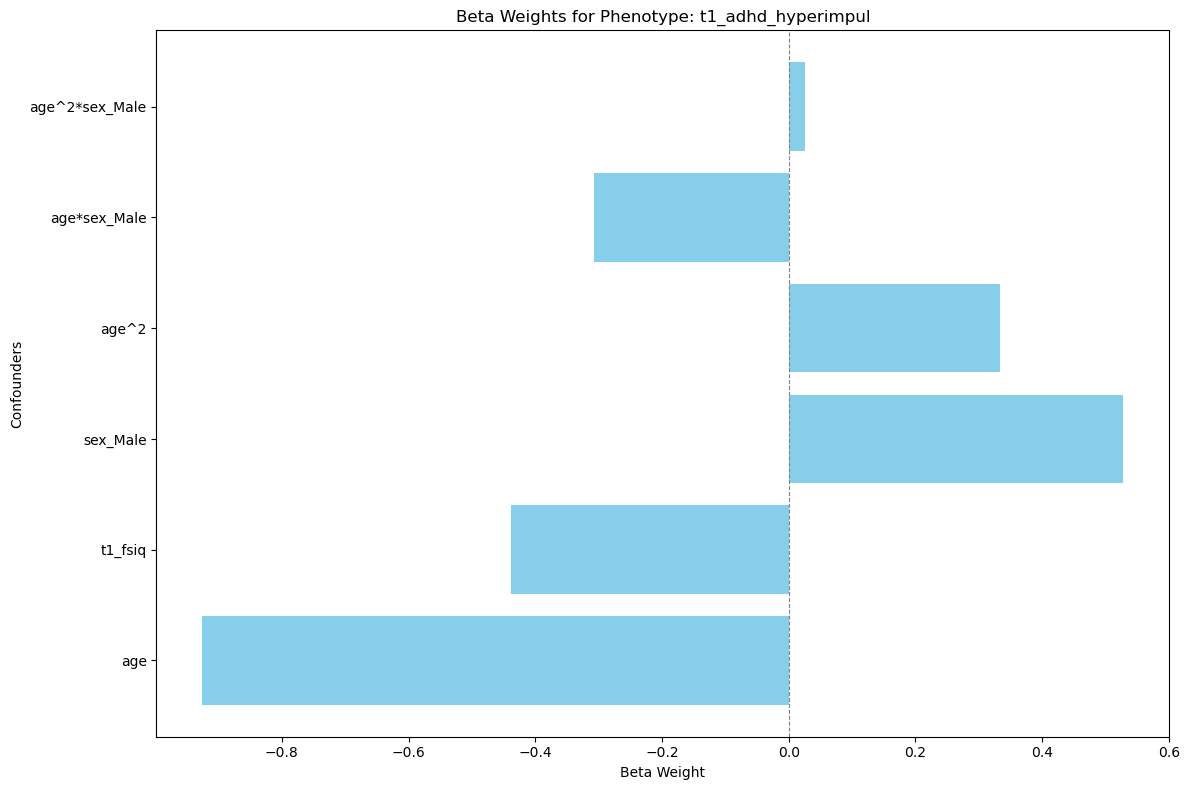

(219, 2) (74, 2)


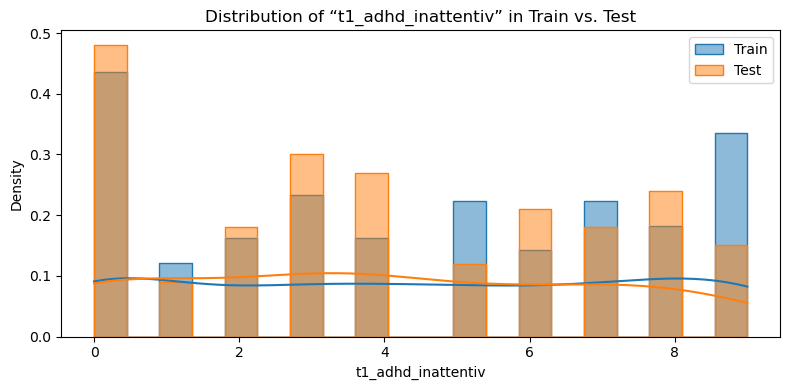

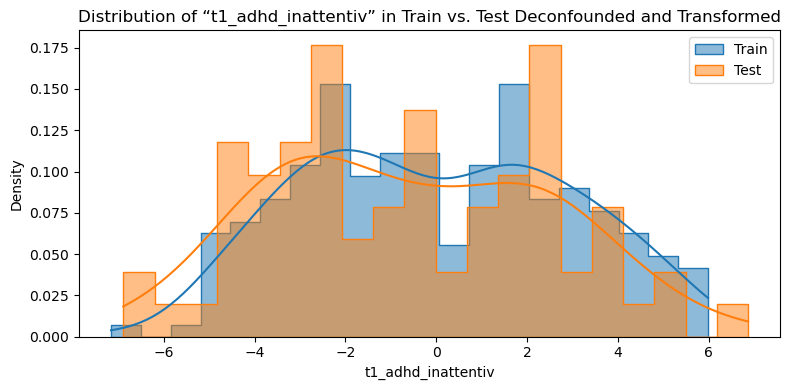

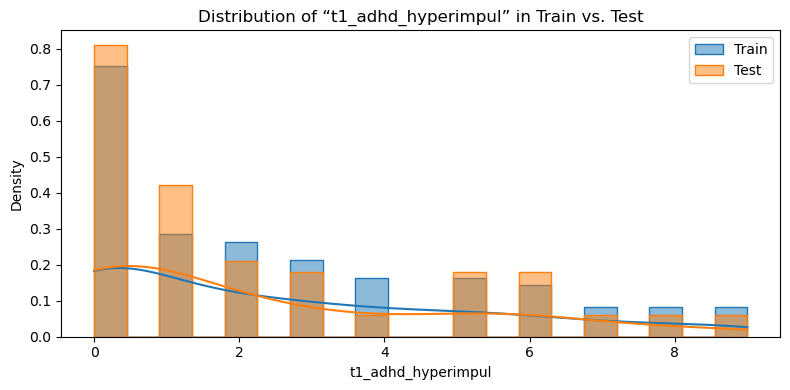

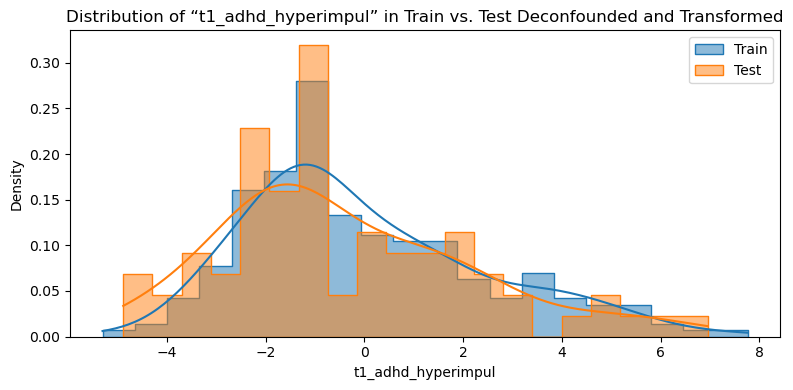

/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 72
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 75
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 76
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 76
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposi

→ Best n_components for PLS: 1
Tangent Model: Avg R² over targets = -0.040


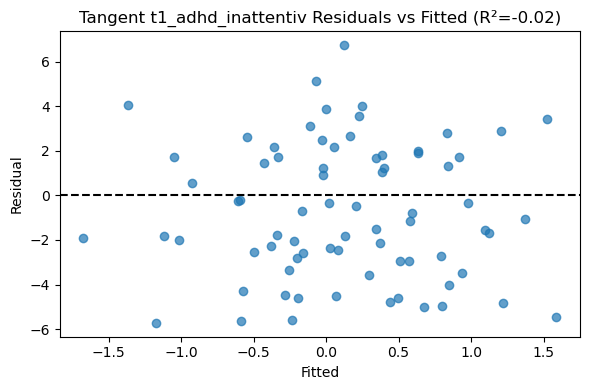

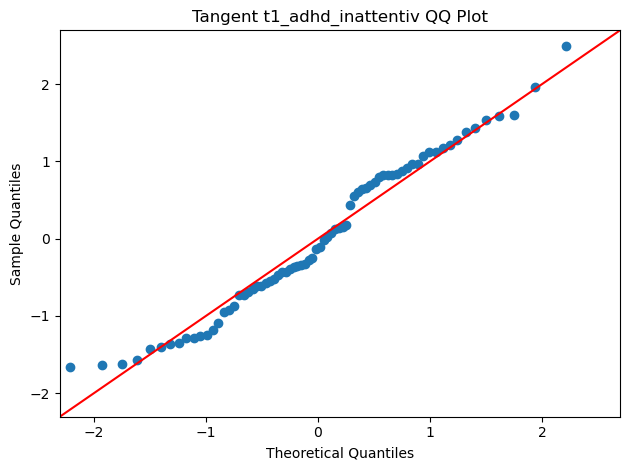

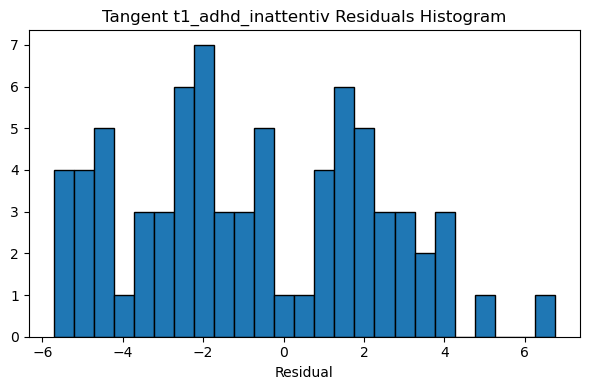

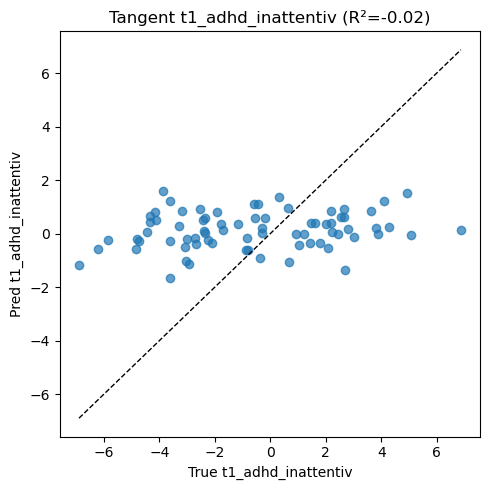

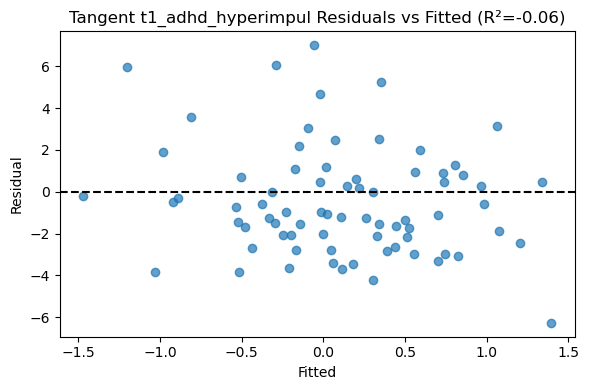

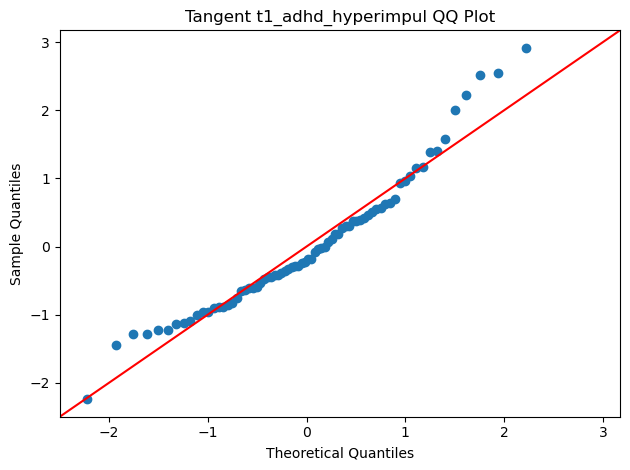

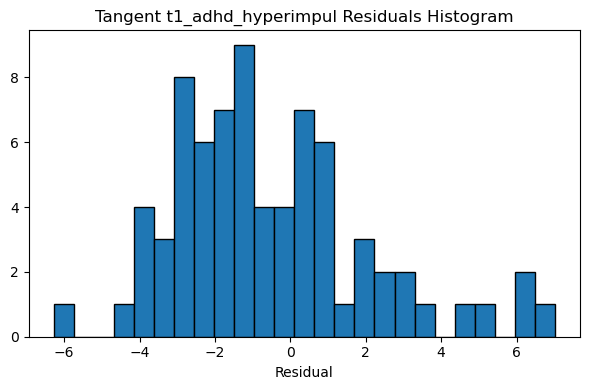

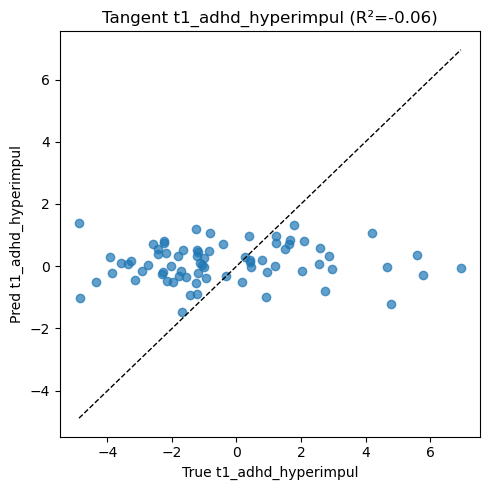

Failed config (None, None, None, [0, 1]): 'TSSF'
KCL None None [0, 1]
89 30
89 30
Using 10-fold StratifiedKFold

--- Tuning LinearSVC ---


/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1e-07] before, using random point [1.862703782770163e-05]
  warnings.warn(
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1e-07] before, using random point [0.003741071154932153]
  warnings.warn(


→ Best LinearSVC params: {'C': 1.0000831386822684e-07}

LinearSVC classification report:
              precision    recall  f1-score   support

           0      0.500     0.500     0.500        14
           1      0.562     0.562     0.562        16

    accuracy                          0.533        30
   macro avg      0.531     0.531     0.531        30
weighted avg      0.533     0.533     0.533        30



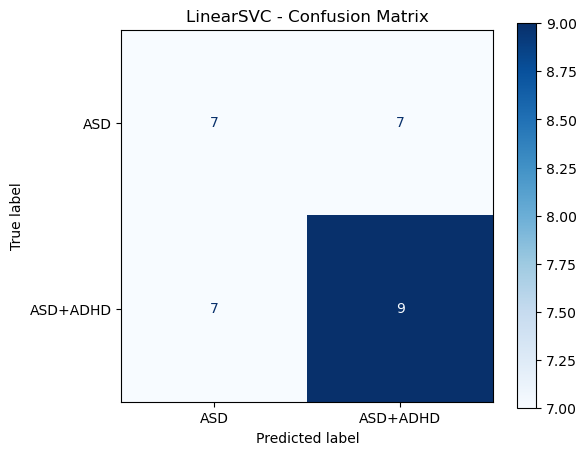

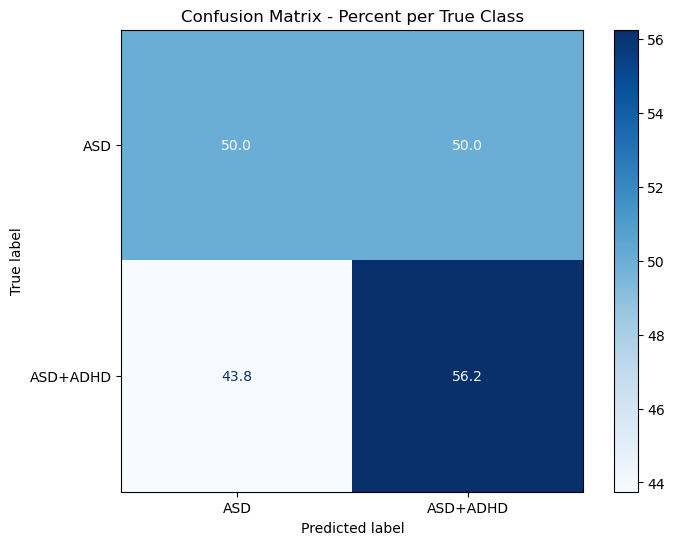


--- Tuning LogisticL1 ---
→ Best LogisticL1 params: {'C': 5.266360183584506}

LogisticL1 classification report:
              precision    recall  f1-score   support

           0      0.417     0.357     0.385        14
           1      0.500     0.562     0.529        16

    accuracy                          0.467        30
   macro avg      0.458     0.460     0.457        30
weighted avg      0.461     0.467     0.462        30



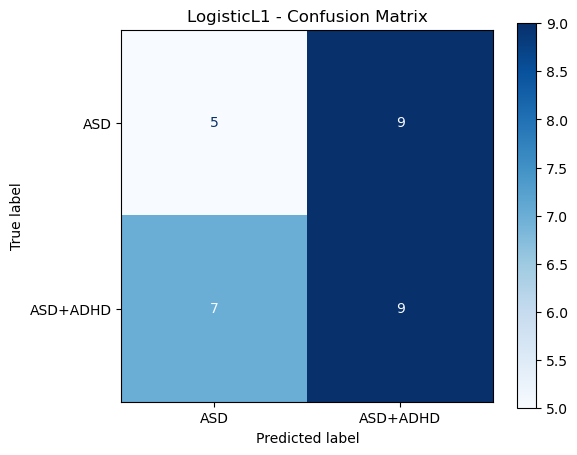

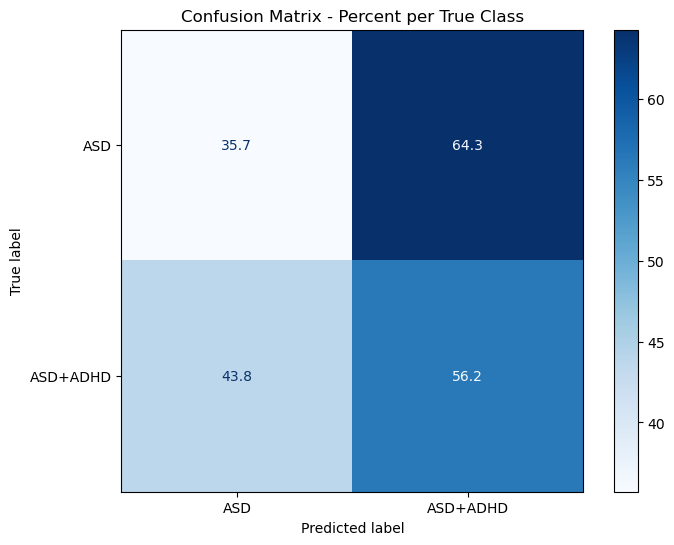


--- Tuning LogisticL2 ---
→ Best LogisticL2 params: {'C': 1.0000831386822684e-07}

LogisticL2 classification report:
              precision    recall  f1-score   support

           0      0.500     0.500     0.500        14
           1      0.562     0.562     0.562        16

    accuracy                          0.533        30
   macro avg      0.531     0.531     0.531        30
weighted avg      0.533     0.533     0.533        30



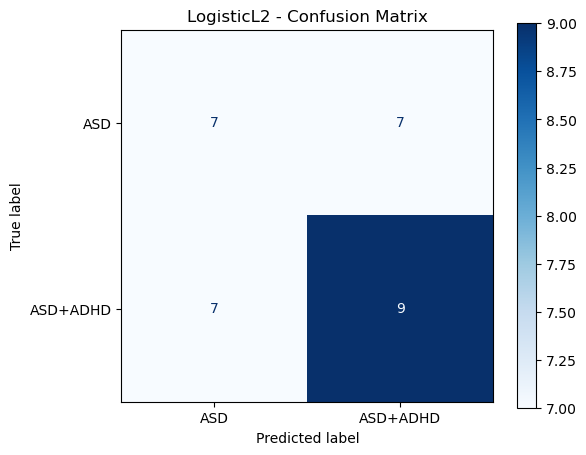

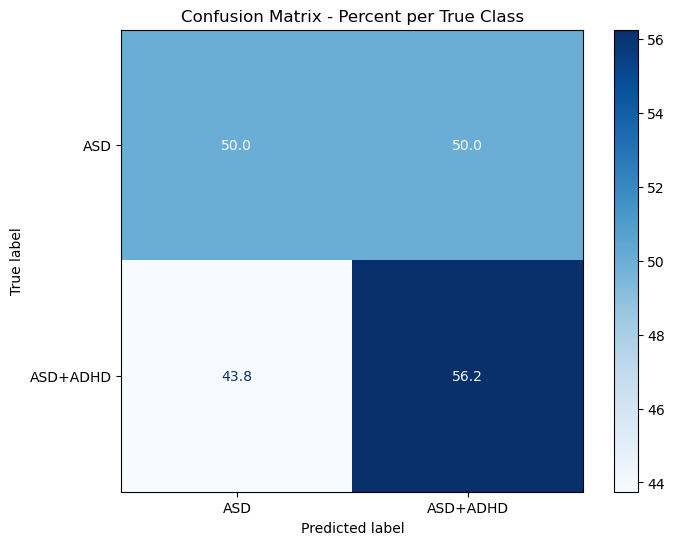

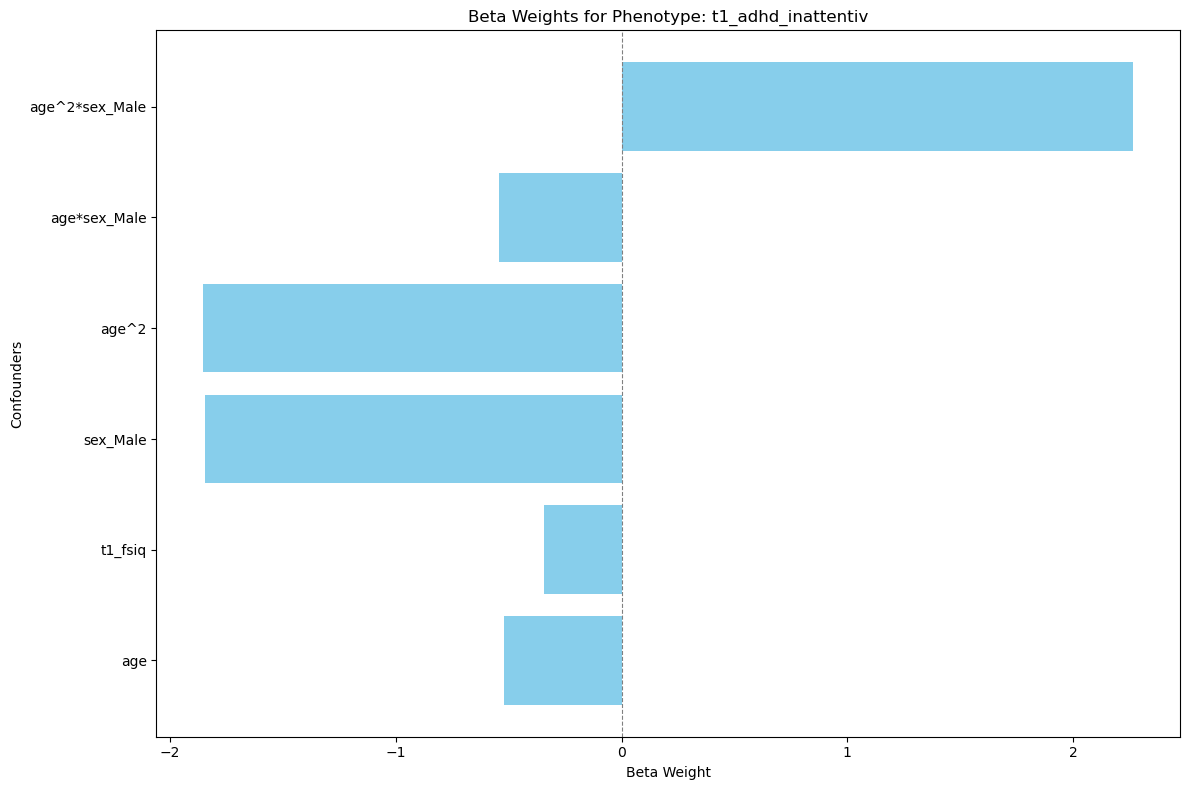

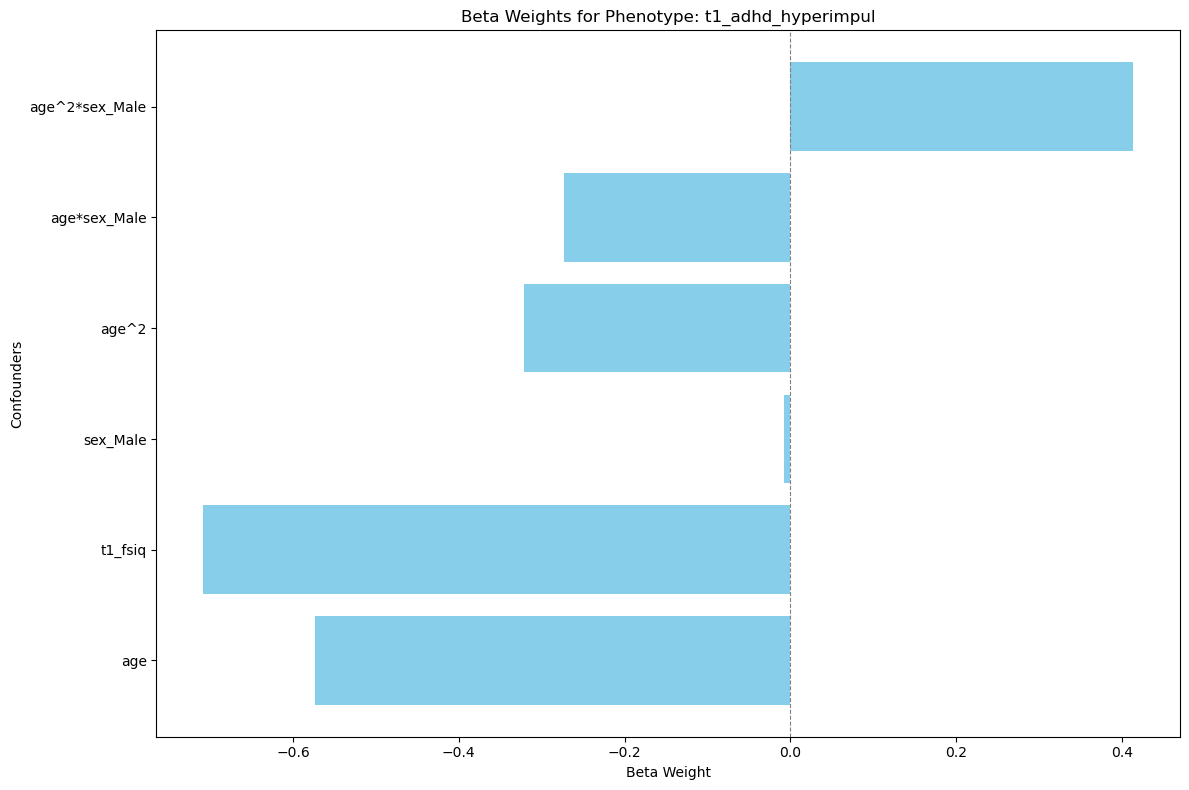

(80, 2) (28, 2)


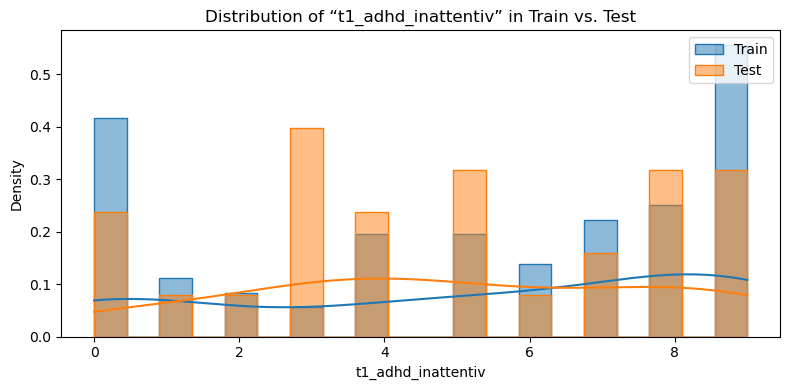

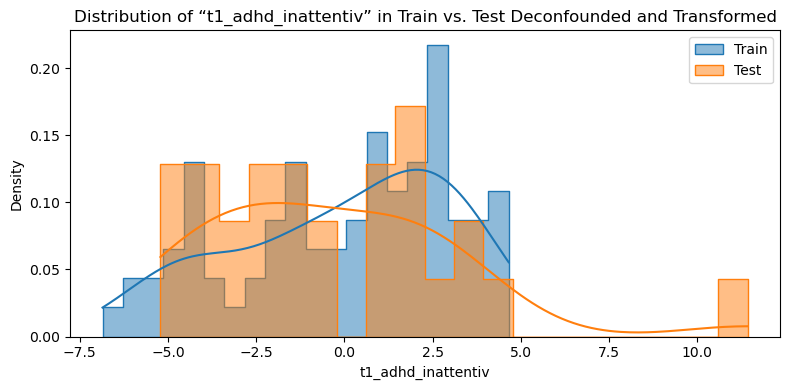

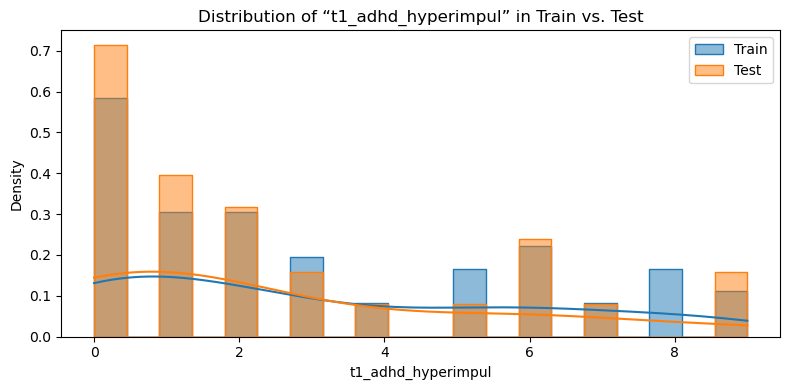

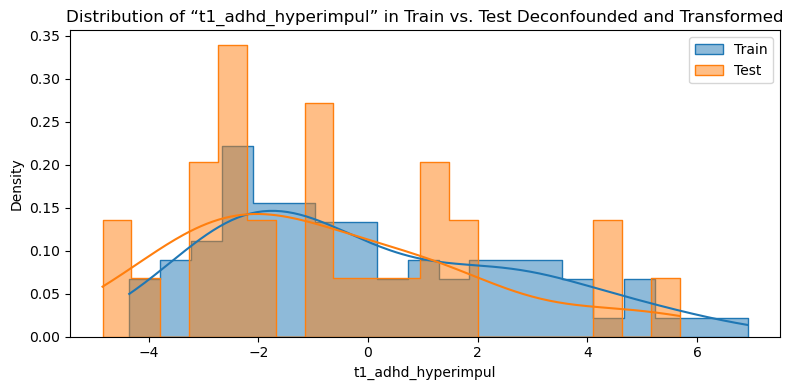

/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 52
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 50
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 51
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:345: UserWarning: y residual is constant at iteration 52
  warnings.warn(f"y residual is constant at iteration {k}")
/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/sklearn/cross_decomposi

→ Best n_components for PLS: 4
Tangent Model: Avg R² over targets = -0.126


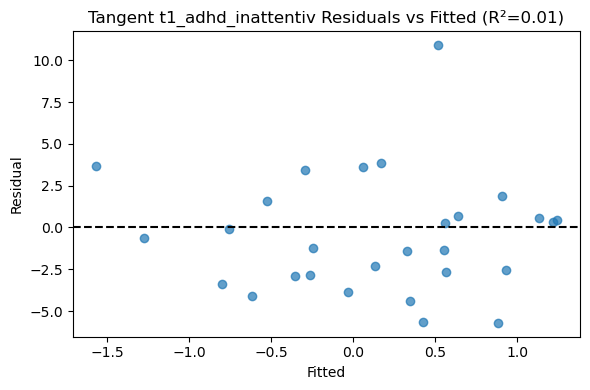

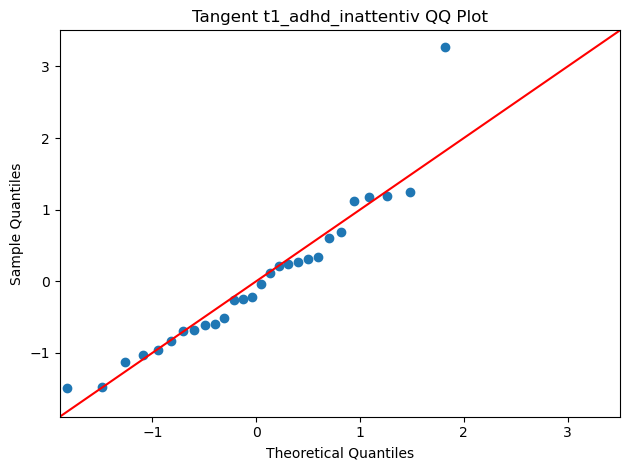

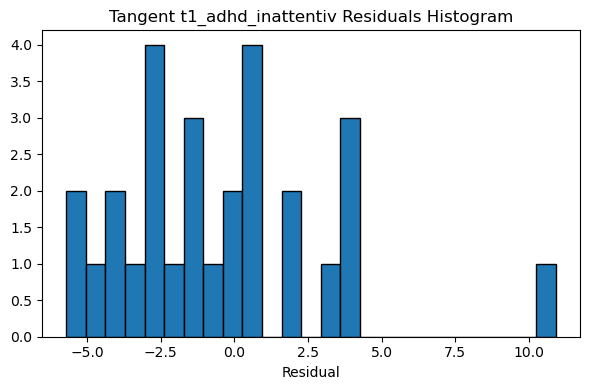

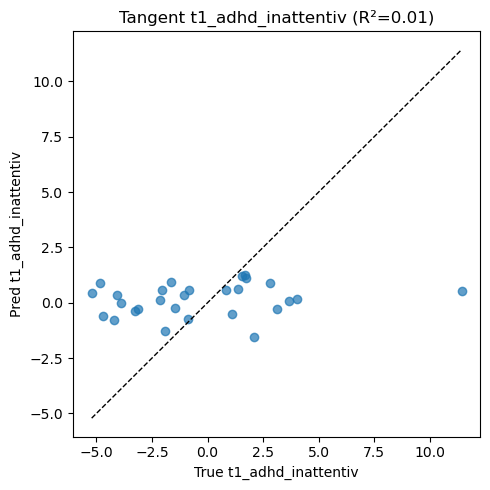

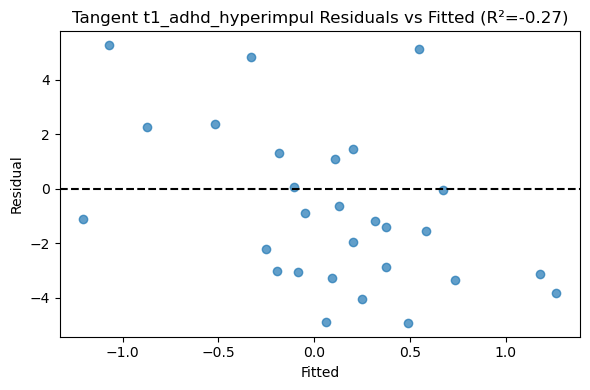

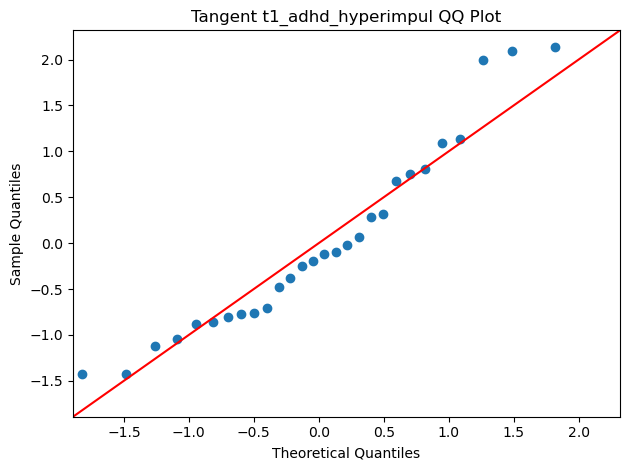

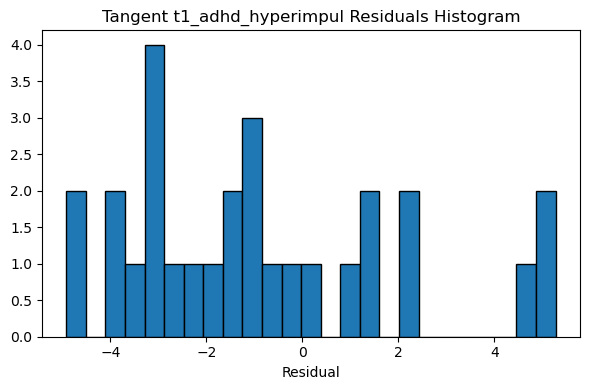

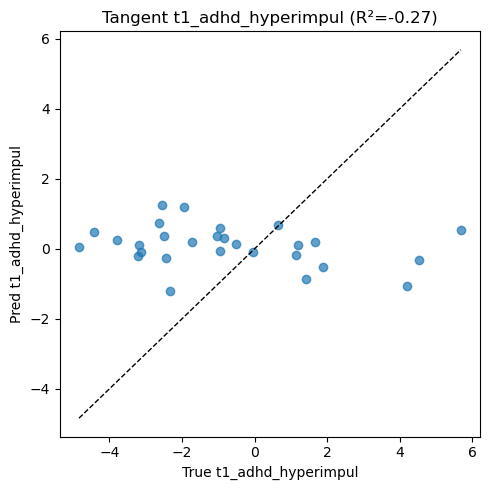

Failed config ('KCL', None, None, [0, 1]): 'TSSF'


In [6]:
import os
import sys
import pandas as pd
from itertools import product

import numpy as np
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns


from skopt import gp_minimize
from skopt.space import Real, Integer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, ElasticNet, Ridge
from sklearn.svm import SVR
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, r2_score, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import DictionaryLearning, PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import  LeaveOneOut
from sklearn.base import BaseEstimator, ClassifierMixin

from pyriemann.utils.tangentspace import  unupper
from pyriemann.estimation import Covariances
from scipy.linalg import eigh


from collections import Counter

import sys
sys.path.append('/project/3022057.01/IFA/utils')

import regression
import tangent
from importlib import reload

# after editing regression.py:
reload(regression)
reload(tangent)

# now pull in your updated functions
from regression import deconfound
from tangent    import tangent_transform

class TSSF_full(BaseEstimator, ClassifierMixin):
    def __init__(self, clf_1, clf_2, n_fil, metric="riemann", cov_reg="oas"):
        self.clf_1 = clf_1     
        self.clf_2 = clf_2
        self.n_fil = n_fil
        self.metric = metric
        self.cov_reg = cov_reg
        self.train_labels = None
        self.subspace = None
        self.train_red_cov = None
        self.red_tan_vec = None
        self.site_train = None
        self.con_conf = None
        self.cat_conf = None

    def site_transport(self, test_red_cov=None, site_test=None):
        p       =  self.train_red_cov.shape[1]
        n_feat  = (p * (p + 1)) // 2
        X_train = np.empty((len(self.train_red_cov), n_feat))
        
        if test_red_cov is not None:
            X_test  = np.empty((len(test_red_cov),  n_feat))
            site_mask = np.full(len(test_red_cov), False, dtype=bool)
            all_sites = np.unique(np.concatenate([self.site_train, site_test]))
        else:
            all_sites = np.unique(self.site_train)

        for s in all_sites:
            tr = self.site_train == s          # boolean mask (train rows for site s)
            
            # if test_red_cov is not None:
            #     te = site_test  == s          # boolean mask (test rows for site s)
            #     Xt, Xv, _ = tangent_transform(self.train_red_cov[tr], test_red_cov[te], metric=self.metric)
            #     X_test[te]  = Xv
            # else:
            #     Xt, _ = tangent_transform(self.train_red_cov[tr], test=None, metric=self.metric)
            if test_red_cov is not None:
                te = site_test == s
                if not np.any(tr):
                    # print(f"[SKIP] No train samples for site {s}")
                    continue
                if not np.any(te):
                    # print(f"[SKIP] No test samples for site {s}")
                    continue
                try:
                    Xt, Xv, _ = tangent_transform(self.train_red_cov[tr], test_red_cov[te], metric=self.metric)
                    X_test[te] = Xv
                    site_mask[te] = True
                except Exception as e:
                    print(f"[WARNING] Skipping site {s} due to tangent_transform error: {e}")
            else:
                Xt, _ = tangent_transform(self.train_red_cov[tr], test=None, metric=self.metric)
                X_train[tr] = Xt          
                
        if test_red_cov is not None:
            return X_test, site_mask  # also return mask of valid rows
        
        return  X_train
            
    def project(self,data):
        data_transformed = [subj @ self.subspace for subj in data]
        # Compute covariances one subject at a time
        cov_est = Covariances(estimator=self.cov_reg)
        red_cov = np.array([ cov_est.transform(subj.T[np.newaxis, :, :])[0] for subj in data_transformed ])
        return red_cov
    
    def fit(self, tan_covs, labels, data, site_train, deconf=True, con_confounder_train=None, cat_confounder_train=None):
        self.train_labels = labels
        self.clf_1.fit(tan_covs, labels)
        coef = np.atleast_2d(self.clf_1.coef_)
        if coef.shape[1] != tan_covs.shape[1]:
            coef = coef.T
        boundary_matrix = unupper(coef)[0,:,:]
        eigs, filters  = eigh(boundary_matrix)
        riem_eigs = eigs**2
        subset = np.argsort(riem_eigs)[-self.n_fil:]
        self.subspace = filters[:,subset]
        self.train_red_cov = self.project(data)
        self.site_train = site_train
        self.red_tan_vec = self.site_transport()
        self.con_conf = con_confounder_train
        self.cat_conf = cat_confounder_train
        
        if deconf:
            X_train = deconfound(
                self.red_tan_vec, self.con_conf, self.cat_conf,
                X_test=None,
                con_confounder_test=None,
                cat_confounder_test=None
            )
        else:
            X_train = self.red_tan_vec

        
        self.clf_2.fit(X_train, self.train_labels)

        return self

    def predict(self, test_data, 
                site_test=None, deconf=True, 
                con_confounder_test=None, cat_confounder_test=None):
        
        test_red_cov = self.project(test_data)
        X_test, site_mask = self.site_transport(test_red_cov, site_test)
        X_test = X_test[site_mask]
        # n_dropped = len(site_mask) - np.sum(site_mask)
        # if n_dropped > 0:
        #     print(f"[INFO] Dropped {n_dropped} test samples due to unseen site(s)")

        if deconf:
            # cat_confounder_train = cat_confounder_train.drop(columns=["t1_site"])
            # cat_confounder_test = cat_confounder_test.drop(columns=["t1_site"])

            # if cat_confounder_train["sex"].nunique() == 1:
            #     cat_confounder_train = cat_confounder_train.drop(columns=["sex"])
            #     cat_confounder_test = cat_confounder_test.drop(columns=["sex"])
            # Drop invalid rows (where no tangent projection was possible)
            con_confounder_test = con_confounder_test.iloc[site_mask]
            cat_confounder_test = cat_confounder_test.iloc[site_mask]
            _, X_test = deconfound(
                self.red_tan_vec, self.con_conf, self.cat_conf,
                X_test=X_test,
                con_confounder_test=con_confounder_test,
                cat_confounder_test=cat_confounder_test
            )
        

        return self.clf_2.predict(X_test), site_mask




def severity(train_targ, test_targ, y_train, y_test, con_train, con_test, cat_train, cat_test, deconf=False, outputfolder=None, eps=1e-1, tf=0):
    feature_cols = train_targ.columns
    # 1) raw→numpy
    X_train = train_targ.values.astype(float)
    X_test  = test_targ .values.astype(float)

    # 2) standard‐scale
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)

    # 3) optional deconfounding on the *scaled* data
    if deconf:
        label_con_train = con_train.drop(columns=["motion"])
        label_con_test  = con_test .drop(columns=["motion"])
        # Pass in X_train/X_test here, not train_targ/test_targ
        X_train, X_test = deconfound(
            X_train, label_con_train, cat_train,
            X_test=X_test,
            con_confounder_test=label_con_test,
            cat_confounder_test=cat_test,
            output_path=os.path.join(outputfolder, "betas_fold0")
        )
        # deconfound may return DataFrames
        X_train = np.asarray(X_train, dtype=float)
        X_test  = np.asarray(X_test,  dtype=float)

    
    # optional scaling or logit
    if tf == 1:
        scaler = MinMaxScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    elif tf == 2:
        scaler = MinMaxScaler().fit(X_train)
        def logit_transform(arr):
            p = np.clip(scaler.transform(arr), eps, 1-eps)
            return np.log(p/(1-p))
        X_train, X_test = logit_transform(X_train), logit_transform(X_test)


    # fit
    pca = PCA(2).fit(X_train)
    lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
    qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)

    # get 1D scores
    scores = {
        "PCA1": (pca.transform(X_train)[:,0], pca.transform(X_test)[:,0]),
        "PCA2": (pca.transform(X_train)[:,1], pca.transform(X_test)[:,1]),
        "LDA":  (lda.decision_function(X_train),   lda.decision_function(X_test)),
        "QDA":  (qda.decision_function(X_train),   qda.decision_function(X_test)),
    }
    # boundaries from train
    bounds = {k: np.median(train_scores) for k,(train_scores,_) in scores.items()}

    # helper for strip
    def plot_strip(ax, arr, boundary, y, title):
        jit = (np.random.rand(len(arr))-.5)*.02
        ax.scatter(arr, jit, c=y, cmap="coolwarm", edgecolor="k", alpha=0.6, s=30)
        ax.axvline(boundary, color="k", linestyle="--", lw=1.5)
        ax.set_yticks([])
        ax.set_ylabel(title)
        preds = (arr>boundary).astype(int)
        return accuracy_score(y, preds)

    # 2×4 grid
    fig, axes = plt.subplots(4,2, figsize=(10,12), sharex=False)
    for row,(name,(train_s, test_s)) in enumerate(scores.items()):
        if "PCA" not in name:
            b = 0
        else:
            b = bounds[name]
        acc_tr = plot_strip(axes[row,0], train_s, b, y_train, name+" (train)")
        acc_te = plot_strip(axes[row,1], test_s,  b, y_test,  name+" (test)")
        axes[row,0].text(.95,.8,f"Acc {acc_tr:.2f}", transform=axes[row,0].transAxes,
                         ha="right",va="center",bbox=dict(boxstyle="round",fc="w",ec=".5"))
        axes[row,1].text(.95,.8,f"Acc {acc_te:.2f}", transform=axes[row,1].transAxes,
                         ha="right",va="center",bbox=dict(boxstyle="round",fc="w",ec=".5"))
        for c in (0,1):
            axes[row,c].spines['top'].set_visible(False)
            axes[row,c].spines['right'].set_visible(False)
            axes[row,c].grid(False)
    axes[-1,0].set_xlabel("Projection value")
    axes[-1,1].set_xlabel("Projection value")
    plt.tight_layout()
    plt.show()

    # 2D decision on TEST only
    if X_test.shape[1] == 2:
        acc_lda = lda.score(X_test,y_test)
        acc_qda = qda.score(X_test,y_test)
        xx,yy = np.meshgrid(
            np.linspace(X_test[:,0].min()-1,X_test[:,0].max()+1,300),
            np.linspace(X_test[:,1].min()-1,X_test[:,1].max()+1,300))
        grid = np.c_[xx.ravel(),yy.ravel()]
        Z_lda = lda.predict(grid).reshape(xx.shape)
        Z_qda = qda.predict(grid).reshape(xx.shape)
        cmap0 = ListedColormap(['#66c2a5','#fc8d62'])

        fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5),sharex=True,sharey=True)
        ax1.contourf(xx,yy,Z_lda,alpha=.2,cmap=cmap0)
        ax1.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolor='k',s=40)
        ax1.set_title(f"LDA (acc={acc_lda:.2f})"); ax1.set_xlabel(feature_cols[0]); ax1.set_ylabel(feature_cols[1])
        ax2.contourf(xx,yy,Z_qda,alpha=.2,cmap=cmap0)
        ax2.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolor='k',s=40)
        ax2.set_title(f"QDA (acc={acc_qda:.2f})"); ax2.set_xlabel(feature_cols[0])
        for ax in (ax1,ax2):
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(False)
        plt.tight_layout()
        plt.show()

    train_scores = lda.decision_function(X_train)
    test_scores  = lda.decision_function(X_test)
    
    train_df = pd.DataFrame(
        {'decision_score': train_scores},
        index=train_targ.index
    )
    test_df = pd.DataFrame(
        {'decision_score': test_scores},
        index=test_targ.index
    )

    return train_df, test_df

def tangent_preprocess(covs_train, y_train, covs_test,  y_test,  data_train, data_test,  con_confounder_train, cat_confounder_train, con_confounder_test,  cat_confounder_test, metric="riemann", site_filter=None, sex_filter=None, age_range=None,  label_filter=None, deconf=False):
    """
    0) label_filter: keep only samples whose labels are in label_filter
    1) sex_filter: keep only samples of a given sex
    2) site_filter: keep only samples from given site(s)
    3) per-site tangent_transform
    4) optional deconfound
    5) returns X_train, X_test and updated y/confounders
    """
    # --- 0) label filtering ---
    # --- 0) label filtering & (optional) combining ---
    if label_filter is not None:
        # label_filter can be None, or e.g.
        #   [0,1,3]
        #   [[0,1],2,3]
        #   [[0,1],3]
        groups = label_filter if isinstance(label_filter, (list,tuple)) else [label_filter]
        # build a mapping: original_label -> new_label (0..n_groups-1)
        mapping = {}
        for new_lbl, group in enumerate(groups):
            for orig in np.atleast_1d(group):
                mapping[orig] = new_lbl

        # keep only samples whose original y is in mapping
        keys = list(mapping.keys())
        keep_tr_label = np.isin(y_train, keys)
        keep_te_label = np.isin(y_test,  keys)

        # filter covariates + confounders
        covs_train, y_train = covs_train[keep_tr_label], y_train[keep_tr_label]
        covs_test,  y_test  = covs_test [keep_te_label], y_test [keep_te_label]
        data_train = data_train[keep_tr_label]
        data_test = data_test[keep_te_label]
        con_confounder_train = con_confounder_train.iloc[keep_tr_label]
        con_confounder_test  = con_confounder_test .iloc[keep_te_label]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_label]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_label]

        # remap y → 0..len(groups)-1
        y_train = np.array([mapping[val] for val in y_train], dtype=int)
        y_test  = np.array([mapping[val] for val in y_test],  dtype=int)


    # --- 1) sex filtering ---
    if sex_filter is not None:                     # e.g. "M" or 1
        sex_tr = cat_confounder_train["sex"].to_numpy()
        sex_te = cat_confounder_test ["sex"].to_numpy()

        keep_tr_sex = sex_tr == sex_filter
        keep_te_sex = sex_te == sex_filter

        covs_train, y_train = covs_train[keep_tr_sex], y_train[keep_tr_sex]
        covs_test,  y_test  = covs_test [keep_te_sex], y_test [keep_te_sex]
        data_train = data_train[keep_tr_sex]
        data_test = data_test[keep_te_sex]

        con_confounder_train = con_confounder_train.iloc[keep_tr_sex]
        con_confounder_test  = con_confounder_test .iloc[keep_te_sex]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_sex]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_sex]


    if age_range is not None:
        min_age, max_age = age_range
        age_tr = con_confounder_train["age"].to_numpy()
        age_te = con_confounder_test ["age"].to_numpy()

        keep_tr_age = (age_tr >= min_age) & (age_tr <= max_age)
        keep_te_age = (age_te >= min_age) & (age_te <= max_age)

        covs_train, y_train = covs_train[keep_tr_age], y_train[keep_tr_age]
        covs_test,  y_test  = covs_test [keep_te_age], y_test [keep_te_age]
        data_train = data_train[keep_tr_age]
        data_test = data_test[keep_te_age]

        con_confounder_train = con_confounder_train.iloc[keep_tr_age]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_age]
        con_confounder_test  = con_confounder_test .iloc[keep_te_age]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_age]

    # ------------------------------------------------------------------
    # raw site vectors (still aligned with covs_*)
    site_train = cat_confounder_train["t1_site"].to_numpy()
    site_test  = cat_confounder_test ["t1_site"].to_numpy()

    # ── 2) optional masking by site ─────────────────────────
    if site_filter is not None:                      # accept str, list, tuple, set, np.ndarray
        site_filter = np.atleast_1d(site_filter)     # ensures it’s iterable
        keep_tr_site = np.isin(site_train, site_filter)
        keep_te_site = np.isin(site_test,  site_filter)

        print(np.sum(keep_tr_site), np.sum(keep_te_site))

        covs_train, y_train = covs_train[keep_tr_site], y_train[keep_tr_site]
        covs_test,  y_test  = covs_test [keep_te_site], y_test [keep_te_site]
        data_train = data_train[keep_tr_site]
        data_test = data_test[keep_te_site]

        con_confounder_train = con_confounder_train.iloc[keep_tr_site]
        con_confounder_test  = con_confounder_test .iloc[keep_te_site]
        cat_confounder_train = cat_confounder_train.iloc[keep_tr_site]
        cat_confounder_test  = cat_confounder_test .iloc[keep_te_site]

        site_train, site_test = site_train[keep_tr_site], site_test[keep_te_site]
    
    # ── 3) per‐site tangent transform ────────────────────────────
    p       = covs_train.shape[1]
    n_feat  = (p * (p + 1)) // 2
    X_train = np.empty((len(covs_train), n_feat))
    X_test  = np.empty((len(covs_test),  n_feat))
    
    all_sites = np.unique(np.concatenate([site_train, site_test]))
    for s in np.unique(all_sites):
        tr = site_train == s          # boolean mask (train rows for site s)
        te = site_test  == s          # boolean mask (test rows for site s)

        Xt, Xv, _ = tangent_transform(covs_train[tr], covs_test[te], metric=metric)

        X_train[tr] = Xt              # drop back into same positions
        X_test[te]  = Xv

    # X_train, X_test, _ = tangent_transform(covs_train, covs_test, metric=metric)

    # ------------------------------------------------------------------
    # 4) optional deconfounding
    # ------------------------------------------------------------------
    if deconf:
        
        cat_confounder_train = cat_confounder_train.drop(columns=["t1_site"])
        cat_confounder_test = cat_confounder_test.drop(columns=["t1_site"])

        if cat_confounder_train["sex"].nunique() == 1:
            cat_confounder_train = cat_confounder_train.drop(columns=["sex"])
            cat_confounder_test = cat_confounder_test.drop(columns=["sex"])

        X_train, X_test = deconfound(
            X_train, con_confounder_train, cat_confounder_train,
            X_test=X_test,
            con_confounder_test=con_confounder_test,
            cat_confounder_test=cat_confounder_test
        )
    
    # ------------------------------------------------------------------
    # 5) (commented) scaling / SMOTE examples
    # ------------------------------------------------------------------
    # from sklearn.preprocessing import StandardScaler
    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)   # fit on TRAIN only
    # X_test  = scaler.transform(X_test)        # apply to TEST
    # print(X_train.shape[0])
    # from imblearn.over_sampling import SMOTE   # or RandomOverSampler
    # # sm = SMOTE(sampling_strategy={0: X_train.shape[0], 1: X_train.shape[0]},k_neighbors=5,random_state=42)
    # sm = SMOTE(sampling_strategy='auto',k_neighbors=5,random_state=42)
    # X_train, y_train = sm.fit_resample(X_train, y_train)

    return (
        X_train, X_test,
        y_train, y_test,
        con_confounder_train, cat_confounder_train,
        con_confounder_test,  cat_confounder_test,
        site_train, site_test,
        data_train, data_test
    )

def classification_pipeline(
    X_train, y_train, X_test, y_test,
    display_labels=None
):
    """
    1) your CV splitter
    2) model specs: (constructor, fixed-kwargs, search-space, param-names)
    3) loop over them: GP-tune, fit, evaluate, plot raw & percent confusion matrices
    Returns: dict of fitted classifiers
    """
    # 1) your CV splitter

    class_counts = Counter(y_train)
    min_count    = min(class_counts.values())
    if min_count < 10:
        cv = LeaveOneOut()
        print(f"Not enough samples per class (min={min_count}), using LOO-CV")
    else:
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        print("Using 10-fold StratifiedKFold")
    
    # 2) model specs: (constructor, fixed‐kwargs, search‐space, param‐names)
    models = {
        'LinearSVC': (
            LinearSVC,
            {'penalty':'l2','loss':'squared_hinge','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
        'LogisticL1': (
            LogisticRegression,
            {'penalty':'l1','solver':'liblinear','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
        'LogisticL2': (
            LogisticRegression,
            {'penalty':'l2','solver':'lbfgs','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
    }

    # 3) loop over them
    final_clfs = {}
    results = {}
    for name, (Cls, base_kwargs, space, param_names) in models.items():
        print(f"\n--- Tuning {name} ---")

        def _obj(params):
            # map list -> dict
            p = dict(zip(param_names, params))
            # build clf
            clf_kwargs = base_kwargs.copy()
            clf_kwargs.update(p)
            clf = Cls(**clf_kwargs)
            # maximize f1_macro
            vals = cross_val_score(clf, X_train, y_train,
                                   cv=cv, scoring='f1_macro', n_jobs=-1)
            vals = vals.mean()
            # vals = np.clip(vals, 1e-6, 1-1e-6)
            # geometric mean via gmean (handles shape etc.)
            # geom = gmean(vals)
            return -vals

        # run GP search
        res = gp_minimize(
            _obj,
            space,
            n_calls=20,
            n_initial_points=5,
            random_state=0,
            acq_optimizer='lbfgs',
            n_jobs=1
        )
        best_params = dict(zip(param_names, res.x))
        print(f"→ Best {name} params:", best_params)

        # fit final
        clf = Cls(**{**base_kwargs, **best_params})
        clf.fit(X_train, y_train)
        final_clfs[name] = clf

        # evaluate on test
        y_pred = clf.predict(X_test)
        print(f"\n{name} classification report:")
        print(classification_report(y_test, y_pred, digits=3, zero_division=0))

        # plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        fig, ax = plt.subplots(figsize=(8, 6))
        disp_norm = ConfusionMatrixDisplay(
            confusion_matrix=cm_normalized,
            display_labels=display_labels
        )
        disp_norm.plot(cmap='Blues', values_format=".1f", ax=ax)
        plt.title("Confusion Matrix - Percent per True Class")
        plt.show()
        
        results[name] = {
            'clf': clf,
            'cm': cm,
            'cm_norm': cm_normalized
        }
    return results


def TSSF_pipeline(
    X_train, y_train, X_test, y_test,
    site_train, site_test,
    data_train, data_test,
    deconf=True, con_train=None, cat_train=None,
    con_test=None, cat_test=None,
    display_labels=None,
    n_calls=20, n_initial_points=5,
    C_bounds=(1e-5,1e2), n_fil_bounds=(1,10)
):
    """
    Runs TSSF_full over all (LinearSVC, LogisticL2) combos as clf1→clf2.
    GP-tunes C1, C2, and n_fil via manual CV with deconfounding.
    Plots raw and normalized confusion matrices on the held-out test set.
    Returns a dict mapping combo names to results.
    """
    # 1) CV splitter
    class_counts = Counter(y_train)
    min_count = min(class_counts.values())
    if min_count < 10:
        cv = LeaveOneOut()
        print(f"Not enough samples per class (min={min_count}), using LOO-CV")
    else:
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        print("Using 10-fold StratifiedKFold")

    # 2) base model definitions
    model_defs = {
        'LinearSVC': (
            LinearSVC,
            {'penalty':'l2','loss':'squared_hinge','class_weight':'balanced','max_iter':10000,'random_state':0}
        ),
        'LogisticL2': (
            LogisticRegression,
            {'penalty':'l2','solver':'lbfgs','class_weight':'balanced','max_iter':10000,'random_state':0}
        )
    }

    results = {}
    # 3) loop over all clf1→clf2 combos
    for (name1,(Cls1,kw1)), (name2,(Cls2,kw2)) in product(model_defs.items(), repeat=2):
        combo_name = f"{name1}_then_{name2}"
        print(f"\n--- Tuning combo: {combo_name} ---")

        # objective: negative macro-F1 with manual CV
        def objective(params):
            C1, C2, n_fil = params
            fold_scores = []
            for tr_idx, val_idx in cv.split(X_train, y_train):
                # split tangent-space features
                X_tr, X_val = X_train[tr_idx], X_train[val_idx]
                # split raw data arrays
                d_tr, d_val = data_train[tr_idx], data_train[val_idx]
                # split site labels
                s_tr, s_val = site_train[tr_idx], site_train[val_idx]
                # split targets
                y_tr, y_val = y_train[tr_idx], y_train[val_idx]

                # split confounders if deconfounding
                if deconf:
                    con_tr_fold = con_train.iloc[tr_idx]
                    cat_tr_fold = cat_train.iloc[tr_idx]
                    con_val_fold = con_train.iloc[val_idx]
                    cat_val_fold = cat_train.iloc[val_idx]
                else:
                    con_tr_fold = cat_tr_fold = con_val_fold = cat_val_fold = None

                # instantiate and fit TSSF
                m1 = Cls1(**{**kw1, 'C': C1})
                m2 = Cls2(**{**kw2, 'C': C2})
                tssf = TSSF_full(clf_1=m1, clf_2=m2, n_fil=int(n_fil))
                tssf.fit(
                    tan_covs            = X_tr,
                    labels              = y_tr,
                    data                = d_tr,
                    site_train          = s_tr,
                    deconf               = deconf,
                    con_confounder_train=con_tr_fold,
                    cat_confounder_train=cat_tr_fold
                )
                # predict on validation fold
                y_pred, site_mask = tssf.predict(
                    test_data             = d_val,
                    site_test             = s_val,
                    deconf                = deconf,
                    con_confounder_test   = con_val_fold,
                    cat_confounder_test   = cat_val_fold
                )
                fold_scores.append(f1_score(y_val[site_mask], y_pred, average='macro'))

            return -np.mean(fold_scores)

        # 4) GP search over C1, C2, n_fil
        space = [
            Real(*C_bounds, name='C1', prior='log-uniform'),
            Real(*C_bounds, name='C2', prior='log-uniform'),
            Integer(*n_fil_bounds, name='n_fil')
        ]
        res = gp_minimize(
            objective, space,
            n_calls=n_calls,
            n_initial_points=n_initial_points,
            random_state=0,
            acq_optimizer='lbfgs'
        )
        C1_opt, C2_opt, n_fil_opt = res.x[0], res.x[1], int(res.x[2])
        print(f"→ Best {combo_name}: C1={C1_opt:.2e}, C2={C2_opt:.2e}, n_fil={n_fil_opt}")

        # 5) final fit on full train, evaluate on held-out test
        m1_final = Cls1(**{**kw1, 'C': C1_opt})
        m2_final = Cls2(**{**kw2, 'C': C2_opt})
        tssf_final = TSSF_full(clf_1=m1_final, clf_2=m2_final, n_fil=n_fil_opt)
        tssf_final.fit(
            tan_covs            = X_train,
            labels              = y_train,
            data                = data_train,
            site_train          = site_train,
            deconf               = deconf,
            con_confounder_train=con_train,
            cat_confounder_train=cat_train
        )
        y_pred_test, site_mask = tssf_final.predict(
            test_data             = data_test,
            site_test             = site_test,
            deconf                = deconf,
            con_confounder_test   = con_test,
            cat_confounder_test   = cat_test
        )

        # compute and plot confusion matrices
        cm = confusion_matrix(y_test[site_mask], y_pred_test)
        cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.title(f"{combo_name} (n_fil={n_fil_opt}) - CM")
        plt.show()

        disp_n = ConfusionMatrixDisplay(cm_norm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(8,6))
        disp_n.plot(ax=ax, cmap='Blues', values_format='.1f')
        plt.title(f"{combo_name} - CM (%)")
        plt.show()

        results[combo_name] = {
            'model': tssf_final,
            'cm': cm,
            'cm_norm': cm_norm,
            'best_C1': C1_opt,
            'best_C2': C2_opt,
            'best_n_fil': n_fil_opt
        }

    return results


def drop_invalid_rows(
    X_train, y_train_df, con_train, cat_train,
    X_test,  y_test_df,  con_test,  cat_test, 
    tr_reg_labels, te_reg_labels,
    invalid_vals=[777, '777', 999, '999']
):
    # 1) Replace your “sentinel” codes with NaN
    y_tr_clean = y_train_df.replace(invalid_vals, np.nan)
    y_te_clean = y_test_df .replace(invalid_vals, np.nan)

    # 2) Build masks: keep only rows with *no* NaNs
    mask_tr = y_tr_clean.notna().all(axis=1)
    mask_te = y_te_clean.notna().all(axis=1)

    # 3) Filter *every* parallel object by that mask
    X_train_f    = X_train[mask_tr]
    y_train_f    = y_train_df.loc[mask_tr]
    con_train_f  = con_train.loc[mask_tr]
    cat_train_f  = cat_train.loc[mask_tr]

    X_test_f     = X_test[mask_te]
    y_test_f     = y_test_df .loc[mask_te]
    con_test_f   = con_test .loc[mask_te]
    cat_test_f   = cat_test .loc[mask_te]
    train_labels_f = tr_reg_labels[mask_tr]
    test_labels_f = te_reg_labels[mask_te]
    return (
        X_train_f, y_train_f, con_train_f, cat_train_f,
        X_test_f,  y_test_f,  con_test_f,  cat_test_f,
        train_labels_f, test_labels_f
    )


def regression_pipeline(
    X_train_pre, X_test_pre,
    y_train_df, y_test_df,
    con_confounder_train, cat_confounder_train,
    con_confounder_test,  cat_confounder_test,
    deconf=False,
    outputfolder=None,
    label="Tangent",
    sev = False,
    tr_reg_labels=None, te_reg_labels=None
):
    """
    1) Residual diagnostics (via nested check_resids)
    2) Optional deconfounding of y
    3) Standardization of y if not deconfounded
    4) Histograms of raw vs. processed y
    5) PLSRegression fit + scatter plots per target
    """
    def check_resids(true, pred, label):
        res = true - pred
        r2  = r2_score(true, pred)

        # Residuals vs Fitted
        plt.figure(figsize=(6,4))
        plt.scatter(pred, res, alpha=0.7)
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel("Fitted")
        plt.ylabel("Residual")
        plt.title(f"{label} Residuals vs Fitted (R²={r2:.2f})")
        plt.tight_layout()
        plt.show()

        # QQ‐plot
        sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
        plt.title(f"{label} QQ Plot")
        plt.tight_layout()
        plt.show()

        # Histogram
        plt.figure(figsize=(6,4))
        plt.hist(res, bins=25, edgecolor='k')
        plt.title(f"{label} Residuals Histogram")
        plt.xlabel("Residual")
        plt.tight_layout()
        plt.show()

    X_train_pre, y_train_df, con_confounder_train, cat_confounder_train, \
    X_test_pre, y_test_df, con_confounder_test, cat_confounder_test, tr_labels_filt, te_labels_filt = drop_invalid_rows(
        X_train_pre, y_train_df, con_confounder_train, cat_confounder_train,
        X_test_pre,  y_test_df,  con_confounder_test,  cat_confounder_test,
        tr_reg_labels, te_reg_labels
    )

    # --- 1) deconfound or scale y ---
    if sev:
        unique_labels = np.unique(tr_labels_filt)
        assert unique_labels.shape[0] == 2, (
            f"Severity mode requires exactly 2 classes, "
            f"but got {unique_labels.shape[0]}: {unique_labels}"
        )        
        y_train_df, y_test_df = severity(y_train_df, y_test_df, tr_labels_filt, te_labels_filt, con_confounder_train, con_confounder_test, cat_confounder_train, cat_confounder_test, deconf=deconf, outputfolder=outputfolder, eps=1e-1, tf=0)
        # simple standardization of each target column
        y_scaler = StandardScaler()
        # note: scaler expects 2D array, so pass .values
        y_train = y_scaler.fit_transform(y_train_df.values)
        y_test  = y_scaler.transform(y_test_df.values)
    else:
        if deconf:
            label_con_train = con_confounder_train.drop(columns=["motion"])
            label_con_test  = con_confounder_test .drop(columns=["motion"])
            y_train, y_test = deconfound(
                y_train_df,
                label_con_train, cat_confounder_train,
                X_test=y_test_df,
                con_confounder_test=label_con_test,
                cat_confounder_test=cat_confounder_test,
                output_path=os.path.join(outputfolder, "betas_fold0")
            )
        else:
            # simple standardization of each target column
            y_scaler = StandardScaler()
            # note: scaler expects 2D array, so pass .values
            y_train = y_scaler.fit_transform(y_train_df.values)
            y_test  = y_scaler.transform(y_test_df.values)

    # force into np.ndarray
    y_train = (np.asarray(y_train))
    y_test  = (np.asarray(y_test))
    print(y_train.shape, y_test.shape)

    # --- 2) Histograms of raw vs. processed y ---
    cols = y_train_df.columns.tolist()
    for i, col in enumerate(cols):
        plt.figure(figsize=(8, 4))
        sns.histplot(y_train_df[col], kde=True, stat="density",
                     element="step", label="Train", color="C0",
                     alpha=0.5, bins=20)
        sns.histplot(y_test_df[col],  kde=True, stat="density",
                     element="step", label="Test",  color="C1",
                     alpha=0.5, bins=20)
        plt.title(f"Distribution of “{col}” in Train vs. Test")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        sns.histplot(y_train[:, i], kde=True, stat="density",
                     element="step", label="Train", color="C0",
                     alpha=0.5, bins=20)
        sns.histplot(y_test[:, i],  kde=True, stat="density",
                     element="step", label="Test",  color="C1",
                     alpha=0.5, bins=20)
        plt.title(f"Distribution of “{col}” in Train vs. Test Deconfounded and Transformed")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # decide by number of predictors
    if y_train.shape[1] == 1:
        # single‐feature: GP-tune three regressors
        regressors = {
            'Ridge': (
                Ridge, {'random_state':0},
                [Real(1e-1, 1e4, prior='log-uniform', name='alpha')],
                ['alpha']
            ),
            # 'SVR': (
            #     SVR, {'kernel':'linear'},
            #     [
            #       Real(1e-6, 1e3, prior='log-uniform', name='C'),
            #       Real(1e-4, 1e-1, prior='log-uniform', name='epsilon')
            #     ],
            #     ['C','epsilon']
            # ),
            # 'ElasticNet': (
            #     ElasticNet, {'random_state':0,'max_iter':10000},
            #     [
            #       Real(1e-3, 1e3,   prior='log-uniform', name='alpha'),
            #       Real(1e-3, 1.0,   prior='uniform',     name='l1_ratio')
            #     ],
            #     ['alpha','l1_ratio']
            # )
        }

        best_r2 = -np.inf
        best_model = None
        for name,(Cls,fixed,space,pnames) in regressors.items():
            print(f"--- tuning {name} on single feature ---")
            def obj(params):
                p = dict(zip(pnames, params))
                m = Cls(**{**fixed, **p})
                # minimize –R² via 5-fold CV
                # return -cross_val_score(
                #     m, X_train_pre, y_train.ravel(),
                #     cv=10, scoring='r2', n_jobs=-1
                # ).mean()
                return cross_val_score(
                    m, X_train_pre, y_train.ravel(),
                    cv=LeaveOneOut(), scoring='neg_mean_squared_error', n_jobs=-1
                ).mean()
             

            res = gp_minimize(obj, space,
                              n_calls=20, n_initial_points=5,
                              random_state=0, n_jobs=1)
            best_params = dict(zip(pnames, res.x))
            print(f"→ {name} best:", best_params)

            m = Cls(**{**fixed, **best_params})
            m.fit(X_train_pre, y_train.ravel())
            r2 = r2_score(y_train, m.predict(X_train_pre))
            print(f"{name} train R² = {r2:.3f}")
            print(f"{name} test R² = {r2_score(y_test, m.predict(X_test_pre)):.3f}")

            if r2 > best_r2:
                best_r2, best_model = r2, m

        print(f"Selected model: train R² = {best_r2:.3f}")
        model_pre = best_model
        y_pred_pre = model_pre.predict(X_test_pre)

    else:
        # # multi‐feature: PLS(1)
        # model_pre = PLSRegression(n_components=10)
        # model_pre.fit(X_train_pre, y_train)
        # y_pred_pre = model_pre.predict(X_test_pre)

        # Optimize alpha for sparse dictionary learning via cross-validated R²

        # class DLRegressor(BaseEstimator, RegressorMixin):
        #     def __init__(self, alpha):
        #         self.alpha = alpha
        #     def fit(self, X, y):
        #         C = X.T @ y
        #         dl = DictionaryLearning(
        #             n_components=1,
        #             alpha=self.alpha,
        #             fit_algorithm="lars",
        #             transform_algorithm="lasso_lars"
        #         )
        #         U = dl.fit_transform(C)
        #         u = U[:, 0]
        #         u /= np.linalg.norm(u)
        #         q = np.linalg.pinv((X @ u)[:, None]) @ y
        #         self.b_ = u[:, None] @ q
        #         return self
        #     def predict(self, X):
        #         return (X @ self.b_)

        # def obj_dl(alpha):
        #     alpha = float(alpha[0])
        #     reg = DLRegressor(alpha=alpha)
        #     return -cross_val_score(
        #         reg,
        #         X_train_pre,
        #         y_train,
        #         cv=10,
        #         scoring='r2',
        #         n_jobs=-1
        #     ).mean()


        # res = gp_minimize(
        #     obj_dl,
        #     [Real(1e-6, 1e1, prior="log-uniform", name="alpha")],
        #     n_calls=20,
        #     n_initial_points=5,
        #     random_state=0,
        #     n_jobs=1
        # )

        # best_alpha = res.x[0]
        # print(f"→ Best alpha for DictionaryLearning: {best_alpha:.3e}")

        # # 2) cross-covariance and dict-learning
        # C = X_train_pre.T @ y_train         # (p × t)
        # dl = DictionaryLearning(n_components=1, alpha=best_alpha, fit_algorithm="lars", transform_algorithm="lasso_lars")
        # U = dl.fit_transform(C)             # (p × 1) — sparse left vector
        # V = dl.components_                  # (1 × t) — right vector

        # u = U[:, 0]
        # v = V[0, :]

        # # Normalize u to match PLS scale convention
        # u /= np.linalg.norm(u)

        # # Project to latent score
        # t_train = X_train_pre @ u           # (n_train,)

        # # Estimate rescaling q (OLS on t_train)
        # q = np.linalg.pinv(t_train[:, None]) @ y_train   # (1 × t)

        # # Final model
        # b = u[:, None] @ q                  # (p × t)
        # y_pred_pre = X_test_pre @ b
        # 1) define an objective that returns negative CV R² for a given n_components
        def obj_ncomp(params):
            n_comp = int(params[0])
            model = PLSRegression(n_components=n_comp)
            # use 10‐fold CV (just like you did for alpha)
            return -cross_val_score(
                model,
                X_train_pre,
                y_train,
                cv=10,
                scoring='r2',
                n_jobs=-1
            ).mean()

        # 2) run gp_minimize over n_components ∈ [1, max_components]
        #    here I set max_components to, e.g., min(n_samples, n_features), or just 20
        max_comp = min(X_train_pre.shape)  # or replace with a fixed upper bound like 20
        res_pls = gp_minimize(
            obj_ncomp,
            [Integer(1, max_comp, name="n_comp")],
            n_calls=20,
            n_initial_points=5,
            random_state=0,
        )

        best_n = res_pls.x[0]
        print(f"→ Best n_components for PLS: {best_n}")

        # 3) re‐fit using the tuned number of components
        model_pre = PLSRegression(n_components=best_n)
        model_pre.fit(X_train_pre, y_train)
        y_pred_pre = model_pre.predict(X_test_pre)


    # average R² across targets
    r2_avg_pre = r2_score(y_test, y_pred_pre, multioutput="uniform_average")
    print(f"{label} Model: Avg R² over targets = {r2_avg_pre:.3f}")

    # If y_pred_pre is 1D, convert it to 2D with shape (n_samples, 1)
    if y_pred_pre.ndim == 1:
        y_pred_pre = y_pred_pre[:, np.newaxis]
    if y_test.ndim == 1:
        y_test = y_test[:, np.newaxis]

    # 4) residual diagnostics and true-vs-pred scatter per target
    for i, col in enumerate(y_train_df.columns):
        # residual diagnostics
        check_resids(y_test[:, i], y_pred_pre[:, i], label=f"{label} {col}")

        # true vs. pred
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:, i], y_pred_pre[:, i], alpha=0.7)
        plt.plot([y_test[:, i].min(), y_test[:, i].max()],
                 [y_test[:, i].min(), y_test[:, i].max()],
                 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"{label} {col} (R²={r2_score(y_test[:, i], y_pred_pre[:, i]):.2f})")
        plt.tight_layout()
        plt.show()

    # return model_pre



def tangent_run(
    covs_train, covs_test,
    data_train, data_test,            # ← raw arrays: (n_samples, n_times, n_parcels)

    con_train, cat_train, con_test, cat_test,

    # classification args
    y_train_clf, y_test_clf, display_labels=None,
    do_classification=True,
    do_TSSF=True,
    # regression args
    y_train_reg_df=None, y_test_reg_df=None,
    reg_deconf=False, reg_outputfolder=None, reg_label="Tangent",
    do_regression=False, sev=False,

    # shared
    metric="riemann", site_filter=None, sex_filter=None, label_filter=None, age_range=None, deconf=False
):
    """
    1) Preprocess features & confounders via tangent_preprocess
    2) If do_classification, call classification_pipeline
    3) If do_regression, call regression_pipeline
    Returns dict with 'classifiers' and/or 'regression_model'
    """
    results = {}
    X_tr, X_te, y_tr, y_te, c_tr, cat_tr, c_te, cat_te, site_train, site_test, data_train, data_test = tangent_preprocess(
                covs_train, y_train_clf,
                covs_test,  y_test_clf,
                data_train, data_test,
                con_train, cat_train,
                con_test,  cat_test,
                metric=metric,
                site_filter=site_filter,
                sex_filter=sex_filter,
                label_filter = label_filter,age_range=age_range, 
                deconf=deconf
            )
    # — 1) Preprocess for classification —
    if do_classification:
        results['classifiers'] = classification_pipeline(
            X_tr, y_tr, X_te, y_te, display_labels=display_labels
        )
    if do_TSSF:
        results['TSSF'] = TSSF_pipeline(
            X_train          = X_tr,
            y_train          = y_tr,
            X_test           = X_te,
            y_test           = y_te,
            site_train       = site_train,
            site_test        = site_test,
            data_train       = data_train,
            data_test        = data_test,
            deconf           = deconf,
            con_train        = c_tr,
            cat_train        = cat_tr,
            con_test         = c_te,
            cat_test         = cat_te,
            display_labels   = display_labels,
        )
    # — 2) Preprocess & run regression —
    if do_regression:
        y_train_reg_df = y_train_reg_df.loc[c_tr.index]
        y_test_reg_df  = y_test_reg_df .loc[c_te.index]
        results['regression_model'] = regression_pipeline(
            X_tr, X_te,
            y_train_reg_df, y_test_reg_df,
            c_tr, cat_tr,
            c_te, cat_te,
            deconf=reg_deconf,
            outputfolder=reg_outputfolder,
            label=reg_label,
            sev=sev, tr_reg_labels=y_tr, te_reg_labels=y_te
        )

    return results


OUTFILE = os.path.join(fold_output_dir,"loop_results.txt")
# before your loops:
if os.path.exists(OUTFILE):
    os.remove(OUTFILE)

# 2) Binary ASD+ADHD vs TD
# agebands = [None, (6,12),(0,12),(12,18),(18,40),(0,40)]
# sexrange = [None, "Male", "Female"]
# sites =  [None] + list(np.unique(sub_df["t1_site"]))
label_filters = [[0,1]]
agebands = [None]
sexrange = [None]
sites = [None, "KCL"]
# label_filters = [[0,1],[[0,1],3]]
for site in sites:
    for band in agebands:
        for sex in sexrange:
            for label_config in label_filters:
                try:
                    print(site, band, sex, label_config)
                    # # 1) preprocess & filter
                    _, _, y_tr_count, y_te_count, _, _, _, _, _, _,_,_ = tangent_preprocess(
                        partial_train_covs, train_labels,
                        partial_test_covs,  test_labels,
                        np.array(partial_train_data, dtype=object),  np.array(partial_test_data, dtype=object), 
                        train_con_confounders, train_cat_confounders,
                        test_con_confounders,   test_cat_confounders,
                        metric=metric,
                        site_filter=site,
                        sex_filter=sex,
                        label_filter=label_config,
                        age_range=band,
                        deconf=True
                    )

                    # print(y_tr_count)
                    # 2) derive the “true” set of categories from the train labels
                    categories = np.unique(y_tr_count)

                    # 3) count in train & test (missing → 0)
                    tr_counts = Counter(y_tr_count)
                    te_counts = Counter(y_te_count)
                    # make sure to only look at our train‐defined categories
                    bad_train = [cat for cat in categories if tr_counts[cat] < 2]
                    bad_test  = [cat for cat in categories if te_counts.get(cat, 0) < 1]
                    if bad_train or bad_test:
                        print(
                            f"Skipping config {site, band, sex, label_config} → "
                            f"train-too-few={bad_train}, test-too-few={bad_test}"
                        )
                        continue


                    res = tangent_run(
                        partial_train_covs, partial_test_covs,
                        np.array(partial_train_data, dtype=object),  np.array(partial_test_data, dtype=object), 
                        train_con_confounders, train_cat_confounders,
                        test_con_confounders,   test_cat_confounders,

                        # classification args
                        y_train_clf=train_labels,
                        y_test_clf =test_labels,
                        display_labels=['ASD','ASD+ADHD'],
                        do_classification=True,
                        do_TSSF=False,

                        # regression
                        y_train_reg_df=sub_df[["t1_adhd_inattentiv","t1_adhd_hyperimpul"]].iloc[train_idx], y_test_reg_df=sub_df[["t1_adhd_inattentiv","t1_adhd_hyperimpul"]].iloc[test_idx],
                        reg_deconf=True, reg_outputfolder=outputfolder, reg_label="Tangent",
                        do_regression=True, sev=False,

                        # shared
                        metric=metric,
                        site_filter=site,
                        sex_filter=sex,
                        label_filter=label_config,
                        age_range=band,     # e.g. only 6– to 18-year-olds
                        deconf=True
                    )

                    # --- APPEND confusion matrices to OUTFILE ---
                    class_results = res['classifiers']
                    with open(OUTFILE, "a") as log:
                        log.write(f"=== CONFIG: site={site}, age={band}, sex={sex}, labels={label_config} ===\n")

                        cats = sorted(tr_counts)
                        log.write("-- Train counts per class --\n")
                        log.write("  " + "\t".join(str(tr_counts[c]) for c in cats) + "\n")
                        log.write("-- Test counts per class --\n")
                        log.write("  " + "\t".join(str(te_counts.get(c,0)) for c in cats) + "\n\n")


                        for name, info in class_results.items():
                            cm      = info['cm']
                            cm_norm = info['cm_norm']

                            log.write(f"-- {name} RAW CM --\n")
                            for row in cm:
                                log.write("  " + "\t".join(str(int(x)) for x in row) + "\n")

                            log.write(f"-- {name} NORMALIZED CM (%) --\n")
                            for row in cm_norm:
                                log.write("  " + "\t".join(f"{x:.1f}%" for x in row) + "\n")

                            # compute balanced accuracy = mean of diagonal of cm_norm (percent → fraction)
                            bal_acc = np.diag(cm_norm).mean() / 100
                            log.write(f"Balanced accuracy: {bal_acc:.3f}\n\n")

                        log.write("\n")
                        
                    # --- APPEND TSSF PIPELINE RESULTS to OUTFILE ---
                    tssf_results = res['TSSF']
                    with open(OUTFILE, "a") as log:
                        log.write("-- TSSF PIPELINE RESULTS --\n")
                        for combo_name, info in tssf_results.items():
                            C1     = info['best_C1']
                            C2     = info['best_C2']
                            n_fil  = info['best_n_fil']
                            cm     = info['cm']
                            cm_norm= info['cm_norm']
                            bal_acc= np.diag(cm_norm).mean() / 100

                            log.write(f"-- {combo_name} (C1={C1:.2e}, C2={C2:.2e}, n_fil={n_fil}) --\n")
                            # raw confusion matrix
                            log.write("RAW CM:\n")
                            for row in cm:
                                log.write("  " + "\t".join(str(int(x)) for x in row) + "\n")

                            # normalized (percent) confusion matrix
                            log.write("NORMALIZED CM (%):\n")
                            for row in cm_norm:
                                log.write("  " + "\t".join(f"{x:.1f}%" for x in row) + "\n")

                            log.write(f"Balanced accuracy: {bal_acc:.3f}\n\n")

                        # blank line to separate configs
                        log.write("\n")
                except Exception as e:
                    # Log *which* config failed and why, then carry on
                    print(f"Failed config {site, band, sex, label_config}: {e}")
                    with open(OUTFILE, "a") as log:
                        log.write(f"!! ERROR for config {site,band,sex,label_config}: {e}\n\n")
                    continue

# display_labels=['ASD','ASD+ADHD','TD+ADHD','TD']
# "t1_adhd_inattentiv","t1_adhd_hyperimpul","t1_css_total_all","t1_sa_css_all","t1_rrb_css_all","t1_vabsabcabc_standard"
# "t1_adhd_inattentiv","t1_adhd_hyperimpul","t1_css_total_all","t1_sa_css_all","t1_rrb_css_all","t1_vabsabcabc_standard"

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import pandas as pd
import ast

from regression import deconfound
from tangent import tangent_transform


# ----------------------------------------------------------------------
def tangent_classification_multiclass(
        covs_all, y_all,
        metric="riemann",
        train_site=None,                     # e.g. "KCL"
        deconf=False,
        con_confounders=None,                # DataFrame
        cat_confounders=None,                # DataFrame incl. 't1_site'
        display_labels=None,
        sex_filter=None):          # ← new




    # --- optional sex filter ------------------------------------------
    if sex_filter is not None:     # e.g. sex_filter = "M"
        sex_vec   = cat_confounders["sex"].to_numpy()
        keep_sex  = sex_vec == sex_filter
        covs_all  = covs_all[keep_sex]
        y_all     = y_all [keep_sex]
        con_confounders = con_confounders.iloc[keep_sex].reset_index(drop=True)
        cat_confounders = cat_confounders.iloc[keep_sex].reset_index(drop=True)
    # ------------------------------------------------------------------

    #  1. split: train = chosen site, test = rest
    site_vec   = cat_confounders["t1_site"].to_numpy()
    train_mask = site_vec == train_site
    test_mask  = ~train_mask
    covs_train, y_train = covs_all[train_mask], y_all[train_mask]
    covs_test,  y_test  = covs_all[test_mask],  y_all[test_mask]

    con_tr = con_confounders.iloc[train_mask].reset_index(drop=True)
    con_te = con_confounders.iloc[test_mask].reset_index(drop=True)

    #  2. drop t1_site from categorical confounds BEFORE de-convolving
    cat_tr = cat_confounders.iloc[train_mask].drop(columns=["t1_site"]).reset_index(drop=True)
    cat_te = cat_confounders.iloc[test_mask].drop(columns=["t1_site"]).reset_index(drop=True)

    site_train = site_vec[train_mask]
    site_test  = site_vec[test_mask]

    # 2)   TRAIN projection (single site → one mean)
    X_train, _ = tangent_transform(covs_train, metric=metric)

    # 3)   TEST projection (per-site loop)
    p = covs_train.shape[1]
    n_feat = p * (p + 1) // 2
    X_test = np.empty((len(covs_test), n_feat))

    for s in np.unique(site_test):
        te = site_test == s
        Xt, _ = tangent_transform(covs_test[te], metric=metric)
        X_test[te] = Xt          # drop into original row slots

    # 4. optional de-confounding (site column is already gone)
    if deconf:
        X_train, X_test = deconfound(
            X_train, con_tr, cat_tr,
            X_test=X_test,
            con_confounder_test=con_te,
            cat_confounder_test=cat_te)

    # 5. classifier
    clf = LinearSVC(penalty="l2", loss="squared_hinge", C=0.1, class_weight="balanced", max_iter=10000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    labels = display_labels or [f"Class {i}" for i in np.unique(np.concatenate([y_train, y_test]))]
    ConfusionMatrixDisplay(cm, display_labels=labels)\
        .plot(cmap="Blues", values_format="d")
    plt.title(f"Train site: {train_site}   |   Test sites: others")
    plt.show()


    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, ax = plt.subplots(figsize=(8, 6))
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=display_labels)
    disp_norm.plot(cmap='Blues', values_format=".1f", ax=ax)
    plt.title("Confusion Matrix - Percent per True Class")
    plt.show()


    return clf, y_pred, cm


# numeric codes in your example


# clf, y_pred, cm = tangent_classification_multiclass(
#         covs_all=partial_covs,
#         y_all  = np.where(np.isin(labels, [0, 1]), 1, 0),
#         metric=metric,
#         train_site="KCL",     # ← ONLY Cambridge in the training set
#         deconf=True,
#         con_confounders=con_confs,
#         cat_confounders=cat_confs,
#         display_labels=['TD', 'ASD'],
#         sex_filter="Male")         # ← males only

# 1. keep only ASD_noADHD (0) and ASD_ADHD (1)
keep = np.isin(labels, [0, 1])

covs_all_filt = partial_covs[keep]
# make binary: 0 → ASD_noADHD, 1 → ASD_ADHD
y_all_filt    = np.where(labels[keep] == 1, 1, 0)
con_filt      = con_confs.iloc[keep]
cat_filt      = cat_confs.iloc[keep]

# 2. call your routine on just those two classes
clf, y_pred, cm = tangent_classification_multiclass(
    covs_all         = covs_all_filt,
    y_all            = y_all_filt,
    metric           = metric,
    train_site       = "KCL",
    deconf           = True,
    con_confounders  = con_filt,
    cat_confounders  = cat_filt,
    display_labels   = ['ASD_noADHD', 'ASD_ADHD'],
    sex_filter       = "Male"
)




In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from pyriemann.estimation import Covariances
from filters import haufe_transform
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
import scipy.stats as stats
import sys
from importlib import reload
from pyriemann.utils.tangentspace import untangent_space, unupper
from scipy.linalg import eigh
import seaborn as sns

# make sure your utils folder is on the path
sys.path.append('/project/3022057.01/IFA/utils')
from regression import deconfound

# initial imports
import classification
import filters

# whenever you edit either file, just reload them:
reload(classification)
reload(filters)

# then pull in the names you need
from classification import clf_dict, linear_classifier
from filters        import TSSF, evaluate_filters, feature_generation
from tangent        import tangent_transform

def regression_tangent_pipeline(train_data, test_data,covs_train,covs_test, settings,con_train=None,con_test=None,cat_train=None,cat_test=None,
                                 y_train_df=None, y_test_df=None, haufe = False,raw_target=True):
    # deconf = settings.get('deconfound', True)
    deconf=False
    metric = settings.get('metric', "logeuclid")
    outputfolder = settings.get("outputfolder")

    X_train_pre, X_test_pre, _ = tangent_transform(covs_train, covs_test, metric=metric)
    if deconf:
        X_train_pre, X_test_pre = deconfound(X_train_pre, con_train, cat_train, X_test=X_test_pre, con_confounder_test=con_test, cat_confounder_test=cat_test)
    
    if raw_target:
      # ——— NEW: drop any samples where **any** target ≥ 777 ———
        # build masks
        mask_train = (y_train_df < 777).all(axis=1)
        mask_test  = (y_test_df  < 777).all(axis=1)

        # apply to X
        X_train_pre = X_train_pre[mask_train]
        X_test_pre  = X_test_pre[mask_test]

        # apply to continuous confounds (if provided)
        if con_train is not None:
            con_train = con_train[mask_train]
            con_test  = con_test[mask_test]

        # apply to categorical confounds (if provided)
        if cat_train is not None:
            cat_train = cat_train[mask_train]
            cat_test  = cat_test[mask_test]

        # finally, filter the targets themselves
        y_train_df = y_train_df[mask_train]
        y_test_df  = y_test_df[mask_test]

        train_idx = np.where(mask_train)[0]
        test_idx  = np.where(mask_test )[0]

        # slice the lists by those positions
        train_data = [train_data[i] for i in train_idx]
        test_data  = [test_data[i] for i in test_idx]
        # ————————————————————————————————————————————————        
        if deconf:
            label_con_train = con_train.drop(columns=["motion"])
            label_con_test  = con_test .drop(columns=["motion"])
            y_train, y_test = deconfound(y_train_df, label_con_train, cat_train, X_test=y_test_df, con_confounder_test=label_con_test, cat_confounder_test=cat_test,
                output_path=os.path.join(outputfolder,"betas_fold0")
            )
        else:
            # simple standardization of each target column
            y_scaler = StandardScaler()
            # note: scaler expects 2D array, so pass .values
            y_train = y_scaler.fit_transform(y_train_df.values)
            y_test  = y_scaler.transform(y_test_df.values)
    else:
        # y_train = y_train_df.values
        # y_test = y_test_df.values
        y_scaler = StandardScaler()
        # note: scaler expects 2D array, so pass .values
        y_train = y_scaler.fit_transform(y_train_df.values)
        y_test  = y_scaler.transform(y_test_df.values)
        
    # force into np.ndarray
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)
    print(y_train.shape, y_test.shape)
    cols = y_train_df.columns.tolist()
    for i, col in enumerate(cols):
        plt.figure(figsize=(8, 4))
        
        # histogram
        sns.histplot(y_train_df[col], kde=True, stat="density", element="step",
                    label="Train", color="C0", alpha=0.5, bins=20)
        sns.histplot(y_test_df[col],  kde=True, stat="density", element="step",
                    label="Test",  color="C1", alpha=0.5, bins=20)
        
        plt.title(f"Distribution of “{col}” in Train vs. Test")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        
        # histogram
        sns.histplot(y_train[:, i], kde=True, stat="density", element="step",
                    label="Train", color="C0", alpha=0.5, bins=20)
        sns.histplot(y_test[:, i],  kde=True, stat="density", element="step",
                    label="Test",  color="C1", alpha=0.5, bins=20)
        
        plt.title(f"Distribution of “{col}” in Train vs. Test Deconfounded and Transformed")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()


    # n_targets = y_train.shape[1]
    # model_pre = PLSRegression(n_components=1)
    model_pre = Ridge(alpha=10)
    # model_pre = SVR(C=0.1,kernel="linear",epsilon=0.0)
    # model_pre = ElasticNet(alpha=1,l1_ratio=0.1)
    model_pre.fit(X_train_pre, y_train)
    y_pred_pre = model_pre.predict(X_test_pre)
     # average R² across targets
    r2_avg_pre = r2_score(y_test, y_pred_pre, multioutput="uniform_average")
    print(f"Tangent Model: Avg R² over targets = {r2_avg_pre:.3f}")
    # If y_pred_pre is 1D, convert it to 2D with shape (n_samples, 1)
    if y_pred_pre.ndim == 1:
        y_pred_pre = y_pred_pre[:, np.newaxis]

    if y_test.ndim == 1:
        y_test = y_test[:, np.newaxis]

    # plot true vs pred for each target
    for i, col in enumerate(y_train_df.columns):
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:,i], y_pred_pre[:,i], alpha=0.7)
        plt.plot([y_test[:,i].min(), y_test[:,i].max()],
                 [y_test[:,i].min(), y_test[:,i].max()],
                 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"Tangent {col} (R²={r2_score(y_test[:,i], y_pred_pre[:,i]):.2f})")
        plt.tight_layout()
        plt.show()

    # 2) Plot the loadings (weights) for that component
    # coef = np.atleast_2d(model_pre.x_weights_)
    coef = np.atleast_2d(model_pre.coef_)    # shape = (n_features,)
    if coef.shape[1] != X_train_pre.shape[1]:
        coef = coef.T
    if haufe:
        coef = haufe_transform(X_train_pre, coef.T, method="basic")
    print(coef.shape)
    # Here the matrix remains in the tangent space so the eigenvalues are in terms of the riemannian metric
    boundary_matrix = unupper(coef)[0,:,:]
    print(boundary_matrix.shape)
    eigs, spatial_filters  = eigh(boundary_matrix)
    riem_eig = eigs**2

    plt.scatter(range(0,riem_eig.shape[0]),riem_eig)
    plt.title("Riemannian Distance Supported by Spatial Filter")
    plt.xlabel("Max Eigenvector for Group B to Max Eigenvector for Group A")
    # plt.ylabel(r"$|log(\lambda)|$")
    plt.ylabel(r"$\log(\lambda)^2$")
    plt.show()

    filters_set = spatial_filters[:,[0]]
    X_train, X_test = feature_generation(train_data, test_data, filters_set, method='log-cov', metric=metric, cov="oas")


    # n_targets = y_train.shape[1]
    model = PLSRegression(n_components=1)
    model.fit(X_train, y_train)
    T_test, U_test = model.transform(X_test, y_test)  
    print(T_test.shape, U_test.shape)
    # R² on the latent dimension
    r2_latent = r2_score(U_test[:,0], T_test[:,0])
    print(f"Latent R² = {r2_latent:.3f}")
    
    # 1) Scatter X-latent vs. Y-latent
    plt.figure(figsize=(6,6))
    plt.scatter(T_test[:,0], U_test[:,0], alpha=0.7)
    plt.xlabel("X latent score (T)")
    plt.ylabel("Y latent score (U)")
    plt.title("PLS Latent Space (1 component)")
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(8,4))
    plt.bar(np.arange(X_train.shape[1]), model.x_weights_[:,0])
    plt.xlabel("Feature index")
    plt.ylabel("X-loading")
    plt.title("PLS X-weights for Latent Component 1")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.bar(np.arange(y_train.shape[1]), model.y_weights_[:,0])
    plt.xticks(np.arange(y_train.shape[1]), y_train_df.columns, rotation=45, ha="right")
    plt.ylabel("Y-loading")
    plt.title("PLS Y-weights for Latent Component 1")
    plt.tight_layout()
    plt.show()


    y_pred = model.predict(X_test)

     # average R² across targets
    r2_avg = r2_score(y_test, y_pred, multioutput="uniform_average")
    print(f"Avg R² over targets = {r2_avg:.3f}")

    # per‐target R²
    for i, col in enumerate(y_train_df.columns):
        r2i = r2_score(y_test[:,i], y_pred[:,i])
        print(f"  {col}  R² = {r2i:.3f}")
    
    # plot true vs pred for each target
    for i, col in enumerate(y_train_df.columns):
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:,i], y_pred[:,i], alpha=0.7)
        plt.plot([y_test[:,i].min(), y_test[:,i].max()],
                 [y_test[:,i].min(), y_test[:,i].max()],
                 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"{col} (R²={r2_score(y_test[:,i], y_pred[:,i]):.2f})")
        plt.tight_layout()
        plt.show()

    def check_resids(true, pred, label):
        res = true - pred
        r2  = r2_score(true, pred)

        # Residuals vs Fitted
        plt.figure(figsize=(6,4))
        plt.scatter(pred, res, alpha=0.7)
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel("Fitted")
        plt.ylabel("Residual")
        plt.title(f"{label} Residuals vs Fitted (R²={r2:.2f})")
        plt.tight_layout()
        plt.show()

        # QQ‐plot
        sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
        plt.title(f"{label} QQ Plot")
        plt.tight_layout()
        plt.show()

        # Histogram
        plt.figure(figsize=(6,4))
        plt.hist(res, bins=25, edgecolor='k')
        plt.title(f"{label} Residuals Histogram")
        plt.xlabel("Residual")
        plt.tight_layout()
        plt.show()

    # check each original target
    for i, col in enumerate(y_train_df.columns):
        check_resids(y_test[:,i], y_pred[:,i], col)

    # and also the latent
    check_resids(U_test[:,0], T_test[:,0], "Latent")


    print("\n=== Per-phenotype ElasticNet on tangent features ===")
    for i, col in enumerate(y_train_df.columns):
        # ----- Swap these two lines to use SVR instead -----
        # reg = ElasticNet(alpha=1.0, l1_ratio=0.01, max_iter=10000)
        # reg = SVR(C=0.1, epsilon=0.1)
        reg = Ridge(alpha=1)
        # --------------------------------------------------

        # fit & predict
        reg.fit(X_train, y_train[:, i])
        y_pred_i = reg.predict(X_test)
        r2_i = r2_score(y_test[:, i], y_pred_i)
        print(f"{col} → Test R² = {r2_i:.3f}")

        # scatter true vs pred
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:, i], y_pred_i, alpha=0.7)
        mn, mx = y_test[:, i].min(), y_test[:, i].max()
        plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"{col} (R²={r2_i:.2f})")
        plt.tight_layout()
        plt.show()

        # residual diagnostics
        res = y_test[:, i] - y_pred_i

        # 1) Residuals vs Fitted
        plt.figure(figsize=(6,4))
        plt.scatter(y_pred_i, res, alpha=0.7)
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel("Fitted")
        plt.ylabel("Residual")
        plt.title(f"{col} Residuals vs Fitted (R²={r2_i:.2f})")
        plt.tight_layout()
        plt.show()

        # 2) QQ‐plot
        sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
        plt.title(f"{col} QQ Plot")
        plt.tight_layout()
        plt.show()

        # 3) Histogram of residuals
        plt.figure(figsize=(6,4))
        plt.hist(res, bins=25, edgecolor='k')
        plt.title(f"{col} Residuals Histogram")
        plt.xlabel("Residual")
        plt.tight_layout()
        plt.show()

# t1_adhd_inattentiv
# t1_adhd_hyperimpul
# ["t1_adhd_inattentiv","t1_adhd_hyperimpul"]
# ["t1_vabsdscoresc_dss", "t1_vabsdscoresd_dss", "t1_vabsdscoress_dss", "t1_vabsabcabc_standard"]
# sub_df[["age"]].iloc[train_idx]
# sub_df[["age"]].iloc[test_idx]
regression_tangent_pipeline(partial_train_data, partial_test_data, partial_train_covs, partial_test_covs, settings,
                                con_train=train_con_confounders, con_test=test_con_confounders, cat_train=train_cat_confounders, cat_test=test_cat_confounders,
                                y_train_df=sub_df[["t1_fsiq"]].iloc[train_idx],
                                y_test_df=sub_df[["t1_fsiq"]].iloc[test_idx], 
                                haufe = False,raw_target=True)


In [ ]:
bounds = [(0,12),(12,18),(18,40)]
# for site in np.unique(sub_df["t1_site"].to_numpy()):
for lower, upper in bounds:
    print(lower, upper)
    # Apply age filtering while preserving sub_df indices
    train_df = sub_df.iloc[train_idx]
    test_df = sub_df.iloc[test_idx]

    confounders =  ["age", "sex", "t1_fsiq", "t1_site", "motion"]
    continuous_confounders = ["age", "t1_fsiq", "motion"]
    categorical_confounders = ["sex","t1_site"]
    # confounders =  ["age", "sex", "t1_fsiq", "motion"]
    # continuous_confounders = ["age", "t1_fsiq", "motion"]
    # categorical_confounders = ["sex"]

    if settings["deconfound"]:
        age_conf = settings["age_conf"]
        sex_conf = settings["sex_conf"]

        # rename those two columns to generic names
        sub_df = sub_df.rename(columns={age_conf: "age", sex_conf: "sex"})

        con_confounders = sub_df[continuous_confounders]
        cat_confounders = sub_df[categorical_confounders]
        # change variable name here 
        con_confounders.to_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
        cat_confounders.to_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))

    # train_df_filtered = train_df[train_df["t1_site"].isin([site])]
    # test_df_filtered  = test_df[test_df["t1_site"].isin([site])]
    train_df_filtered = train_df[(train_df["age"] >= lower) & (train_df["age"] <= upper)]
    test_df_filtered  = test_df[(test_df["age"] >= lower) & (test_df["age"] <= upper)]


    # Keep indices relative to sub_df
    train_idx_filtered = train_df_filtered.index.to_numpy()
    test_idx_filtered = test_df_filtered.index.to_numpy()

    # Now apply these indices to all your data, paths, covs
    partial_train_data = [partial_data[i] for i in train_idx_filtered]
    partial_test_data  = [partial_data[i] for i in test_idx_filtered]

    partial_train_covs = partial_covs[train_idx_filtered]
    partial_test_covs  = partial_covs[test_idx_filtered]

    train_labels_filtered = labels[train_idx_filtered]
    test_labels_filtered = labels[test_idx_filtered]

    train_paths_filtered = paths[train_idx_filtered]
    test_paths_filtered = paths[test_idx_filtered]
    print(np.sum(train_labels_filtered==1),np.sum(train_labels_filtered==0))
    print(np.sum(test_labels_filtered==1),np.sum(test_labels_filtered==0))

    if deconfound:
        train_con_confounders_filtered = con_confs.iloc[train_idx_filtered]
        test_con_confounders_filtered = con_confs.iloc[test_idx_filtered]
        
        train_cat_confounders_filtered = cat_confs.iloc[train_idx_filtered]
        test_cat_confounders_filtered = cat_confs.iloc[test_idx_filtered]
    else:
        train_con_confounders_filtered = None
        test_con_confounders_filtered = None
        train_cat_confounders_filtered = None
        test_cat_confounders_filtered = None

    # Run tangent classification for measuring separability in parcellated space
    results = tangent_classification(partial_train_covs, train_labels_filtered, partial_test_covs, test_labels_filtered, 
                                            clf_str='all', z_score=0, metric=metric, deconf=True, 
                                            con_confounder_train=train_con_confounders_filtered, con_confounder_test=test_con_confounders_filtered, 
                                            cat_confounder_train=train_cat_confounders_filtered, cat_confounder_test=test_cat_confounders_filtered)
    # Find model with highest accuracy and smallest difference between per-class accuracies
    best_model = None
    best_accuracy = 0
    smallest_class_diff = float('inf')  # Start with an infinitely large difference

    for model_name, results in results.items():
        accuracy = results['accuracy']
        per_class_accuracy = results['per_class_accuracy']
        
        # Calculate the difference between the highest and lowest per-class accuracy
        class_diff = np.abs(per_class_accuracy[0] - per_class_accuracy[1])  # Absolute difference between class accuracies
        
        # Check for highest accuracy and smallest per-class accuracy difference
        if class_diff < smallest_class_diff:
            best_accuracy = accuracy
            smallest_class_diff = class_diff
            best_model = model_name
            best_per_class_accuracy = per_class_accuracy

    if best_model is not None:
        print(f"Best Model for {(lower, upper)}: {best_model}")
        print(f"Accuracy: {best_accuracy:.4f}")
        print(f"Per-Class Accuracy: {best_per_class_accuracy}")
        print(f"Class Accuracy Difference: {smallest_class_diff:.4f}")
    else:
        print(f"No model with a reasonable class accuracy difference found for {(lower, upper)}.")

    
    eigs, filters_all, W, C = TSSF(partial_train_covs, train_labels_filtered, 
                        clf_str='L2 SVM (squared_hinge, C=0.1)', metric=metric, deconf=True, 
                        con_confounder_train=train_con_confounders_filtered, cat_confounder_train=train_cat_confounders_filtered, 
                        z_score=0, haufe=False, visualize=False, output_dir=None)
    n_filters_per_group = 1
    filtersA = filters_all[:, -n_filters_per_group:]
    filtersB = filters_all[:, :n_filters_per_group]

    filters_parcellated = np.concatenate((filtersB, filtersA), axis=1)

    # Evaluate filters and save those results to overall fold results directory
    logvar_stats, logcov_stats = evaluate_filters(partial_train_data, train_labels_filtered, partial_test_data, test_labels_filtered, 
                                                        filters_parcellated, metric=metric, deconf=True, 
                                            con_confounder_train=train_con_confounders_filtered, con_confounder_test=test_con_confounders_filtered, 
                                            cat_confounder_train=train_cat_confounders_filtered, cat_confounder_test=test_cat_confounders_filtered)
    print(logvar_stats)
    print(logcov_stats)


In [ ]:
# Apply age filtering while preserving sub_df indices
train_df = sub_df.iloc[train_idx]
test_df = sub_df.iloc[test_idx]

# confounders =  ["age", "sex", "t1_fsiq", "t1_site", "motion"]
# continuous_confounders = ["age", "t1_fsiq", "motion"]
# categorical_confounders = ["sex","t1_site"]
confounders =  ["age", "sex", "t1_fsiq", "motion"]
continuous_confounders = ["age", "t1_fsiq", "motion"]
categorical_confounders = ["sex"]

if settings["deconfound"]:
    age_conf = settings["age_conf"]
    sex_conf = settings["sex_conf"]

    # rename those two columns to generic names
    sub_df = sub_df.rename(columns={age_conf: "age", sex_conf: "sex"})

    con_confounders = sub_df[continuous_confounders]
    cat_confounders = sub_df[categorical_confounders]
    # change variable name here 
    con_confounders.to_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confounders.to_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))

train_df_filtered = train_df[train_df["t1_site"].isin(["KCL", "Nijmegen"])]
test_df_filtered  = test_df[test_df["t1_site"].isin(["KCL", "Nijmegen"])]

# train_df_filtered = train_df[train_df["t1_site"].isin(["KCL"])]
# test_df_filtered  = test_df[test_df["t1_site"].isin(["KCL"])]
# Keep indices relative to sub_df
train_idx_filtered = train_df_filtered.index.to_numpy()
test_idx_filtered = test_df_filtered.index.to_numpy()

# Now apply these indices to all your data, paths, covs
partial_train_data = [partial_data[i] for i in train_idx_filtered]
partial_test_data  = [partial_data[i] for i in test_idx_filtered]

partial_train_covs = partial_covs[train_idx_filtered]
partial_test_covs  = partial_covs[test_idx_filtered]

train_labels_filtered = labels[train_idx_filtered]
test_labels_filtered = labels[test_idx_filtered]

train_paths_filtered = paths[train_idx_filtered]
test_paths_filtered = paths[test_idx_filtered]
print(np.sum(train_labels_filtered==1),np.sum(train_labels_filtered==0))
print(np.sum(test_labels_filtered==1),np.sum(test_labels_filtered==0))

if deconfound:
    train_con_confounders_filtered = con_confs.iloc[train_idx_filtered]
    test_con_confounders_filtered = con_confs.iloc[test_idx_filtered]
    
    train_cat_confounders_filtered = cat_confs.iloc[train_idx_filtered]
    test_cat_confounders_filtered = cat_confs.iloc[test_idx_filtered]
else:
    train_con_confounders_filtered = None
    test_con_confounders_filtered = None
    train_cat_confounders_filtered = None
    test_cat_confounders_filtered = None


In [ ]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from pyriemann.estimation import Covariances

def sliding_window_transformation(data, window=20, overlap_perc=0.1, tr=2.3):
    """
    Compute OAS-regularized covariance matrices over sliding windows of fMRI time series.

    Parameters:
        data           : list of arrays of shape (T, Parcels), one per subject
        window         : window size in seconds (default = 20s)
        overlap_perc   : percent overlap between windows (default = 10%)
        tr             : TR in seconds (default = 2.3s)

    Returns:
        all_subject_covs : list of arrays, each of shape (n_windows, Parcels, Parcels)
    """
    window_size = int(round(window / tr))  # e.g., 20s / 2.3s = 9 TRs
    stride = int(round((window * (1 - overlap_perc))/tr))  # e.g., 10% overlap → stride = 1 TR

    cov_est = Covariances(estimator='oas')
    all_subject_covs = []

    for subject_data in data:
        T, P = subject_data.shape
        # print(T,window_size)
        # print(T)
        # print(stride)
        subject_covs = []
        for start in range(0, T - window_size + 1, stride):
            window_data = subject_data[start:start + window_size, :]
            # print(np.array(window_data.shape))
            cov = cov_est.transform(window_data.T[np.newaxis, :, :])  # (1, Parcels, Parcels)
            subject_covs.append(cov[0])
        # print(np.array(subject_covs).shape)
        all_subject_covs.append(np.array(subject_covs))

    return all_subject_covs


def balance_windows(cov_list, labels, 
                    con_confounders=None, cat_confounders=None, 
                    random_state=42, method='undersample'):
    """
    Balance a list of windowed covariance matrices, preserving confounder alignment.
    Returns X_balanced, y_balanced, con_balanced, cat_balanced.
    """

    # number of windows per subject
    subject_window_counts = [arr.shape[0] for arr in cov_list]
    # new labels
    y = np.repeat(labels, subject_window_counts)
    if con_confounders is not None:
        con_confounders_rep = con_confounders.loc[con_confounders.index.repeat(subject_window_counts)].reset_index(drop=True)
    if cat_confounders is not None:
        cat_confounders_rep = cat_confounders.loc[cat_confounders.index.repeat(subject_window_counts)].reset_index(drop=True)
    X = np.concatenate(cov_list, axis=0)

    classes, counts = np.unique(y, return_counts=True)
    if method == 'undersample':
        target, replace = counts.min(), False
    elif method == 'oversample':
        target, replace = counts.max(), True
    else:
        raise ValueError("method must be 'undersample' or 'oversample'")

    rng  = np.random.RandomState(random_state)
    idxs = []
    for cls in classes:
        cls_idxs = np.where(y == cls)[0]
        sampled  = resample(cls_idxs, replace=replace, n_samples=target, random_state=rng)
        idxs.append(sampled)
    idxs = np.hstack(idxs)
    rng.shuffle(idxs)

    # 6) apply sampling to X and y
    X_balanced = X[idxs]
    y_balanced = y[idxs]
    if con_confounders is not None:
        con_confounders_balanced = con_confounders_rep.iloc[idxs].reset_index(drop=True)
        
    if cat_confounders is not None:
        cat_confounders_balanced = cat_confounders_rep.iloc[idxs].reset_index(drop=True)

    # 9) optional logging
    print("Before balancing:")
    for cls, cnt in zip(classes, counts):
        print(f"  class {cls}: {cnt} windows")
    print("After balancing:")
    for cls in classes:
        print(f"  class {cls}: {np.sum(y_balanced == cls)} windows")

    return X_balanced, y_balanced, con_confounders_balanced, cat_confounders_balanced


# Example usage:
partial_train_covs_window = sliding_window_transformation(partial_train_data, window=100, overlap_perc=0.5, tr=2.3)
# partial_test_covs_window = sliding_window_transformation(partial_test_data, window=100, overlap_perc=0.2, tr=2.3)

X_train_bal, y_train_bal, train_con_bal, train_cat_bal = balance_windows(
    partial_train_covs_window,
    train_labels_adj,
    con_confounders=train_con_confounders,
    cat_confounders=train_cat_confounders,
    method='undersample'
)

# X_test_bal, y_test_bal, test_con_bal, test_cat_bal = balance_windows(
#     partial_test_covs_window,
#     test_labels_adj,
#     con_confounders=test_con_confounders,
#     cat_confounders=test_cat_confounders,
#     method='undersample'
# )

In [ ]:
# Run tangent classification for measuring separability in parcellated space
tangent_classification(X_train_bal, y_train_bal, X_test_bal, y_test_bal, 
                    clf_str='L2 SVM (squared_hinge, C=0.001)', z_score=0, metric=metric, deconf=False, 
                    con_confounder_train=train_con_bal, con_confounder_test=test_con_bal, 
                    cat_confounder_train=train_cat_bal, cat_confounder_test=test_cat_bal)
                    

In [ ]:
# Run tangent classification for measuring separability in parcellated space
tangent_classification(partial_train_covs, train_labels_filtered, partial_test_covs, test_labels_filtered, 
                                        clf_str='all', z_score=2, metric=metric, deconf=True, 
                                        con_confounder_train=train_con_confounders_filtered, con_confounder_test=test_con_confounders_filtered, 
                                        cat_confounder_train=train_cat_confounders_filtered, cat_confounder_test=test_cat_confounders_filtered)

In [ ]:
import re
import sys
from importlib import reload

# make sure your utils folder is on the path
sys.path.append('/project/3022057.01/IFA/utils')

# initial imports
import classification
import filters

# whenever you edit either file, just reload them:
reload(classification)
reload(filters)

# then pull in the names you need
from classification import clf_dict, linear_classifier
from filters        import TSSF, evaluate_filters


metric = "logeuclid"
deconf= settings["deconfound"]
# n_filters_per_group = 1
# tan_class_model = 'Logistic Regression (l2 C=10)'
def sanitize(name):
    # lowercase, replace non-alphanumeric with underscore
    return re.sub(r'[^0-9a-zA-Z]+', '_', name).strip('_').lower()

for tan_class_model in clf_dict.keys():
    model_slug = sanitize(tan_class_model)
    for z in [0,2]:
            for n_filters_per_group in [1]:
                for hp in [False, True]:
                    print(f"Running {tan_class_model} | z={z} | filters={n_filters_per_group} | Haufe {hp}")

                    # 1) build a run-specific directory
                    run_dir = os.path.join(filters_dir, model_slug, f"z{z}", f"filt{n_filters_per_group}")
                    os.makedirs(run_dir, exist_ok=True)
        

                    # Run tangent classification for measuring separability in parcellated space
                    tangent_class_metrics = tangent_classification(partial_train_covs, train_labels_adj, partial_test_covs, test_labels_adj, 
                                        clf_str=tan_class_model, z_score=z, metric=metric, deconf=deconf, 
                                        con_confounder_train=train_con_confounders, con_confounder_test=test_con_confounders, 
                                        cat_confounder_train=train_cat_confounders, cat_confounder_test=test_cat_confounders)
                    
                    # Save those tangent classification results to overall fold results directory
                    with open(os.path.join(filters_dir, "tangent_class_metrics.pkl"), "wb") as f:
                        pickle.dump(tangent_class_metrics, f)   
                    save_text_results("Parcellated Tangent Classification " + str(tangent_class_metrics), summary_file_path)


                    # Directory for all things related to the parecllated filters
                    parcellated_filters_dir = os.path.join(filters_dir, "Parcellated")
                    if not os.path.exists(parcellated_filters_dir):
                        os.makedirs(parcellated_filters_dir)

                    if tangent_class:
                        # eigs, filters_all, W, C = TSSF(X_train_bal, y_train_bal, 
                        #                                 clf_str=tan_class_model, metric=metric, deconf=deconf, 
                        #                                 con_confounder_train=train_con_bal, cat_confounder_train=train_cat_bal, 
                        #                                 z_score=z, haufe=hp, visualize=True, output_dir=run_dir)
                        eigs, filters_all, W, C = TSSF(partial_train_covs, train_labels_adj, 
                                            clf_str=tan_class_model, metric=metric, deconf=deconf, 
                                            con_confounder_train=train_con_confounders, cat_confounder_train=train_cat_confounders, 
                                            z_score=z, haufe=hp, visualize=True, output_dir=run_dir)
                    else:
                        eigs, filters_all = FKT(X_train_bal, y_train_bal, a_label, b_label,
                                                metric=metric, deconf=deconf, 
                                                con_confounder_train=train_con_confounders, cat_confounder_train=train_cat_confounders, 
                                                visualize=True, output_dir=parcellated_filters_dir)

                    # if TSSF was used then the lower label is the negative class and corresponds to eigenvalues < 1
                    if a_label < b_label and tangent_class:
                        filtersB = filters_all[:, -n_filters_per_group:]
                        filtersA = filters_all[:, :n_filters_per_group]
                    else: 
                        filtersA = filters_all[:, -n_filters_per_group:]
                        filtersB = filters_all[:, :n_filters_per_group]

                    filters_parcellated = np.concatenate((filtersB, filtersA), axis=1)

                    # np.save(os.path.join(parcellated_filters_dir, "filtersA.npy"), filtersA)
                    # np.save(os.path.join(parcellated_filters_dir, "filtersB.npy"), filtersB)
                    # np.save(os.path.join(parcellated_filters_dir, "filters_parcellated.npy"), filters_parcellated)
                    # for i in range(filters_parcellated.shape[1]):
                    #     save_brain(hcp.unparcellate(filters_parcellated[:,i],hcp.mmp), f"parcellated_filter_{i}", parcellated_filters_dir)

                    # Evaluate filters and save those results to overall fold results directory
                    logvar_stats, logcov_stats = evaluate_filters(partial_train_data, train_labels_adj, partial_test_data, test_labels_adj, 
                                                                            filters_parcellated, metric=metric, deconf=deconf, 
                                                                con_confounder_train=train_con_confounders, con_confounder_test=test_con_confounders, 
                                                                cat_confounder_train=train_cat_confounders, cat_confounder_test=test_cat_confounders)


                    def plot_accuracy_scatter(stats_dict, title):
                        models = list(stats_dict.keys())
                        accuracies = [stats_dict[m]['accuracy'] for m in models]
                        x = range(len(models))

                        plt.figure(figsize=(10, 5))
                        plt.scatter(x, accuracies, s=100)  # you can adjust size with `s`
                        plt.axhline(0.6, color='red', linestyle='--', linewidth=2, label='60% threshold')

                        plt.xticks(x, models, rotation=45, ha='right')
                        plt.ylabel('Accuracy')
                        plt.title(title)
                        plt.legend()
                        plt.tight_layout()
                        plt.show()

                    # After you compute logvar_stats and logcov_stats:
                    plot_accuracy_scatter(logvar_stats, "Log-Var Filter Feature Classification")
                    plot_accuracy_scatter(logcov_stats, "Log-Cov Filter Feature Classification")


                    with open(os.path.join(run_dir, "logvar_stats.pkl"), "wb") as f:
                            pickle.dump(logvar_stats, f)     
                    with open(os.path.join(run_dir, "logcov_stats.pkl"), "wb") as f:
                            pickle.dump(logcov_stats, f)      
                    save_text_results(f"Running {tan_class_model} | z={z} | filters={n_filters_per_group}", summary_file_path)
                    save_text_results("Log Var Filter Feature Classification " + str(logvar_stats), summary_file_path)
                    save_text_results("Log Cov Filter Feature Classification " + str(logcov_stats), summary_file_path)

In [ ]:
# Then call
filtersA_transform = partial_filter_dual_regression(filtersA, partial_train_data_a, train_paths[idx_a_label], vt, workers=15)
filtersB_transform = partial_filter_dual_regression(filtersB, partial_train_data_b, train_paths[idx_b_label], vt, workers=15)


np.save(os.path.join(parcellated_filters_dir, "A_filters_haufe.npy"), filtersA_transform)
np.save(os.path.join(parcellated_filters_dir, "B_filters_haufe.npy"), filtersB_transform)
parcelvoxel_filters = orthonormalize_filters(filtersA_transform, filtersB_transform)
np.save(os.path.join(parcellated_filters_dir, "filters.npy"), parcelvoxel_filters)
# for i in range(parcelvoxel_filters.shape[1]):
#     save_brain(parcelvoxel_filters[:,i], f"parcelvoxel_filters{i}", parcellated_filters_dir)